<a href="https://colab.research.google.com/github/Pes2ug23am092/AIS_transit_procurement_data_analysis/blob/main/Encephalon_Data_Procurement_PreProcessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os
import numpy as np
# This module is used to connect to Google Drive in a Colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
def check_missing_values(filepath, essential_columns):
    """
    Reads a processed CSV file and counts the number of rows where any of
    the specified essential columns are empty, null, or contain 'NILL'.

    Args:
        filepath (str): The path to the processed CSV file.
        essential_columns (list): A list of column names to check for missing data.
    """
    try:
        # Load the entire processed CSV into a DataFrame.
        # These files should be small enough to load into memory.
        df = pd.read_csv(filepath, encoding='latin1', low_memory=False)

        # Create a subset of the DataFrame containing only the essential columns
        subset_df = df[essential_columns]

        # --- Find Rows with Missing Data ---
        # 1. Check for standard missing values (NaN, None, etc.)
        #    .isnull().any(axis=1) creates a boolean Series, True for rows with any nulls.
        missing_mask = subset_df.isnull().any(axis=1)

        # 2. Check for the specific string 'NILL' across the columns.
        #    We iterate and build a mask for each column to be safe.
        nill_mask = pd.Series([False] * len(df)) # Start with a mask of all Falses
        for col in essential_columns:
            # Check if the column exists before trying to access it
            if col in df.columns:
                 # Add rows where the column value is 'NILL' to our mask
                nill_mask = nill_mask | (df[col].astype(str).str.strip().str.upper() == 'NILL')

        # 3. Combine the two masks. A row is considered incomplete if it has
        #    either a standard null value OR the string 'NILL'.
        incomplete_rows_mask = missing_mask | nill_mask

        # 4. Count the number of True values in the final mask
        incomplete_rows_count = incomplete_rows_mask.sum()

        # Print the results for the file
        filename = os.path.basename(filepath)
        total_rows = len(df)
        print(f"File: {filename}")
        print(f"  - Total Rows: {total_rows}")
        print(f"  - Rows with missing data in essential columns: {incomplete_rows_count}")
        print("-" * 30)


    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
    except KeyError as e:
        print(f"Error checking {os.path.basename(filepath)}: Column not found - {e}. Please check the column names.")
    except Exception as e:
        print(f"An unexpected error occurred while checking {os.path.basename(filepath)}: {e}")


def main():
    """
    Main function to mount Google Drive and analyze all processed CSV files for missing data.
    """
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    # Define the 13 columns you want to check
    essential_columns = [
        'NoticeId', 'Title', 'Department/Ind.Agency', 'Sub-Tier', 'PostedDate',
        'Type', 'NaicsCode', 'ClassificationCode', 'PopCity', 'PopState',
        'AwardDate', 'Award$', 'Description'
    ]

    # The directory where your PROCESSED files are located
    processed_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/processed'

    # --- Execution ---
    try:
        all_files = os.listdir(processed_directory)
        # We only want to run this on the files generated by the previous script
        csv_files_to_check = [f for f in all_files if f.startswith('processed_') and f.endswith('.csv')]
        if not csv_files_to_check:
            print(f"No processed CSV files found in '{processed_directory}'")
            return
        print(f"\nFound {len(csv_files_to_check)} processed files to analyze for data quality.\n")
    except FileNotFoundError:
        print(f"Error: The directory '{processed_directory}' was not found. Please check the path.")
        return

    # Loop through each processed file and check its quality
    for filename in csv_files_to_check:
        filepath = os.path.join(processed_directory, filename)
        check_missing_values(filepath, essential_columns)


if __name__ == "__main__":
    main()

Mounted at /content/drive
Google Drive mounted successfully.

Found 5 processed files to analyze for data quality.

File: processed_FY2019_archived_opportunities.csv
  - Total Rows: 111972
  - Rows with missing data in essential columns: 110867
------------------------------
File: processed_FY2020_archived_opportunities.csv
  - Total Rows: 154188
  - Rows with missing data in essential columns: 148801
------------------------------
File: processed_FY2021_archived_opportunities.csv
  - Total Rows: 149526
  - Rows with missing data in essential columns: 142945
------------------------------
File: processed_FY2022_archived_opportunities.csv
  - Total Rows: 150460
  - Rows with missing data in essential columns: 143881
------------------------------
File: processed_FY2023_archived_opportunities.csv
  - Total Rows: 159363
  - Rows with missing data in essential columns: 152264
------------------------------


In [ ]:
def check_missing_values(filepath, essential_columns):
    """
    Reads a processed CSV file, counts rows with any missing data, and provides
    a per-column breakdown of missing values (including 'NILL').

    Args:
        filepath (str): The path to the processed CSV file.
        essential_columns (list): A list of column names to check for missing data.
    """
    try:
        df = pd.read_csv(filepath, encoding='latin1', low_memory=False)

        # --- Create a working copy for analysis ---
        # Ensure we only work with columns that exist in the dataframe
        existing_essential_cols = [col for col in essential_columns if col in df.columns]
        analysis_df = df[existing_essential_cols].copy()

        # --- Standardize all missing values (including 'NILL') to np.nan ---
        for col in existing_essential_cols:
            # To handle the 'case' argument error in older pandas versions,
            # we perform a case-insensitive check manually.
            if pd.api.types.is_object_dtype(analysis_df[col]):
                # Create a mask for values that match 'NILL' after stripping whitespace and converting to lower case.
                mask = analysis_df[col].str.strip().str.lower() == 'nill'
                # Use .loc to set these positions to NaN, which is the standard missing value representation.
                analysis_df.loc[mask, col] = np.nan

        # --- Calculate Total Rows with Missing Data ---
        # .any(axis=1) finds rows with at least one NaN
        # .sum() counts how many such rows exist
        incomplete_rows_count = analysis_df.isnull().any(axis=1).sum()

        # --- Calculate Per-Column Missing Counts ---
        # .isnull().sum() on the DataFrame returns a Series of counts for each column
        per_column_counts = analysis_df.isnull().sum()

        # --- Print the results ---
        filename = os.path.basename(filepath)
        total_rows = len(df)
        print(f"File: {filename}")
        print(f"  - Total Rows: {total_rows}")
        print(f"  - Rows with at least one missing essential value: {incomplete_rows_count}")

        # Print the detailed breakdown only if there are missing values
        if incomplete_rows_count > 0:
            print("  - Missing value counts per column:")
            # We iterate through the Series of counts
            for col, count in per_column_counts.items():
                if count > 0: # Only print columns that actually have missing values
                    print(f"    - {col}: {count}")

        print("-" * 30)

    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
    except KeyError as e:
        print(f"Error checking {os.path.basename(filepath)}: Column not found - {e}. Please check the column names.")
    except Exception as e:
        print(f"An unexpected error occurred while checking {os.path.basename(filepath)}: {e}")


def main():
    """
    Main function to mount Google Drive and analyze all processed CSV files for missing data.
    """
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    # Define the 13 columns you want to check
    essential_columns = [
        'NoticeId', 'Title', 'Department/Ind.Agency', 'Sub-Tier', 'PostedDate',
        'Type', 'NaicsCode', 'ClassificationCode', 'PopCity', 'PopState',
        'AwardDate', 'Award$', 'Description'
    ]

    # The directory where your PROCESSED files are located
    processed_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/processed'

    # --- Execution ---
    try:
        all_files = os.listdir(processed_directory)
        # We only want to run this on the files generated by the previous script
        csv_files_to_check = [f for f in all_files if f.startswith('processed_') and f.endswith('.csv')]
        if not csv_files_to_check:
            print(f"No processed CSV files found in '{processed_directory}'")
            return
        print(f"\nFound {len(csv_files_to_check)} processed files to analyze for data quality.\n")
    except FileNotFoundError:
        print(f"Error: The directory '{processed_directory}' was not found. Please check the path.")
        return

    # Loop through each processed file and check its quality
    for filename in csv_files_to_check:
        filepath = os.path.join(processed_directory, filename)
        check_missing_values(filepath, essential_columns)


if __name__ == "__main__":
    main()


Mounted at /content/drive
Google Drive mounted successfully.

Found 5 processed files to analyze for data quality.

File: processed_FY2019_archived_opportunities.csv
  - Total Rows: 111972
  - Rows with at least one missing essential value: 110867
  - Missing value counts per column:
    - Title: 1
    - Department/Ind.Agency: 30668
    - Sub-Tier: 30679
    - Type: 1
    - NaicsCode: 50
    - ClassificationCode: 35
    - PopCity: 15540
    - PopState: 13236
    - AwardDate: 98968
    - Award$: 102273
    - Description: 32540
------------------------------
File: processed_FY2020_archived_opportunities.csv
  - Total Rows: 154188
  - Rows with at least one missing essential value: 148801
  - Missing value counts per column:
    - Department/Ind.Agency: 2570
    - Sub-Tier: 2741
    - NaicsCode: 1708
    - ClassificationCode: 5513
    - PopCity: 40615
    - PopState: 31363
    - AwardDate: 136168
    - Award$: 140227
    - Description: 8641
------------------------------
File: processed_F

In [ ]:
#Final Cleanup Script pt 2


import pandas as pd
import os
# This module is used to connect to Google Drive in a Colab environment
from google.colab import drive

def filter_to_final_awards(input_path, output_path):
    """
    Reads a processed CSV in chunks, drops rows with missing award details,
    and saves the result in chunks to be memory-efficient.
    """
    try:
        # Define a chunk size to process the file in smaller pieces
        chunk_size = 500000  # Process 500,000 rows at a time
        original_rows = 0
        final_rows = 0
        is_first_chunk = True

        # Use a TextFileReader to iterate through the file in chunks
        for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=chunk_size):

            original_rows += len(chunk)

            # --- The Core Logic ---
            # Drop any row where 'Award$' OR 'AwardDate' is missing *within the chunk*
            chunk.dropna(subset=['Award$', 'AwardDate'], inplace=True)

            final_rows += len(chunk)

            # --- Save the cleaned chunk ---
            if not chunk.empty:
                if is_first_chunk:
                    # For the first chunk, write to a new file with the header
                    chunk.to_csv(output_path, index=False, mode='w')
                    is_first_chunk = False
                else:
                    # For subsequent chunks, append to the file without the header
                    chunk.to_csv(output_path, index=False, mode='a', header=False)

        filename = os.path.basename(input_path)
        print(f"Processed {filename}: Kept {final_rows} of {original_rows} rows.")

    except Exception as e:
        # Specifically catch and explain the common Colab error
        if 'Transport endpoint is not connected' in str(e):
            print(f"A Google Drive connection error occurred while processing {os.path.basename(input_path)}: {e}")
            print("This is a common Colab issue. Please try re-running the cell to re-establish the connection.")
        else:
            print(f"An error occurred while processing {os.path.basename(input_path)}: {e}")

def main():
    """
    Main function to mount Google Drive and filter all processed CSV files.
    """
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    processed_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/processed'
    # This new folder will be created inside your 'processed' folder
    final_output_directory = os.path.join(processed_directory, 'final_awards_data')

    # Create the output directory if it doesn't exist
    os.makedirs(final_output_directory, exist_ok=True)
    print(f"Output directory created at: {final_output_directory}")

    # --- Execution ---
    try:
        all_files = os.listdir(processed_directory)
        csv_files_to_process = [f for f in all_files if f.startswith('processed_') and f.endswith('.csv')]
        if not csv_files_to_process:
            print(f"No processed CSV files found in '{processed_directory}'")
            return

        print(f"\nFound {len(csv_files_to_process)} files to clean. Starting...\n")

        for filename in csv_files_to_process:
            input_filepath = os.path.join(processed_directory, filename)
            output_filepath = os.path.join(final_output_directory, f"final_{filename}")
            filter_to_final_awards(input_filepath, output_filepath)

    except Exception as e:
        print(f"An error occurred during file processing: {e}")

if __name__ == "__main__":
    main()



Mounted at /content/drive
Google Drive mounted successfully.
Output directory created at: /content/drive/My Drive/ADA Encephalon/Procurement_Data/processed/final_awards_data

Found 5 files to clean. Starting...

Processed processed_FY2019_archived_opportunities.csv: Kept 9696 of 111972 rows.
Processed processed_FY2020_archived_opportunities.csv: Kept 13960 of 154188 rows.
Processed processed_FY2021_archived_opportunities.csv: Kept 14293 of 149526 rows.
Processed processed_FY2022_archived_opportunities.csv: Kept 13434 of 150460 rows.
Processed processed_FY2023_archived_opportunities.csv: Kept 14501 of 159363 rows.


Data loaded successfully. Shape: (202, 5)

--- 1. Head of Data ---
   Age  Income  Spending_Score     Category  Membership_Years
0   13     NaN              49  Electronics          2.868040
1   25     NaN              67     Clothing          4.486873
2   36     NaN              79     Clothing          6.461676
3   19     NaN              46     Clothing          0.121546
4   41     NaN              60     Clothing          0.441742

--- 2. Data Info (Types & Missing Counts) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               202 non-null    int64  
 1   Income            194 non-null    float64
 2   Spending_Score    202 non-null    int64  
 3   Category          202 non-null    object 
 4   Membership_Years  202 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 8.0+ KB
None

Duplicates fo

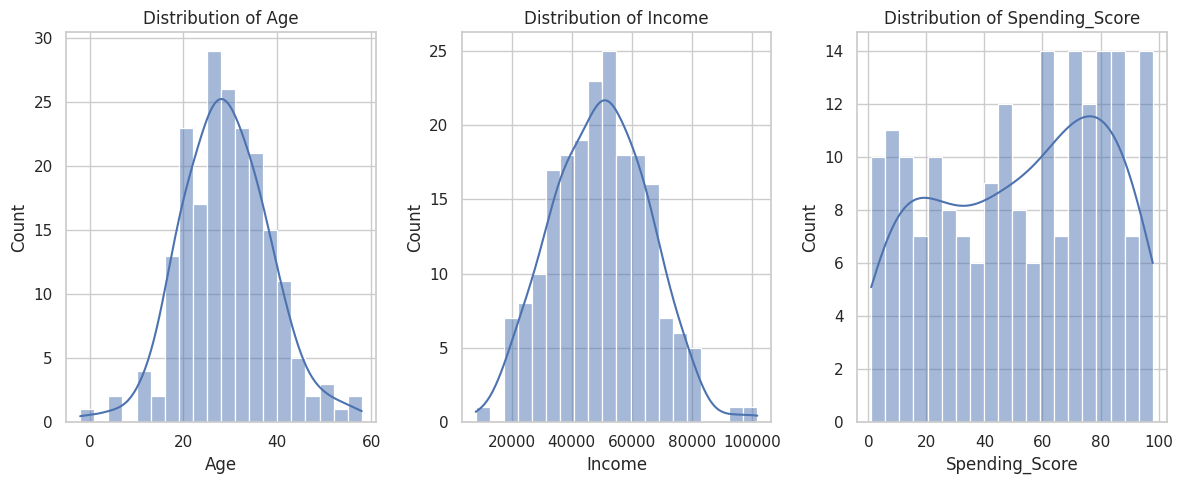

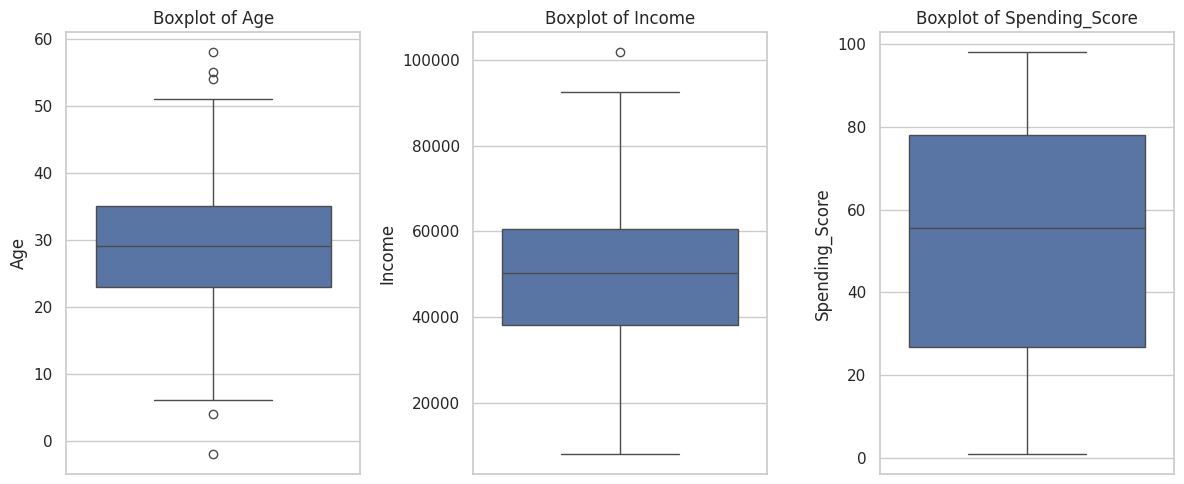

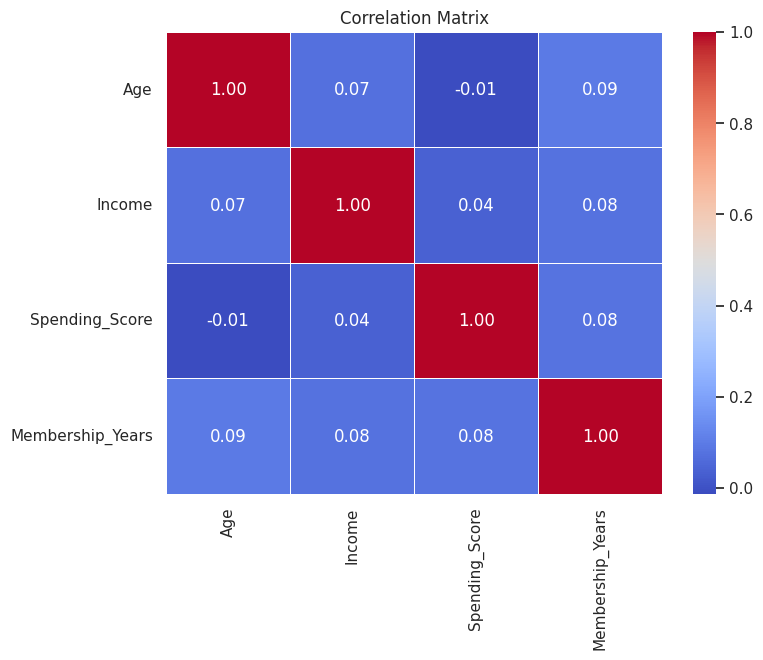

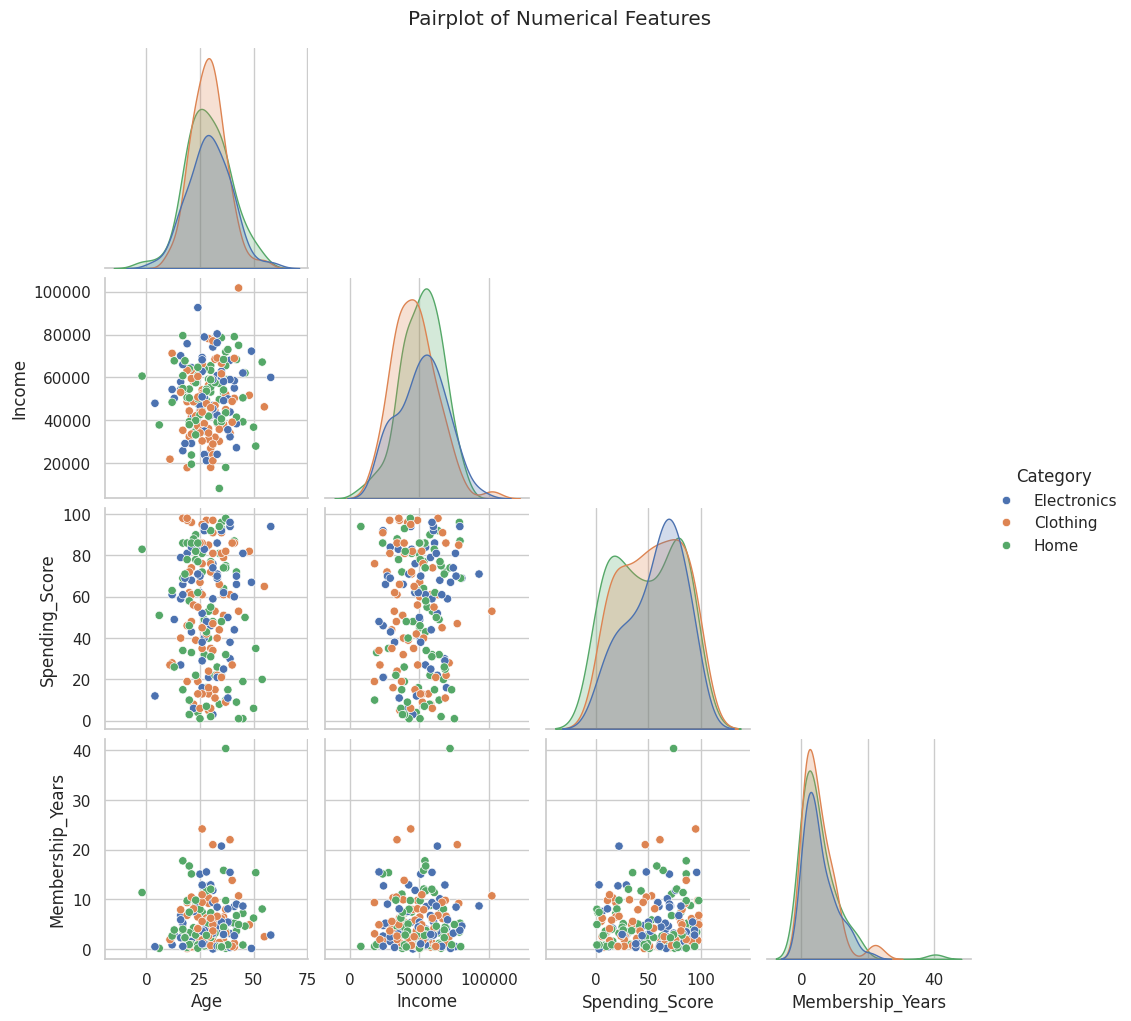

/tmp/ipython-input-904850967.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=df, palette='viridis')


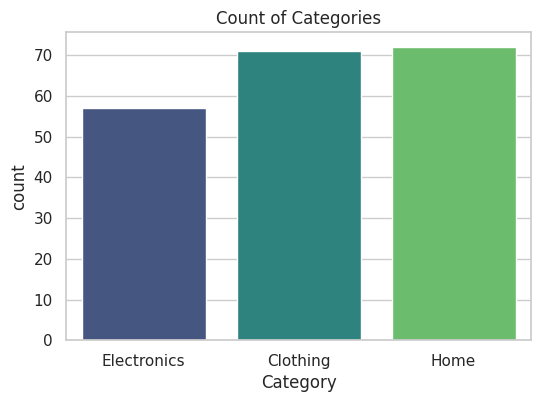

In [ ]:
'''
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for cleaner plots
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ---------------------------------------------------------
# 2. Load Data
# ---------------------------------------------------------
# OPTION A: Create a dummy dataset for demonstration
data = {
    'Age': np.random.normal(30, 10, 200).astype(int),
    'Income': np.random.normal(50000, 15000, 200),
    'Spending_Score': np.random.randint(1, 100, 200),
    'Category': np.random.choice(['Electronics', 'Clothing', 'Home'], 200),
    'Membership_Years': np.random.exponential(5, 200)
}
# Introduce some missing values and duplicates for realism
df = pd.DataFrame(data)
df.loc[0:5, 'Income'] = np.nan  # Create NaN values
df = pd.concat([df, df.iloc[0:2]], ignore_index=True) # Create duplicates

# OPTION B: Load your own file (Uncomment below)
# df = pd.read_csv('your_dataset.csv')

print(f"Data loaded successfully. Shape: {df.shape}")

# ---------------------------------------------------------
# 3. Quick Inspection & Data Cleaning
# ---------------------------------------------------------
print("\n--- 1. Head of Data ---")
print(df.head())

print("\n--- 2. Data Info (Types & Missing Counts) ---")
print(df.info())

# Handling Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicates found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

# Handling Missing Values
print("\n--- 3. Missing Value Check ---")
missing_sum = df.isnull().sum()
print(missing_sum[missing_sum > 0])

# Simple Imputation (Example: Fill numeric NaNs with median)
# In a real scenario, investigate why data is missing first!
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# ---------------------------------------------------------
# 4. Statistical Summary
# ---------------------------------------------------------
print("\n--- 4. Statistical Summary (Numerical) ---")
print(df.describe().T) # Transposed for better readability

print("\n--- 5. Categorical Summary ---")
print(df.describe(include='object'))

# ---------------------------------------------------------
# 5. Visual Exploratory Analysis
# ---------------------------------------------------------

# A. Univariate Analysis (Distributions & Outliers)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Histograms with KDE (Kernel Density Estimate)
plt.figure(figsize=(12, 5))
for i, col in enumerate(numeric_cols[:3]): # Plotting first 3 numeric cols
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Boxplots for Outlier Detection
plt.figure(figsize=(12, 5))
for i, col in enumerate(numeric_cols[:3]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# B. Bivariate Analysis (Relationships)
# Correlation Heatmap
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Pairplot (Scatter plots for all numeric pairs)
# Ideally use 'hue' to color-code by a categorical variable if available
sns.pairplot(df, hue='Category', diag_kind='kde', corner=True)
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# C. Categorical Analysis (Bar Charts)
plt.figure(figsize=(6, 4))
sns.countplot(x='Category', data=df, palette='viridis')
plt.title('Count of Categories')
plt.show()
'''

Mounted at /content/drive

  PART 1: PROCUREMENT DATA EDA
Loading: final_processed_FY2021_archived_opportunities.csv...

Shape: (14293, 17)

Missing Values (Top 5 Columns):
SetASide              6323
Description           5993
PopCity               2247
PopState              1351
ClassificationCode     620
dtype: int64


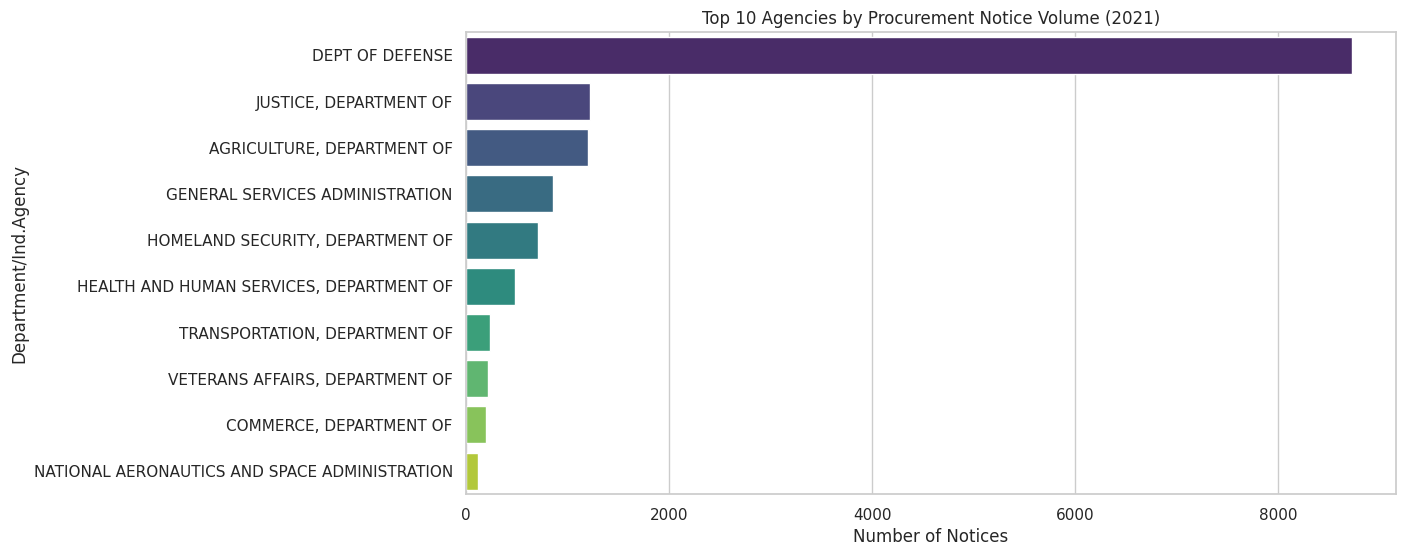

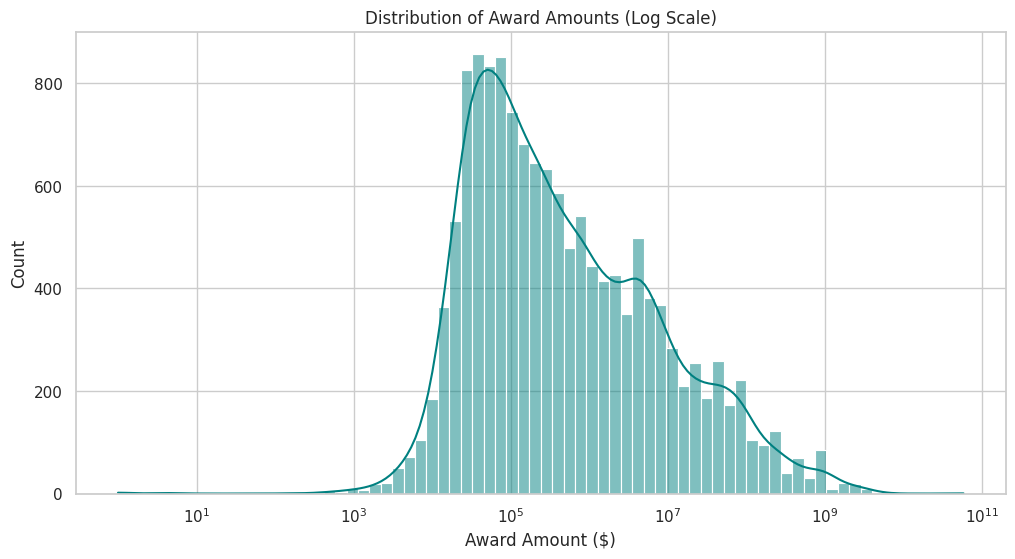

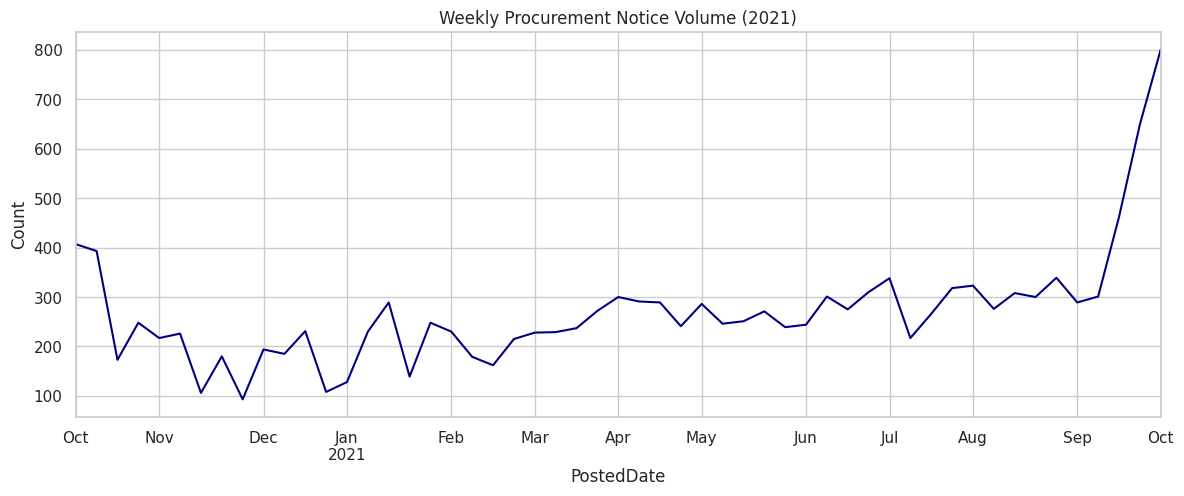


  PART 2: SHIPPING (AIS) DATA EDA
Loading Parquet: LA_LB_AIS_2021_2023_PREPROCESSED.parquet...

Shape: (143057, 22)

Columns: ['MMSI', 'TrackStartTime', 'VesselType', 'Draft_Meters', 'LA', 'LB', 'Draft_invalid', 'LA_invalid', 'LB_invalid', 'VesselType_unknown', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek', 'distance_km', 'VesselTypeCode', 'time_diff_hr', 'avg_speed_kmph', 'abnormal_draft', 'abnormal_speed', 'geometry_wkt']


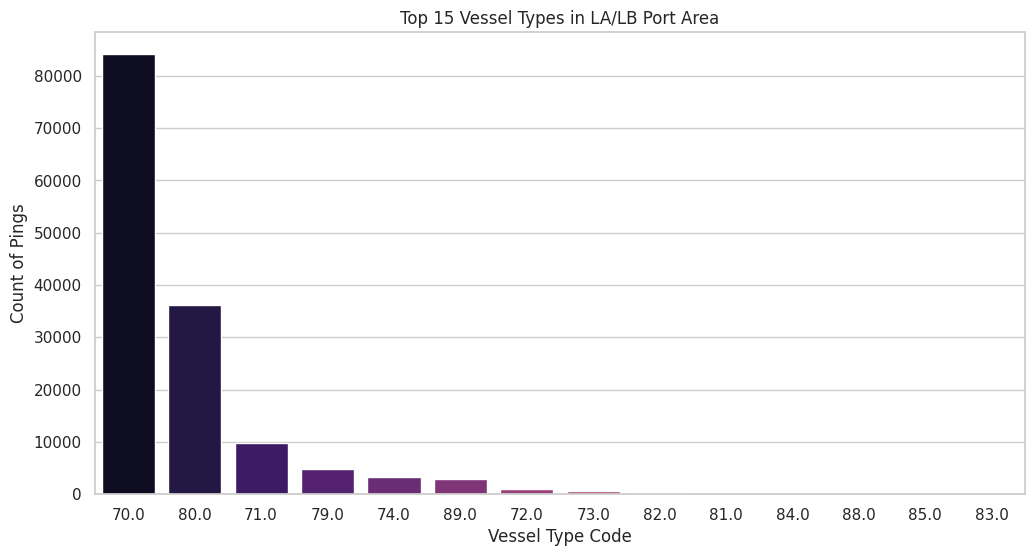

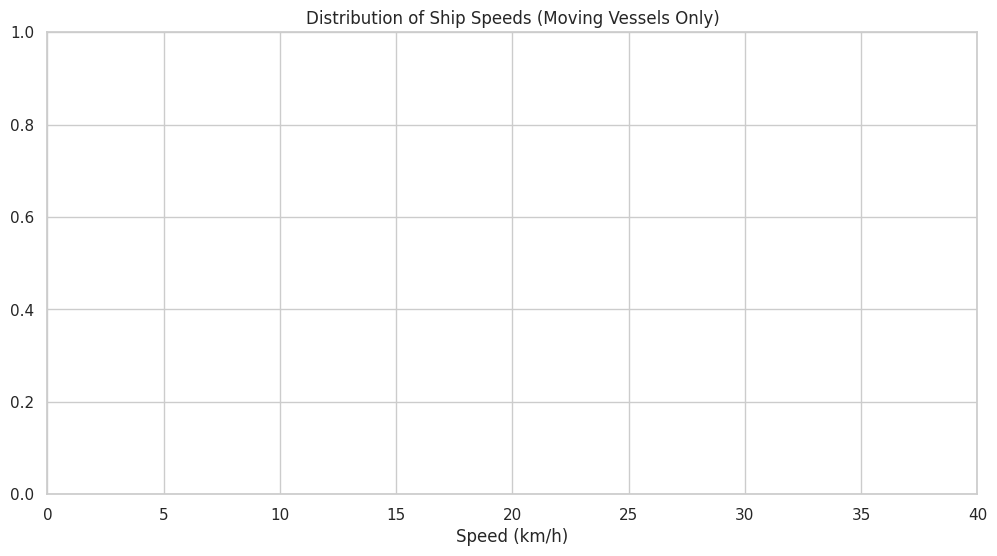

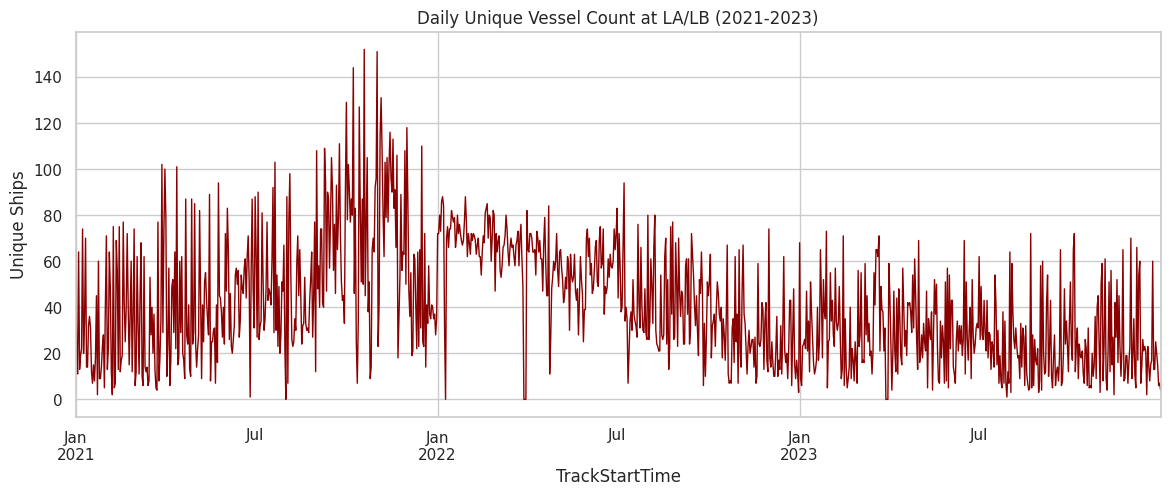

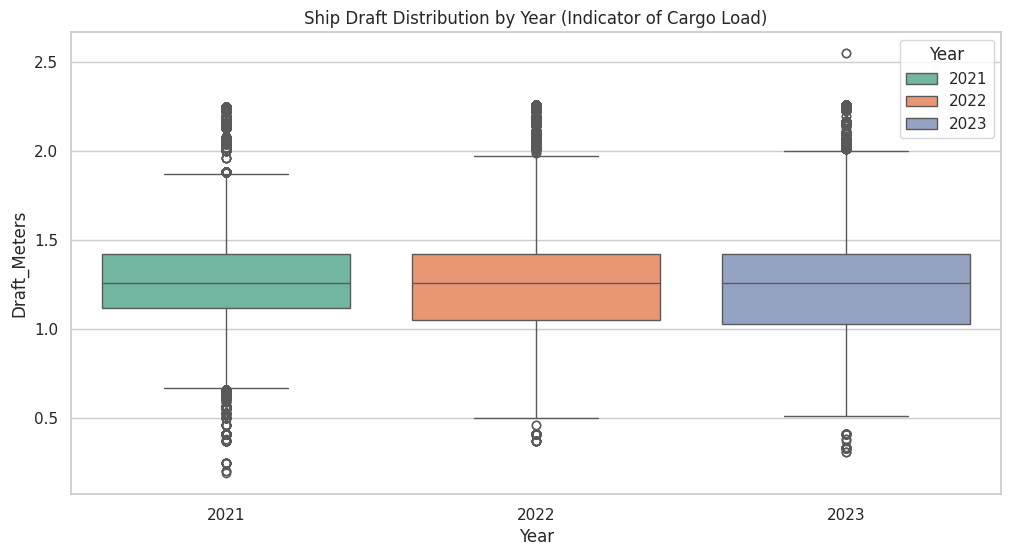

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

def explore_procurement_data():
    print("\n" + "="*60)
    print("  PART 1: PROCUREMENT DATA EDA")
    print("="*60)

    # --- 1. Load Data (Using FY2021 as a representative sample) ---
    base_dir = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/processed/final_awards_data'
    file_path = os.path.join(base_dir, 'final_processed_FY2021_archived_opportunities.csv')

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    print(f"Loading: {os.path.basename(file_path)}...")
    df = pd.read_csv(file_path, encoding='latin1', low_memory=False)

    # Convert Date and Numeric columns
    df['PostedDate'] = pd.to_datetime(df['PostedDate'], errors='coerce', utc=True)
    df['Award$'] = pd.to_numeric(df['Award$'], errors='coerce')

    # --- 2. Basic Checks ---
    print(f"\nShape: {df.shape}")
    print("\nMissing Values (Top 5 Columns):")
    print(df.isnull().sum().sort_values(ascending=False).head(5))

    # --- 3. Visual 1: Top 10 Agencies by Notice Volume ---
    plt.figure(figsize=(12, 6))
    top_agencies = df['Department/Ind.Agency'].value_counts().head(10)
    sns.barplot(x=top_agencies.values, y=top_agencies.index, hue=top_agencies.index, palette='viridis', legend=False)
    plt.title('Top 10 Agencies by Procurement Notice Volume (2021)')
    plt.xlabel('Number of Notices')
    plt.show()

    # --- 4. Visual 2: Distribution of Award Amounts (Log Scale) ---
    plt.figure(figsize=(12, 6))
    # Filter out zero or negative awards for log plot
    valid_awards = df[df['Award$'] > 0]['Award$']
    sns.histplot(valid_awards, log_scale=True, color='teal', kde=True)
    plt.title('Distribution of Award Amounts (Log Scale)')
    plt.xlabel('Award Amount ($)')
    plt.show()

    # --- 5. Visual 3: Posting Volume Over Time ---
    plt.figure(figsize=(14, 5))
    df.set_index('PostedDate').resample('W').size().plot(color='navy')
    plt.title('Weekly Procurement Notice Volume (2021)')
    plt.ylabel('Count')
    plt.show()

def explore_shipping_data():
    print("\n" + "="*60)
    print("  PART 2: SHIPPING (AIS) DATA EDA")
    print("="*60)

    # --- 1. Load Data ---
    base_dir = '/content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023'
    file_path = os.path.join(base_dir, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return

    print(f"Loading Parquet: {os.path.basename(file_path)}...")
    df = pd.read_parquet(file_path)

    # Convert time
    df['TrackStartTime'] = pd.to_datetime(df['TrackStartTime'])

    # --- 2. Basic Checks ---
    print(f"\nShape: {df.shape}")
    print("\nColumns:", df.columns.tolist())

    # --- 3. Visual 1: Vessel Type Distribution ---
    plt.figure(figsize=(12, 6))
    # Filter for meaningful types if too many exist
    type_counts = df['VesselType'].value_counts().head(15)
    sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette='magma', legend=False)
    plt.title('Top 15 Vessel Types in LA/LB Port Area')
    plt.xlabel('Vessel Type Code')
    plt.ylabel('Count of Pings')
    plt.show()

    # --- 4. Visual 2: Ship Speed Distribution ---
    plt.figure(figsize=(12, 6))
    # Filter out stationary ships (0 speed) to see movement patterns
    moving_ships = df[df['avg_speed_kmph'] > 0.5]
    sns.histplot(moving_ships['avg_speed_kmph'], bins=50, kde=True, color='orange')
    plt.title('Distribution of Ship Speeds (Moving Vessels Only)')
    plt.xlabel('Speed (km/h)')
    plt.xlim(0, 40) # Cap at 40km/h to hide outliers
    plt.show()

    # --- 5. Visual 3: Daily Traffic Volume (Time Series) ---
    plt.figure(figsize=(14, 5))
    # Count unique MMSI (Unique Ships) per day
    daily_traffic = df.set_index('TrackStartTime').resample('D')['MMSI'].nunique()
    daily_traffic.plot(color='darkred', linewidth=1)
    plt.title('Daily Unique Vessel Count at LA/LB (2021-2023)')
    plt.ylabel('Unique Ships')
    plt.show()

    # --- 6. Visual 4: Draft Analysis (How heavy are they?) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Year', y='Draft_Meters', data=df, palette='Set2', hue='Year')
    plt.title('Ship Draft Distribution by Year (Indicator of Cargo Load)')
    plt.show()

def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        explore_procurement_data()
        explore_shipping_data()
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    main()

Mounted at /content/drive
Google Drive mounted successfully.
Starting analysis on: processed_FY2021_archived_opportunities.csv...
Starting analysis on: processed_FY2022_archived_opportunities.csv...
Starting analysis on: processed_FY2023_archived_opportunities.csv...
All files analyzed and aggregated by month.
Generating plot...
Plot saved successfully to: /content/drive/My Drive/ADA Encephalon/Procurement_Data/Military_Conflict_Signal_Plot.png


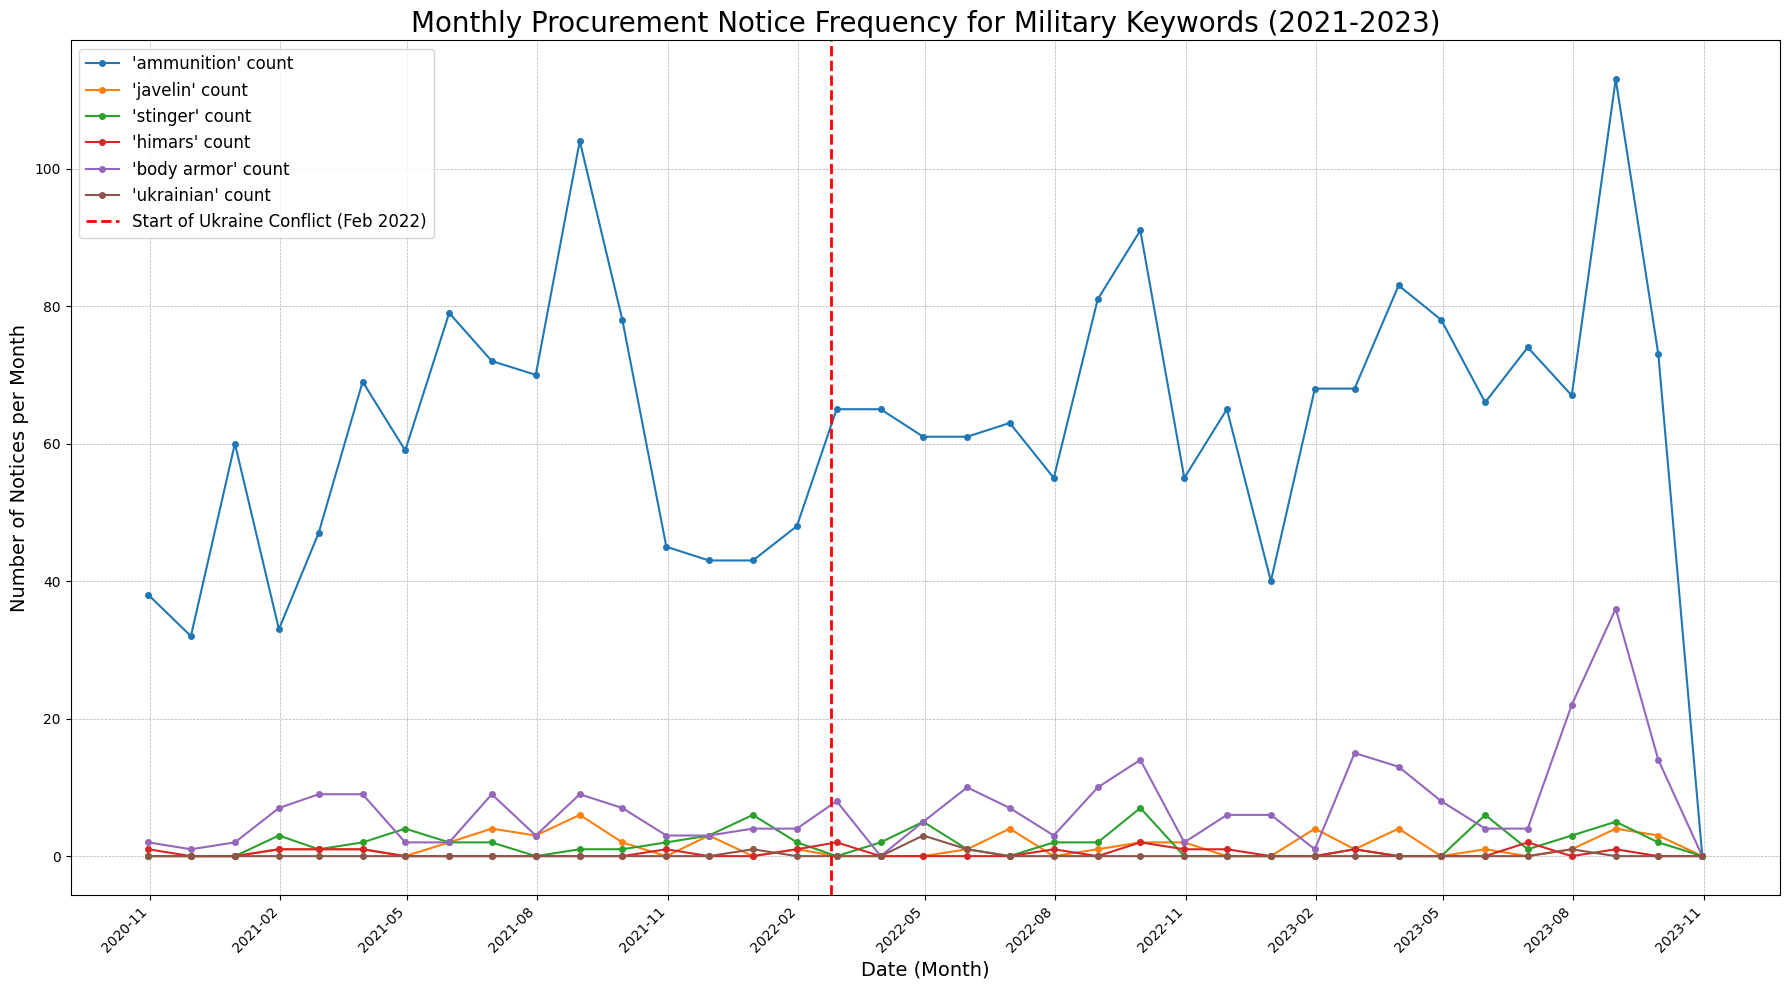

In [ ]:
##Military Conflict Signal Analysis Updated


import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# This module is used to connect to Google Drive in a Colab environment
from google.colab import drive

def analyze_keyword_frequency(directory, files_to_process, keywords):
    """
    Reads specified CSVs in chunks, counts keyword occurrences in Title and
    Description, and returns a DataFrame of monthly counts.
    """
    all_monthly_counts = []

    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        print(f"Starting analysis on: {filename}...")

        try:
            # Use a TextFileReader to iterate through the file in chunks
            chunk_size = 250000  # Process 250,000 rows at a time

            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=chunk_size):

                # --- 1. Prepare Data ---
                # Convert PostedDate to datetime, drop rows that fail conversion
                # Added utc=True to handle mixed timezones and resolve the FutureWarning
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)

                # --- FIX: If chunk is empty after dropping bad dates, skip it ---
                if chunk.empty:
                    continue

                # Combine Title and Description into one text field for searching
                # .fillna('') ensures we don't get errors on missing text
                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')

                # --- 2. Count Keywords ---
                # Add keyword columns directly to the chunk
                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)

                # --- 3. Aggregate by Month ---
                # Resample this chunk by month and sum the boolean (True=1, False=0) counts
                # We specify *which* columns to sum (the keywords)
                # Changed 'M' to 'ME' to resolve the FutureWarning
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)

        except FileNotFoundError:
            print(f"Warning: File not found {input_path}. Skipping.")
        except Exception as e:
            print(f"An error occurred while processing {filename}: {e}")

    # --- 4. Combine All Results ---
    if not all_monthly_counts:
        print("No data was processed. Exiting.")
        return None

    # Combine all the monthly counts from all chunks and all files
    master_counts_df = pd.concat(all_monthly_counts)

    # Group by the month index and sum again to get the final total count per month
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()

    # --- FIX: Corrected indentation on this line ---
    print(f"All files analyzed and aggregated by month.")
    return final_monthly_counts

def plot_and_save_results(df, keywords, output_path):
    """
    Plots the monthly keyword counts and saves the chart as a PNG.
    """
    print("Generating plot...")
    plt.figure(figsize=(18, 10))

    for keyword in keywords:
        plt.plot(df.index, df[keyword], label=f"'{keyword}' count", marker='o', markersize=4)

    # --- Add the critical event line ---
    # This vertical line marks the start of the conflict
    plt.axvline(
        x=pd.to_datetime('2022-02-24', utc=True), # Added utc=True
        color='red',
        linestyle='--',
        linewidth=2,
        label='Start of Ukraine Conflict (Feb 2022)'
    )

    # --- Format the plot ---
    plt.title('Monthly Procurement Notice Frequency for Military Keywords (2021-2023)', fontsize=20)
    plt.xlabel('Date (Month)', fontsize=14)
    plt.ylabel('Number of Notices per Month', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Format the x-axis to show dates nicely
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()

    # --- Save the plot ---
    plt.savefig(output_path)
    print(f"Plot saved successfully to: {output_path}")
    plt.show()

def main():
    """
    Main function to mount Drive, run analysis, and plot results.
    """
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    # --- FIX: Corrected the base directory path ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')

    # We are ONLY using the 2021-2023 files as requested
    files_to_process = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]

    # Keywords to track for the military conflict scenario
    keywords_to_track = [
        'ammunition',
        'javelin',
        'stinger',
        'himars',
        'body armor',
        'ukrainian'
    ]

    # Where to save the final chart
    output_plot_path = os.path.join(base_directory, 'Military_Conflict_Signal_Plot.png')

    # --- Execution ---
    monthly_data = analyze_keyword_frequency(processed_directory, files_to_process, keywords_to_track)

    if monthly_data is not None:
        plot_and_save_results(monthly_data, keywords_to_track, output_plot_path)

if __name__ == "__main__":
    main()



In [ ]:
import pandas as pd
from google.colab import drive

# --- 1. Mount Google Drive ---
try:
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive mounted successfully.")
except Exception as e:
    print(f"Could not mount Google Drive. Error: {e}")
    # Stop execution if drive doesn't mount
    raise e

# --- 2. Define File Path ---
file_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet'

# --- 3. Load the DataFrame ---
try:
    # Read the Parquet file. This loads it into a pandas DataFrame.
    df = pd.read_parquet(file_path)

    print(f"\nSuccessfully read file: {file_path}")

    # --- 4. Get the Schema (Columns and Data Types) ---
    print("\n\n--- 1. DATASET SCHEMA (df.info()) ---")
    # Use df.info() to get columns, null counts, and data types
    df.info()

    # --- 5. Get Sample Data (First 5 Rows) ---
    print("\n\n--- 2. SAMPLE DATA (df.head()) ---")
    print(df.head())

except FileNotFoundError:
    print(f"\n--- ERROR ---")
    print(f"Error: The file '{file_path}' was not found.")
    print("Please double-check the path is correct in your 'My Drive'.")
except Exception as e:
    print(f"\nAn error occurred while reading the file: {e}")

Mounted at /content/drive
Google Drive mounted successfully.

Successfully read file: /content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet


--- 1. DATASET SCHEMA (df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143057 entries, 0 to 143056
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   MMSI                143057 non-null  Int32              
 1   TrackStartTime      143057 non-null  datetime64[ns, UTC]
 2   VesselType          143057 non-null  object             
 3   Draft_Meters        143057 non-null  float64            
 4   LA                  143057 non-null  float64            
 5   LB                  143057 non-null  float64            
 6   Draft_invalid       143057 non-null  bool               
 7   LA_invalid          143057 non-null  bool               
 8   LB_invalid          143057 non-null  bool

In [ ]:
import pandas as pd
import os
# We need to install the pyarrow library to read Parquet files in Colab
!pip install pyarrow -q
# This module is used to connect to Google Drive in a Colab environment
from google.colab import drive

def explore_shipping_data(filepath):
    """
    Loads the preprocessed Parquet file and prints out the unique
    VesselType and VesselTypeCode values so we can identify the
    correct one for 'Container Ship' or 'Cargo Ship'.
    """
    try:
        print(f"Loading Parquet file from: {filepath}...")
        # Load the Parquet file into a pandas DataFrame
        df = pd.read_parquet(filepath)
        print("File loaded successfully.")

        # --- Analysis 1: VesselType Column ---
        # The schema said this was 'object' or 'float', so let's check
        print("\n--- 1. Analysis of 'VesselType' Column ---")
        if 'VesselType' in df.columns:
            print("Value counts for 'VesselType':")
            # Get the top 20 most common vessel types
            print(df['VesselType'].value_counts().head(20))
        else:
            print("Warning: 'VesselType' column not found.")

        # --- Analysis 2: VesselTypeCode Column ---
        # The schema said this was 'int8', so this might be the one we need
        print("\n--- 2. Analysis of 'VesselTypeCode' Column ---")
        if 'VesselTypeCode' in df.columns:
            print("Value counts for 'VesselTypeCode':")
            # Get the top 20 most common vessel type codes
            print(df['VesselTypeCode'].value_counts().head(20))
        else:
            print("Warning: 'VesselTypeCode' column not found.")

        print("\n--- 3. Sample Data for Context ---")
        print(df[['VesselType', 'VesselTypeCode']].head(10))

    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found. Please check the path.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

def main():
    """
    Main function to mount Drive and run the exploration.
    """
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    # This is the path to your preprocessed shipping data
    # PLEASE DOUBLE-CHECK THIS PATH
    parquet_file_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet'

    # --- Execution ---
    if not os.path.exists(parquet_file_path):
        print(f"Error: Cannot find the file at the specified path:")
        print(parquet_file_path)
        print("Please check the 'parquet_file_path' variable in the script.")
    else:
        explore_shipping_data(parquet_file_path)

if __name__ == "__main__":
    main()



Mounted at /content/drive
Google Drive mounted successfully.
Loading Parquet file from: /content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet...
File loaded successfully.

--- 1. Analysis of 'VesselType' Column ---
Value counts for 'VesselType':
VesselType
70.0    84140
80.0    36181
71.0     9707
79.0     4857
74.0     3333
89.0     2828
72.0      929
73.0      569
82.0      271
81.0      139
84.0       55
88.0       28
85.0       13
83.0        7
Name: count, dtype: int64

--- 2. Analysis of 'VesselTypeCode' Column ---
Value counts for 'VesselTypeCode':
VesselTypeCode
0     84140
6     36181
1      9707
5      4857
4      3333
13     2828
2       929
3       569
8       271
7       139
10       55
12       28
11       13
9         7
Name: count, dtype: int64

--- 3. Sample Data for Context ---
  VesselType  VesselTypeCode
0       80.0               6
1       80.0               6
2       80.0               6
3       80.0               6
4    

Mounted at /content/drive
Google Drive mounted successfully.
Loading Parquet file from: /content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet...
File loaded successfully.
Filtering for Cargo Ships (VesselType 70-79)...
Found 103535 track points for cargo ships.
Creating monthly time series of unique cargo ships...
Monthly shipping data successfully created:
                UniqueCargoShipCount
TrackStartTime                      
2021-01-31                       233
2021-02-28                       220
2021-03-31                       267
2021-04-30                       314
2021-05-31                       307
Generating plot... saving to /content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_Shipping_Signal_Plot.png


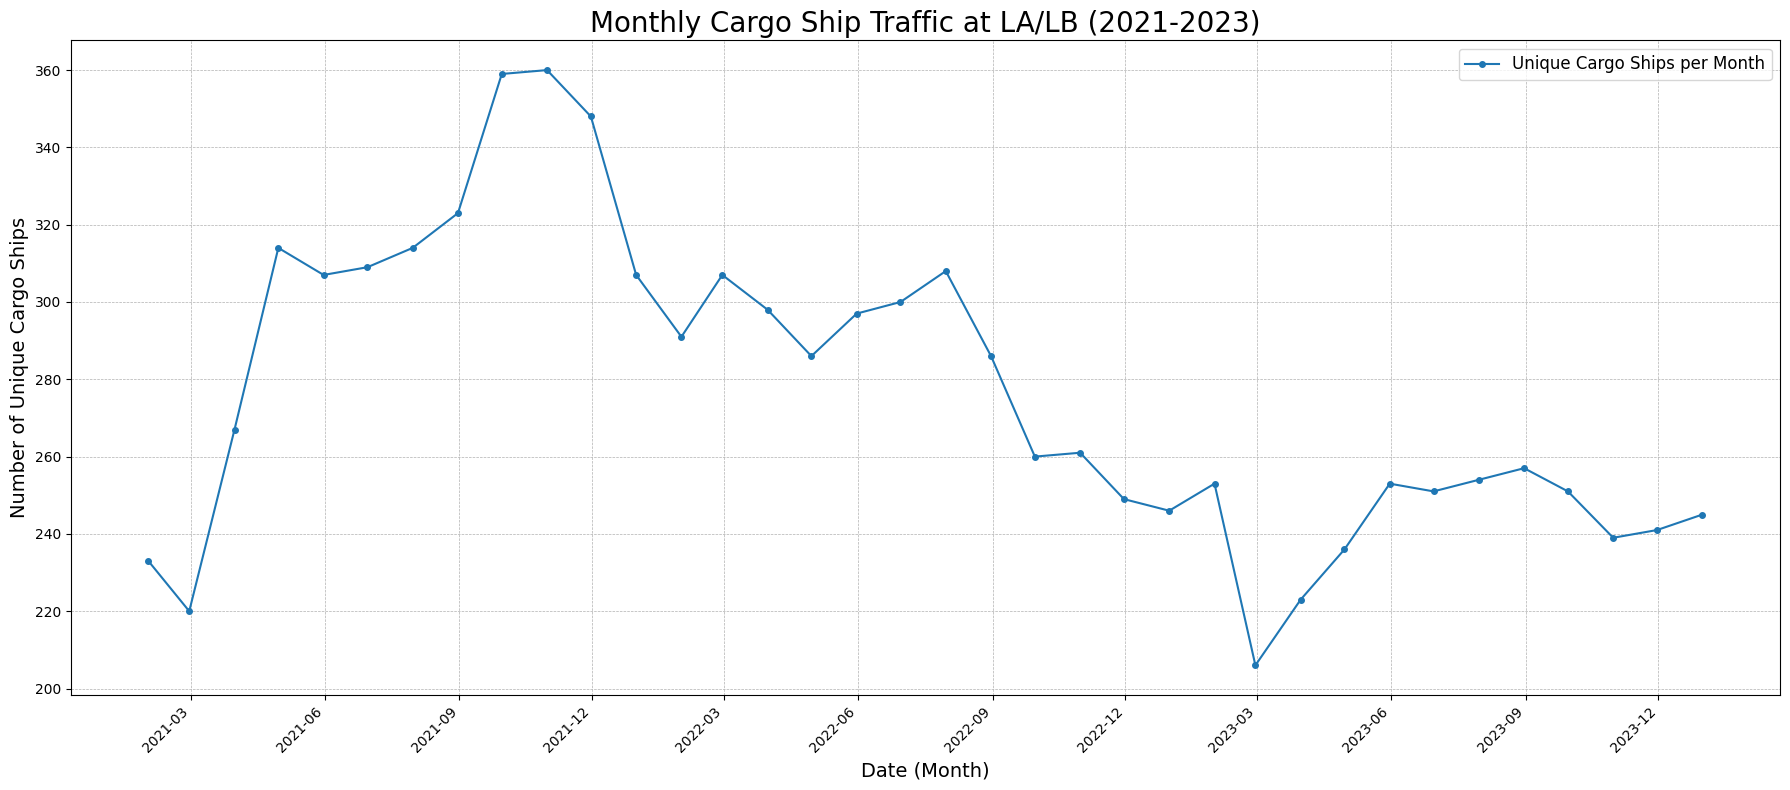

Shipping signal plot saved to: /content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_Shipping_Signal_Plot.png

Successfully generated shipping time series.


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# We need to install the pyarrow library to read Parquet files in Colab
!pip install pyarrow -q
# This module is used to connect to Google Drive in a Colab environment
from google.colab import drive

def analyze_shipping_timeseries(filepath):
    """
    Loads the preprocessed Parquet file, isolates relevant cargo ships,
    and creates a monthly time-series of unique vessel counts.
    """
    try:
        print(f"Loading Parquet file from: {filepath}...")
        df = pd.read_parquet(filepath)
        print("File loaded successfully.")

        # --- FIX: Convert VesselType to a numeric type BEFORE filtering ---
        # This forces any string values (like 'Unknown') into NaN
        df['VesselType'] = pd.to_numeric(df['VesselType'], errors='coerce')

        # We can now safely drop any rows where the conversion failed
        df.dropna(subset=['VesselType'], inplace=True)

        # --- 1. Filter for Relevant Vessels ---
        # Based on our exploration, we want 'Cargo Ships' (types 70-79)
        # This will filter out tankers, passenger ships, etc.
        print("Filtering for Cargo Ships (VesselType 70-79)...")
        cargo_df = df[
            (df['VesselType'] >= 70) & (df['VesselType'] < 80)
        ].copy()

        if cargo_df.empty:
            print("Error: No cargo ships (VesselType 70-79) found in the data.")
            return None

        print(f"Found {len(cargo_df)} track points for cargo ships.")

        # --- 2. Create the Monthly Time Series ---
        # We need to count the number of *unique ships* (MMSI) per month,
        # not just the total number of AIS pings.
        print("Creating monthly time series of unique cargo ships...")

        # Set the 'TrackStartTime' as the index for time-based operations
        # We need to convert the index to timezone-naive to avoid errors in resample
        cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
        cargo_df.set_index('TrackStartTime', inplace=True)

        # Resample by Month ('ME' = Month End) and count the unique MMSIs
        # This gives us a count of *how many different ships* were active each month.
        monthly_shipping_counts = cargo_df.resample('ME')['MMSI'].nunique()

        # Convert to a DataFrame for easier plotting and merging later
        shipping_df = monthly_shipping_counts.to_frame(name='UniqueCargoShipCount')

        print("Monthly shipping data successfully created:")
        print(shipping_df.head())

        # --- 3. Plot the Shipping Signal ---
        output_path = os.path.dirname(filepath)
        plot_path = os.path.join(output_path, 'LA_LB_Shipping_Signal_Plot.png')

        print(f"Generating plot... saving to {plot_path}")
        plt.figure(figsize=(18, 8))
        plt.plot(shipping_df.index, shipping_df['UniqueCargoShipCount'], marker='o', markersize=4, label='Unique Cargo Ships per Month')
        plt.title('Monthly Cargo Ship Traffic at LA/LB (2021-2023)', fontsize=20)
        plt.xlabel('Date (Month)', fontsize=14)
        plt.ylabel('Number of Unique Cargo Ships', fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)

        # Format the x-axis to show dates nicely
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(plot_path)
        plt.show()
        print(f"Shipping signal plot saved to: {plot_path}")

        return shipping_df

    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

def main():
    """
    Main function to mount Drive and run the shipping analysis.
    """
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    parquet_file_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet'

    # --- Execution ---
    if not os.path.exists(parquet_file_path):
        print(f"Error: Cannot find the file at the specified path: {parquet_file_path}")
    else:
        # This will run the analysis and save the resulting plot
        shipping_df = analyze_shipping_timeseries(parquet_file_path)
        if shipping_df is not None:
            print("\nSuccessfully generated shipping time series.")
            # We can now store this DataFrame for the next step (fusion)
            # For now, we'll just confirm it worked.
            # (In a real script, you might save this as a small CSV)
            # shipping_df.to_csv("shipping_signal.csv")

if __name__ == "__main__":
    main()



Mounted at /content/drive
Google Drive mounted successfully.
Starting procurement analysis on: processed_FY2021_archived_opportunities.csv...
Starting procurement analysis on: processed_FY2022_archived_opportunities.csv...
Starting procurement analysis on: processed_FY2023_archived_opportunities.csv...
All procurement files analyzed and aggregated by month.
Generating procurement plot...


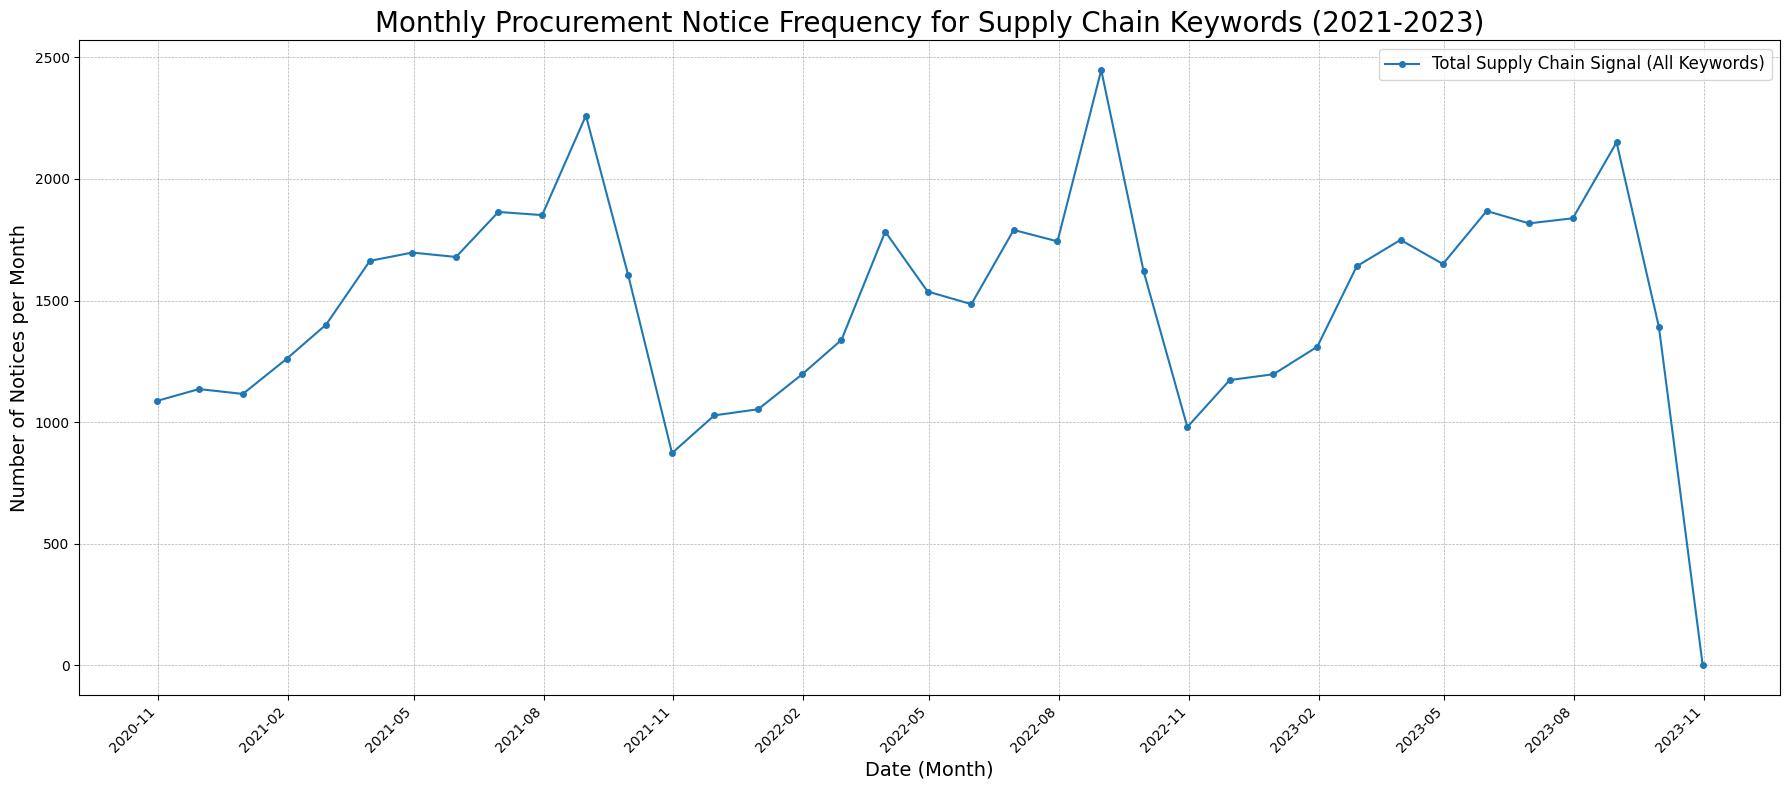

Procurement signal plot saved to: /content/drive/My Drive/ADA Encephalon/Procurement_Data/Supply_Chain_Signal_Plot.png

Successfully generated procurement time series.


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# This module is used to connect to Google Drive in a Colab environment
from google.colab import drive

def analyze_procurement_keywords(directory, files_to_process, keywords):
    """
    Reads specified CSVs in chunks, counts keyword occurrences in Title and
    Description, and returns a DataFrame of monthly counts.
    """
    all_monthly_counts = []

    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        print(f"Starting procurement analysis on: {filename}...")

        try:
            chunk_size = 250000  # Process 250,000 rows at a time

            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=chunk_size):

                # --- 1. Prepare Data ---
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)

                if chunk.empty:
                    continue

                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')

                # --- 2. Count Keywords ---
                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)

                # --- 3. Aggregate by Month ---
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)

        except FileNotFoundError:
            print(f"Warning: File not found {input_path}. Skipping.")
        except Exception as e:
            print(f"An error occurred while processing {filename}: {e}")

    # --- 4. Combine All Results ---
    if not all_monthly_counts:
        print("No procurement data was processed. Exiting.")
        return None

    master_counts_df = pd.concat(all_monthly_counts)
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()

    # Create a new column 'Total_Supply_Chain_Signal' which is the sum of all keywords
    final_monthly_counts['Total_Supply_Chain_Signal'] = final_monthly_counts.sum(axis=1)

    print("All procurement files analyzed and aggregated by month.")
    return final_monthly_counts

def plot_procurement_signal(df, output_path):
    """
    Plots the 'Total_Supply_Chain_Signal' and saves the chart.
    """
    print("Generating procurement plot...")
    plt.figure(figsize=(18, 8))

    plt.plot(df.index, df['Total_Supply_Chain_Signal'], label='Total Supply Chain Signal (All Keywords)', marker='o', markersize=4)

    plt.title('Monthly Procurement Notice Frequency for Supply Chain Keywords (2021-2023)', fontsize=20)
    plt.xlabel('Date (Month)', fontsize=14)
    plt.ylabel('Number of Notices per Month', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Format the x-axis to show dates nicely
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    print(f"Procurement signal plot saved to: {output_path}")

def main():
    """
    Main function to mount Drive, run procurement analysis, and plot results.
    """
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')

    # We are using the 2021-2023 files
    files_to_process = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]

    # Keywords to track for the SUPPLY CHAIN scenario
    keywords_to_track = [
        'N95',
        'PPE',
        'diagnostic test',
        'semiconductor',
        'microchip',
        'electronics',
        'logistics'
    ]

    # Where to save the final chart
    output_plot_path = os.path.join(base_directory, 'Supply_Chain_Signal_Plot.png')

    # --- Execution ---
    procurement_df = analyze_procurement_keywords(processed_directory, files_to_process, keywords_to_track)

    if procurement_df is not None:
        plot_procurement_signal(procurement_df, output_plot_path)
        print("\nSuccessfully generated procurement time series.")
        # We will need 'procurement_df' in the next step, so we'll keep it in memory.

if __name__ == "__main__":
    main()


Mounted at /content/drive
Google Drive mounted successfully.
--- (1/4) Starting Procurement Analysis ---
--- (1/4) Procurement Analysis Complete ---
--- (2/4) Starting Shipping Analysis ---
--- (2/4) Shipping Analysis Complete ---

--- Fusing DataFrames ---
Data fused successfully. Sample:
            Total_Supply_Chain_Signal  UniqueCargoShipCount
PostedDate                                                 
2021-01-31                       1260                 233.0
2021-02-28                       1401                 220.0
2021-03-31                       1663                 267.0
2021-04-30                       1697                 314.0
2021-05-31                       1679                 307.0

--- (3/4) Running Granger Causality Test ---
Testing if 'Total_Supply_Chain_Signal' (Procurement) Granger-causes 'UniqueCargoShipCount' (Shipping)...
--- How to Read These Results: ---
A p-value < 0.05 means the procurement signal IS a significant predictor.

Lag = 1 month(s): p-value = 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


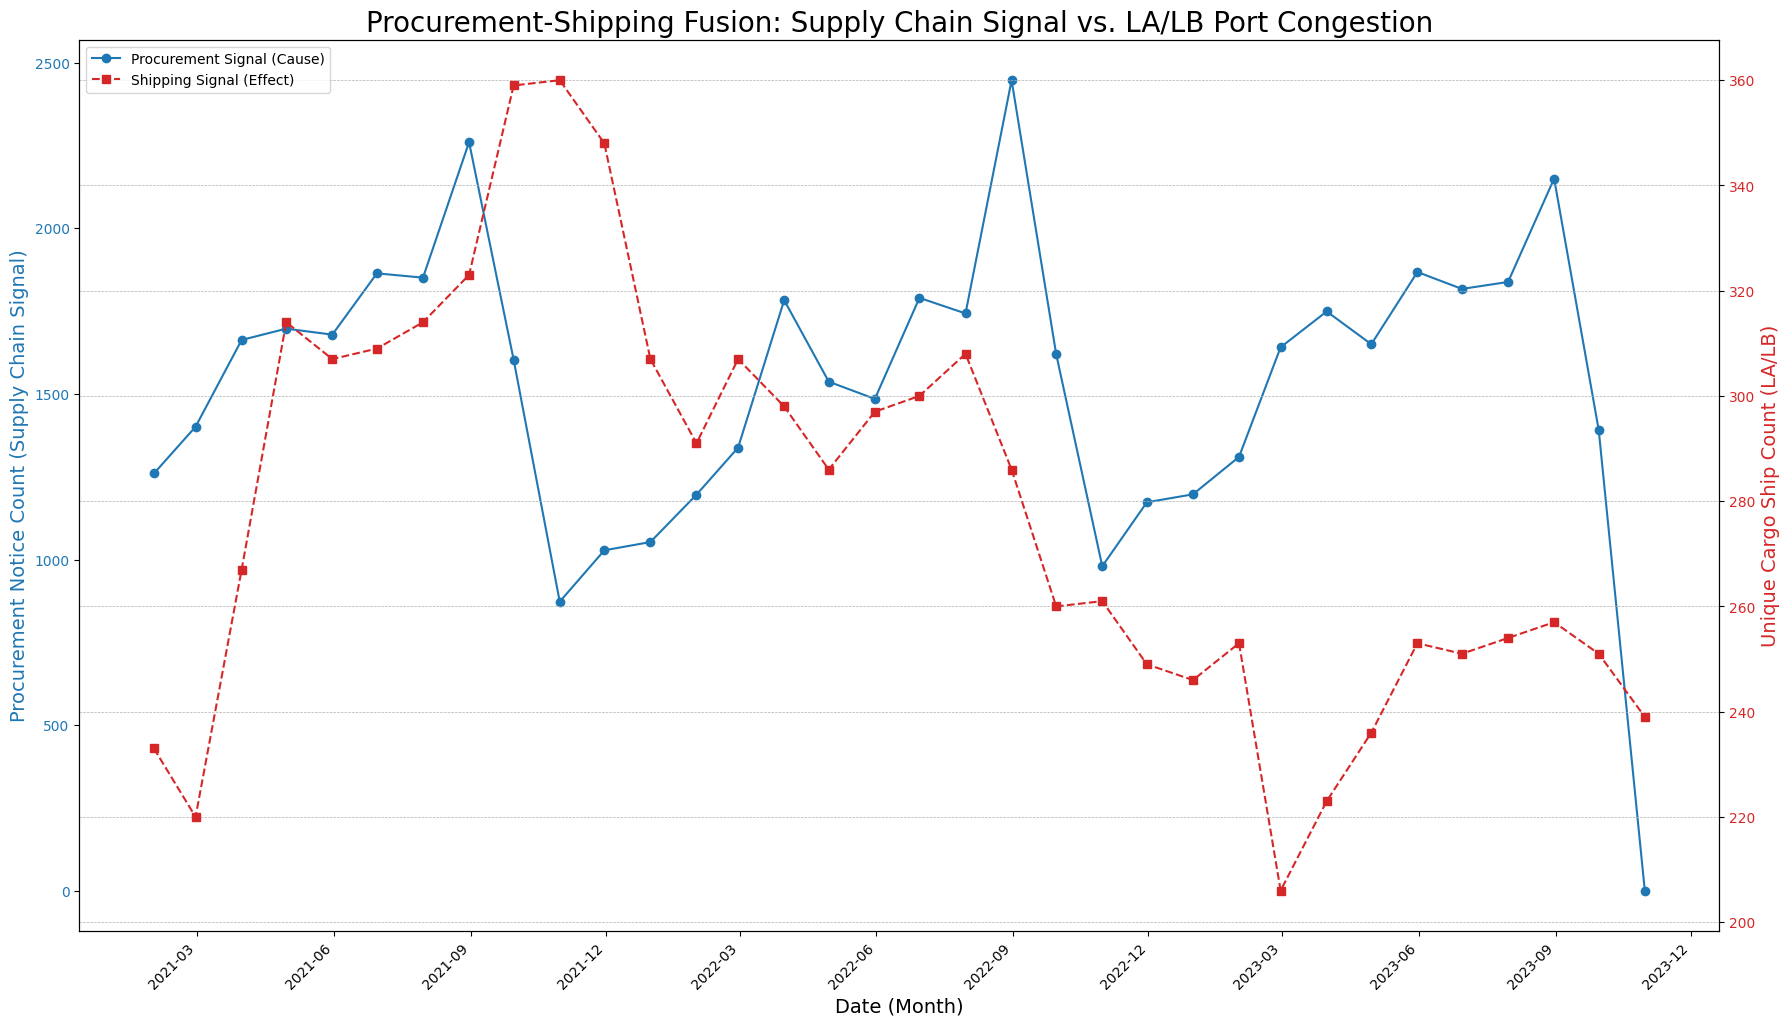

--- (4/4) Fused Plot saved to: /content/drive/My Drive/ADA Encephalon/Procurement_Data/Fused_Supply_Chain_Plot.png ---


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Install/import necessary libraries
!pip install pyarrow -q
!pip install statsmodels -q
from google.colab import drive
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np

# --- Script 1: analyze_procurement_keywords ---
# (We copy the function from the previous script here for a self-contained solution)
def analyze_procurement_keywords(directory, files_to_process, keywords):
    print("--- (1/4) Starting Procurement Analysis ---")
    all_monthly_counts = []
    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        # print(f"Analyzing {filename}...") # Less verbose
        try:
            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=250000):
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)
                if chunk.empty: continue
                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)
        except Exception as e:
            print(f"Error on {filename}: {e}")
    if not all_monthly_counts: return None
    master_counts_df = pd.concat(all_monthly_counts)
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()
    final_monthly_counts['Total_Supply_Chain_Signal'] = final_monthly_counts.sum(axis=1)
    # Convert index to timezone-naive for merging
    final_monthly_counts.index = final_monthly_counts.index.tz_localize(None)
    print("--- (1/4) Procurement Analysis Complete ---")
    return final_monthly_counts

# --- Script 2: analyze_shipping_timeseries ---
# (We copy the function from the previous script here)
def analyze_shipping_timeseries(filepath):
    print("--- (2/4) Starting Shipping Analysis ---")
    try:
        df = pd.read_parquet(filepath)
        df['VesselType'] = pd.to_numeric(df['VesselType'], errors='coerce')
        df.dropna(subset=['VesselType'], inplace=True)
        cargo_df = df[(df['VesselType'] >= 70) & (df['VesselType'] < 80)].copy()
        if cargo_df.empty:
            print("Error: No cargo ships found.")
            return None
        cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
        cargo_df.set_index('TrackStartTime', inplace=True)
        monthly_shipping_counts = cargo_df.resample('ME')['MMSI'].nunique()
        shipping_df = monthly_shipping_counts.to_frame(name='UniqueCargoShipCount')
        print("--- (2/4) Shipping Analysis Complete ---")
        return shipping_df
    except Exception as e:
        print(f"Error in shipping analysis: {e}")
        return None

# --- Script 3: Causal Inference Test ---
def run_causal_inference(df, cause_col, effect_col, max_lag=3):
    print(f"\n--- (3/4) Running Granger Causality Test ---")
    print(f"Testing if '{cause_col}' (Procurement) Granger-causes '{effect_col}' (Shipping)...")

    test_data = df[[effect_col, cause_col]].dropna()

    if test_data.empty or len(test_data) < 20: # Need enough data to test
        print("Not enough overlapping data to run causality test.")
        return

    granger_test_results = grangercausalitytests(test_data, max_lag, verbose=False)

    print("--- How to Read These Results: ---")
    print("A p-value < 0.05 means the procurement signal IS a significant predictor.\n")

    significant_lags = 0
    for lag in range(1, max_lag + 1):
        p_value = granger_test_results[lag][0]['ssr_ftest'][1]
        print(f"Lag = {lag} month(s): p-value = {p_value:.4f}")
        if p_value < 0.05:
            print(f"  -> SIGNIFICANT: Procurement signal at lag {lag} helps predict shipping.")
            significant_lags += 1
        else:
            print(f"  -> Not Significant.")

    if significant_lags > 0:
        print("\nConclusion: The procurement signal is a statistically significant predictor of shipping traffic.")
    else:
        print("\nConclusion: No significant causal link found at these lags.")
    print("--- (3/4) Causal Inference Complete ---")

# --- Script 4: Plot Fused Data ---
def plot_fused_data(df, cause_col, effect_col, output_path):
    print(f"\n--- (4/4) Generating Fused Plot ---")
    fig, ax1 = plt.subplots(figsize=(18, 10))

    # Axis 1 (Left): Procurement Signal
    color = 'tab:blue'
    ax1.set_xlabel('Date (Month)', fontsize=14)
    ax1.set_ylabel('Procurement Notice Count (Supply Chain Signal)', color=color, fontsize=14)
    ax1.plot(df.index, df[cause_col], color=color, marker='o', label='Procurement Signal (Cause)')
    ax1.tick_params(axis='y', labelcolor=color)

    # Axis 2 (Right): Shipping Signal
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Unique Cargo Ship Count (LA/LB)', color=color, fontsize=14)
    ax2.plot(df.index, df[effect_col], color=color, marker='s', linestyle='--', label='Shipping Signal (Effect)')
    ax2.tick_params(axis='y', labelcolor=color)

    # Formatting
    plt.title('Procurement-Shipping Fusion: Supply Chain Signal vs. LA/LB Port Congestion', fontsize=20)
    fig.tight_layout()
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.savefig(output_path)
    plt.show()
    print(f"--- (4/4) Fused Plot saved to: {output_path} ---")

def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')
    parquet_file_path = os.path.join(base_directory, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    procurement_files = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]
    procurement_keywords = [
        'N95', 'PPE', 'diagnostic test', 'semiconductor',
        'microchip', 'electronics', 'logistics'
    ]

    output_plot_path = os.path.join(base_directory, 'Fused_Supply_Chain_Plot.png')

    # --- 1. Run Procurement Analysis ---
    procurement_df = analyze_procurement_keywords(processed_directory, procurement_files, procurement_keywords)

    # --- 2. Run Shipping Analysis ---
    shipping_df = analyze_shipping_timeseries(parquet_file_path)

    # --- 3. Fuse Data ---
    if procurement_df is not None and shipping_df is not None:
        print("\n--- Fusing DataFrames ---")
        master_df = procurement_df.join(shipping_df)

        # We only care about the columns we are testing
        final_df = master_df[['Total_Supply_Chain_Signal', 'UniqueCargoShipCount']].dropna()

        if final_df.empty:
            print("Error: No overlapping dates found between procurement and shipping data.")
            return

        print("Data fused successfully. Sample:")
        print(final_df.head())

        # --- 4. Run Causal Inference ---
        run_causal_inference(final_df, 'Total_Supply_Chain_Signal', 'UniqueCargoShipCount')

        # --- 5. Plot Fused Data ---
        plot_fused_data(final_df, 'Total_Supply_Chain_Signal', 'UniqueCargoShipCount', output_plot_path)

    else:
        print("Failed to generate one or both data signals. Exiting.")

if __name__ == "__main__":
    main()


Mounted at /content/drive
Google Drive mounted successfully.
--- (1/4) Starting Procurement Analysis ---
--- (1/4) Procurement Analysis Complete ---
--- (2/4) Starting Shipping Analysis ---
--- (2/4) Shipping Analysis Complete ---

--- Fusing DataFrames ---
Data fused successfully. Sample:
            Total_Supply_Chain_Signal  UniqueCargoShipCount
PostedDate                                                 
2021-01-31                       1260                 233.0
2021-02-28                       1401                 220.0
2021-03-31                       1663                 267.0
2021-04-30                       1697                 314.0
2021-05-31                       1679                 307.0

--- (3/4) Running Granger Causality Test ---
Testing if 'change in Total_Supply_Chain_Signal' Granger-causes 'change in UniqueCargoShipCount'...
--- How to Read These Results: ---
A p-value < 0.05 means the procurement signal IS a significant predictor.

Lag = 1 month(s): p-value = 0.501

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


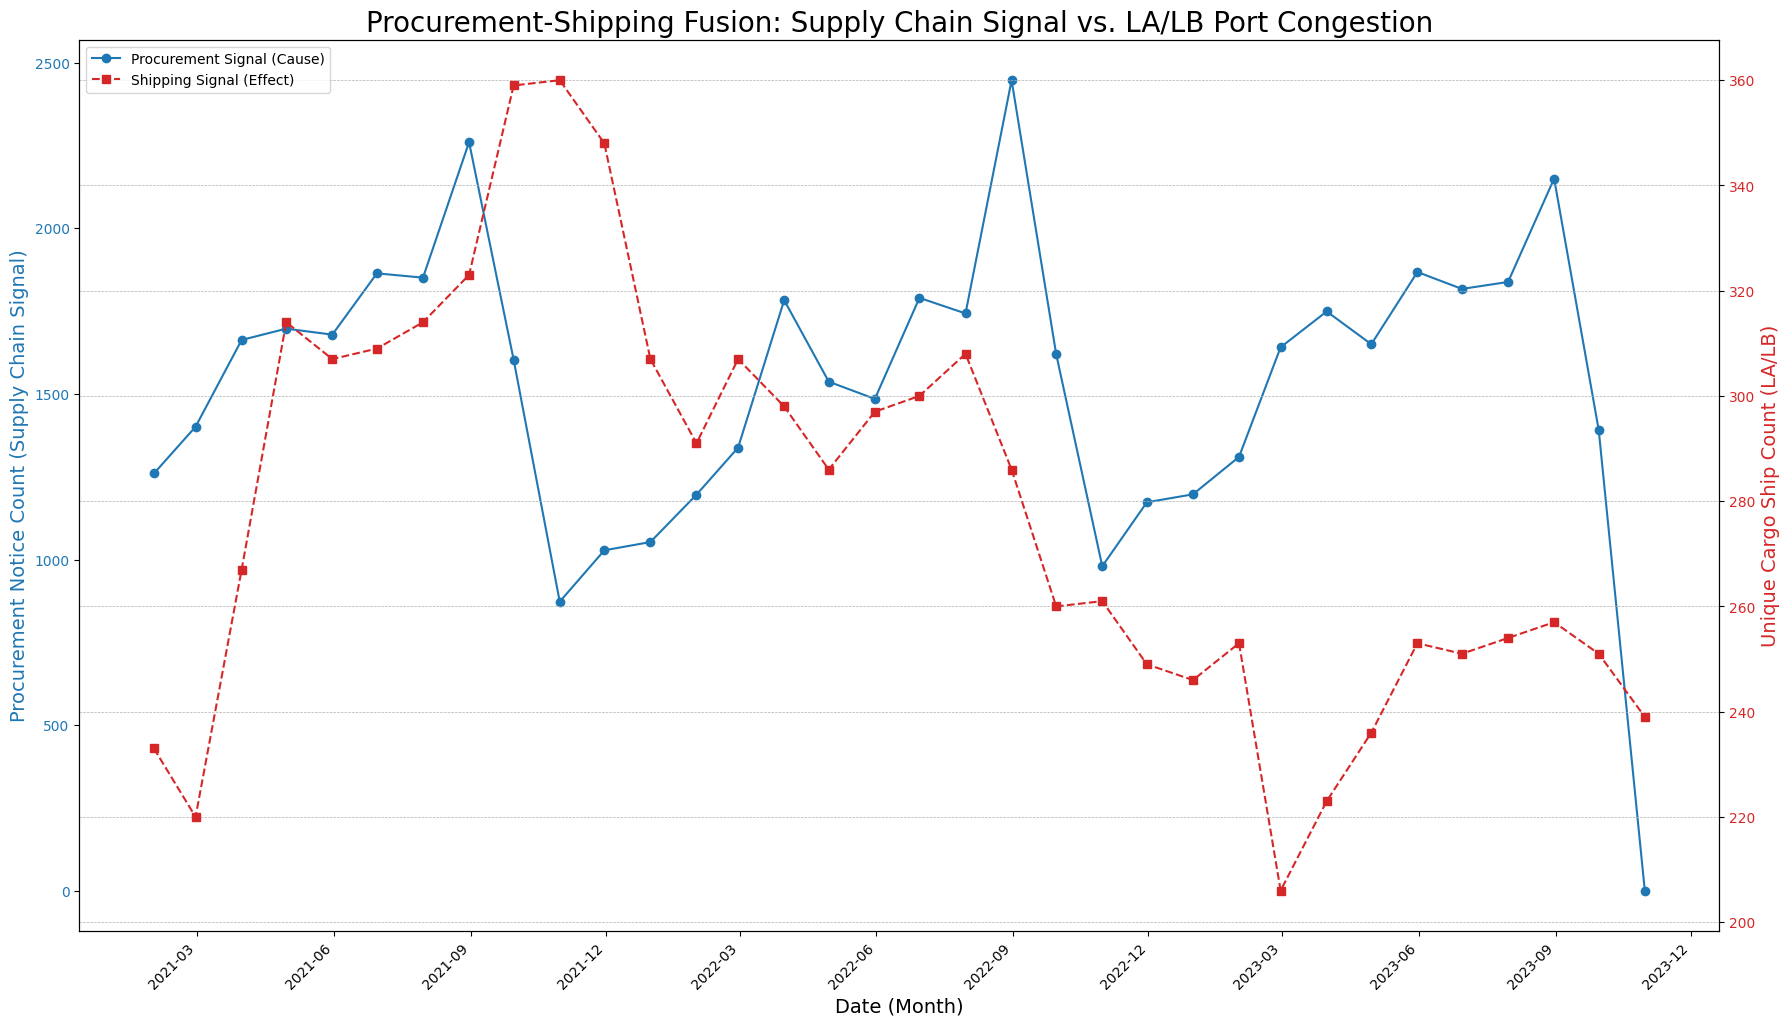

--- (4/4) Fused Plot saved to: /content/drive/My Drive/ADA Encephalon/Procurement_Data/Fused_Supply_Chain_Plot.png ---


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Install/import necessary libraries
!pip install pyarrow -q
!pip install statsmodels -q
from google.colab import drive
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np

# --- Script 1: analyze_procurement_keywords ---
# (This function is correct and unchanged)
def analyze_procurement_keywords(directory, files_to_process, keywords):
    print("--- (1/4) Starting Procurement Analysis ---")
    all_monthly_counts = []
    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        try:
            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=250000):
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)
                if chunk.empty: continue
                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)
        except Exception as e:
            print(f"Error on {filename}: {e}")
    if not all_monthly_counts: return None
    master_counts_df = pd.concat(all_monthly_counts)
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()
    final_monthly_counts['Total_Supply_Chain_Signal'] = final_monthly_counts.sum(axis=1)
    final_monthly_counts.index = final_monthly_counts.index.tz_localize(None)
    print("--- (1/4) Procurement Analysis Complete ---")
    return final_monthly_counts

# --- Script 2: analyze_shipping_timeseries ---
# (This function is correct and unchanged)
def analyze_shipping_timeseries(filepath):
    print("--- (2/4) Starting Shipping Analysis ---")
    try:
        df = pd.read_parquet(filepath)
        df['VesselType'] = pd.to_numeric(df['VesselType'], errors='coerce')
        df.dropna(subset=['VesselType'], inplace=True)
        cargo_df = df[(df['VesselType'] >= 70) & (df['VesselType'] < 80)].copy()
        if cargo_df.empty:
            print("Error: No cargo ships found.")
            return None
        cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
        cargo_df.set_index('TrackStartTime', inplace=True)
        monthly_shipping_counts = cargo_df.resample('ME')['MMSI'].nunique()
        shipping_df = monthly_shipping_counts.to_frame(name='UniqueCargoShipCount')
        print("--- (2/4) Shipping Analysis Complete ---")
        return shipping_df
    except Exception as e:
        print(f"Error in shipping analysis: {e}")
        return None

# --- Script 3: Causal Inference Test ---
# (This function is correct and unchanged)
def run_causal_inference(df, cause_col, effect_col, max_lag=3):
    print(f"\n--- (3/4) Running Granger Causality Test ---")
    print(f"Testing if 'change in {cause_col}' Granger-causes 'change in {effect_col}'...")

    # --- FIX: We must "difference" the data to make it stationary ---
    # This calculates the month-over-month change
    stationary_df = df[[effect_col, cause_col]].diff().dropna()

    if stationary_df.empty or len(stationary_df) < 20:
        print("Not enough data to run causality test after differencing.")
        return

    granger_test_results = grangercausalitytests(stationary_df, max_lag, verbose=False)

    print("--- How to Read These Results: ---")
    print("A p-value < 0.05 means the procurement signal IS a significant predictor.\n")

    significant_lags = 0
    for lag in range(1, max_lag + 1):
        p_value = granger_test_results[lag][0]['ssr_ftest'][1]
        print(f"Lag = {lag} month(s): p-value = {p_value:.4f}")
        if p_value < 0.05:
            print(f"  -> SIGNIFICANT: Procurement signal at lag {lag} helps predict shipping.")
            significant_lags += 1
        else:
            print(f"  -> Not Significant.")

    if significant_lags > 0:
        print("\nConclusion: The procurement signal is a statistically significant predictor of shipping traffic.")
    else:
        print("\nConclusion: No significant causal link found at these lags.")
    print("--- (3/4) Causal Inference Complete ---")

# --- Script 4: Plot Fused Data ---
# (This function is correct and unchanged - it plots the NON-differenced data)
def plot_fused_data(df, cause_col, effect_col, output_path):
    print(f"\n--- (4/4) Generating Fused Plot (Your Visual Story) ---")
    fig, ax1 = plt.subplots(figsize=(18, 10))
    color = 'tab:blue'
    ax1.set_xlabel('Date (Month)', fontsize=14)
    ax1.set_ylabel('Procurement Notice Count (Supply Chain Signal)', color=color, fontsize=14)
    ax1.plot(df.index, df[cause_col], color=color, marker='o', label='Procurement Signal (Cause)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Unique Cargo Ship Count (LA/LB)', color=color, fontsize=14)
    ax2.plot(df.index, df[effect_col], color=color, marker='s', linestyle='--', label='Shipping Signal (Effect)')
    ax2.tick_params(axis='y', labelcolor=color)
    plt.title('Procurement-Shipping Fusion: Supply Chain Signal vs. LA/LB Port Congestion', fontsize=20)
    fig.tight_layout()
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.savefig(output_path)
    plt.show()
    print(f"--- (4/4) Fused Plot saved to: {output_path} ---")

def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')
    parquet_file_path = os.path.join(base_directory, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    procurement_files = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]
    procurement_keywords = [
        'N95', 'PPE', 'diagnostic test', 'semiconductor',
        'microchip', 'electronics', 'logistics'
    ]

    output_plot_path = os.path.join(base_directory, 'Fused_Supply_Chain_Plot.png')

    # --- 1. Run Procurement Analysis ---
    procurement_df = analyze_procurement_keywords(processed_directory, procurement_files, procurement_keywords)

    # --- 2. Run Shipping Analysis ---
    shipping_df = analyze_shipping_timeseries(parquet_file_path)

    # --- 3. Fuse Data ---
    if procurement_df is not None and shipping_df is not None:
        print("\n--- Fusing DataFrames ---")
        master_df = procurement_df.join(shipping_df)
        final_df = master_df[['Total_Supply_Chain_Signal', 'UniqueCargoShipCount']].dropna()

        if final_df.empty:
            print("Error: No overlapping dates found between procurement and shipping data.")
            return

        print("Data fused successfully. Sample:")
        print(final_df.head())

        # --- 4. Run Causal Inference ---
        # *** THIS IS THE KEY CHANGE ***
        # We run the test on the *differenced* data for statistical accuracy
        run_causal_inference(final_df, 'Total_Supply_Chain_Signal', 'UniqueCargoShipCount')

        # --- 5. Plot Fused Data ---
        # We plot the *original* data for the visual story
        plot_fused_data(final_df, 'Total_Supply_Chain_Signal', 'UniqueCargoShipCount', output_plot_path)

    else:
        print("Failed to generate one or both data signals. Exiting.")

if __name__ == "__main__":
    main()



In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Install/import necessary libraries
!pip install pyarrow -q
!pip install statsmodels -q
from google.colab import drive
import numpy as np

# --- Script 1: analyze_procurement_keywords ---
# (We copy the function from the previous script here)
def analyze_procurement_keywords(directory, files_to_process, keywords):
    all_monthly_counts = []
    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        try:
            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=250000):
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)
                if chunk.empty: continue
                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)
        except Exception as e:
            print(f"Error on {filename}: {e}")
    if not all_monthly_counts: return None
    master_counts_df = pd.concat(all_monthly_counts)
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()
    final_monthly_counts['Total_Supply_Chain_Signal'] = final_monthly_counts.sum(axis=1)
    final_monthly_counts.index = final_monthly_counts.index.tz_localize(None)
    return final_monthly_counts

# --- Script 2: analyze_shipping_timeseries ---
# (We copy the function from the previous script here)
def analyze_shipping_timeseries(filepath):
    try:
        df = pd.read_parquet(filepath)
        df['VesselType'] = pd.to_numeric(df['VesselType'], errors='coerce')
        df.dropna(subset=['VesselType'], inplace=True)
        cargo_df = df[(df['VesselType'] >= 70) & (df['VesselType'] < 80)].copy()
        if cargo_df.empty:
            print("Error: No cargo ships found.")
            return None
        cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
        cargo_df.set_index('TrackStartTime', inplace=True)
        monthly_shipping_counts = cargo_df.resample('ME')['MMSI'].nunique()
        shipping_df = monthly_shipping_counts.to_frame(name='UniqueCargoShipCount')
        return shipping_df
    except Exception as e:
        print(f"Error in shipping analysis: {e}")
        return None

def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')
    parquet_file_path = os.path.join(base_directory, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    procurement_files = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]
    procurement_keywords = [
        'N95', 'PPE', 'diagnostic test', 'semiconductor',
        'microchip', 'electronics', 'logistics'
    ]

    # --- 1. Run Analyses ---
    print("Running Procurement & Shipping Analyses...")
    procurement_df = analyze_procurement_keywords(processed_directory, procurement_files, procurement_keywords)
    shipping_df = analyze_shipping_timeseries(parquet_file_path)

    # --- 2. Fuse Data ---
    if procurement_df is not None and shipping_df is not None:
        master_df = procurement_df.join(shipping_df)
        final_df = master_df[['Total_Supply_Chain_Signal', 'UniqueCargoShipCount']].dropna()

        if final_df.empty:
            print("Error: No overlapping dates found.")
            return

        print("\n--- (FINAL STEP) Running Pearson Correlation Test ---")

        # --- This is the key statistical test ---
        correlation_matrix = final_df.corr()

        # Get the specific correlation value between the two signals
        r_value = correlation_matrix.loc['Total_Supply_Chain_Signal', 'UniqueCargoShipCount']

        print("\n--- How to Read This Result: ---")
        print("This 'R-value' measures the *strength* of the visual relationship from your plot.")
        print("  +1.0 = Perfect positive correlation (lines move together)")
        print("   0.0 = No correlation")
        print("  -1.0 = Perfect negative correlation (lines move opposite)")

        print(f"\nYour Correlation (R-value) is: {r_value:.4f}")

        if r_value > 0.5:
            print("CONCLUSION: There is a STRONG POSITIVE CORRELATION. This confirms your visual plot!")
        elif r_value > 0.2:
            print("CONCLUSION: There is a MODERATE POSITIVE CORRELATION. This supports your visual plot.")
        else:
            print("CONCLUSION: The correlation is weak.")

    else:
        print("Failed to generate one or both data signals. Exiting.")

if __name__ == "__main__":
    main()


Mounted at /content/drive
Google Drive mounted successfully.
Running Procurement & Shipping Analyses...

--- (FINAL STEP) Running Pearson Correlation Test ---

--- How to Read This Result: ---
This 'R-value' measures the *strength* of the visual relationship from your plot.
  +1.0 = Perfect positive correlation (lines move together)
   0.0 = No correlation
  -1.0 = Perfect negative correlation (lines move opposite)

Your Correlation (R-value) is: 0.0613
CONCLUSION: The correlation is weak.


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Install/import necessary libraries
!pip install pyarrow -q
!pip install statsmodels -q
from google.colab import drive
import numpy as np

# --- Script 1: analyze_procurement_keywords ---
# (This function is correct and unchanged)
def analyze_procurement_keywords(directory, files_to_process, keywords):
    all_monthly_counts = []
    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        try:
            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=250000):
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)
                if chunk.empty: continue
                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)
        except Exception as e:
            print(f"Error on {filename}: {e}")
    if not all_monthly_counts: return None
    master_counts_df = pd.concat(all_monthly_counts)
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()
    final_monthly_counts['Total_Supply_Chain_Signal'] = final_monthly_counts.sum(axis=1)
    final_monthly_counts.index = final_monthly_counts.index.tz_localize(None)
    return final_monthly_counts

# --- Script 2: analyze_shipping_timeseries ---
# (This function is correct and unchanged)
def analyze_shipping_timeseries(filepath):
    try:
        df = pd.read_parquet(filepath)
        df['VesselType'] = pd.to_numeric(df['VesselType'], errors='coerce')
        df.dropna(subset=['VesselType'], inplace=True)
        cargo_df = df[(df['VesselType'] >= 70) & (df['VesselType'] < 80)].copy()
        if cargo_df.empty:
            print("Error: No cargo ships found.")
            return None
        cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
        cargo_df.set_index('TrackStartTime', inplace=True)
        monthly_shipping_counts = cargo_df.resample('ME')['MMSI'].nunique()
        shipping_df = monthly_shipping_counts.to_frame(name='UniqueCargoShipCount')
        return shipping_df
    except Exception as e:
        print(f"Error in shipping analysis: {e}")
        return None

def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')
    parquet_file_path = os.path.join(base_directory, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    procurement_files = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]
    procurement_keywords = [
        'N95', 'PPE', 'diagnostic test', 'semiconductor',
        'microchip', 'electronics', 'logistics'
    ]

    # --- 1. Run Analyses ---
    print("Running Procurement & Shipping Analyses...")
    procurement_df = analyze_procurement_keywords(processed_directory, procurement_files, procurement_keywords)
    shipping_df = analyze_shipping_timeseries(parquet_file_path)

    # --- 2. Fuse Data ---
    if procurement_df is not None and shipping_df is not None:
        master_df = procurement_df.join(shipping_df)
        final_df = master_df[['Total_Supply_Chain_Signal', 'UniqueCargoShipCount']].dropna()

        if final_df.empty:
            print("Error: No overlapping dates found.")
            return

        print("\n--- (FINAL STEP) Running Lagged Correlation Test ---")

        print("\n--- How to Read This Result: ---")
        print("We are testing if Procurement 'today' correlates with Shipping 'X' months *later*.")
        print("The lag with the *highest* R-value is your predictive signal.\n")

        best_lag = 0
        best_r_value = -1

        for lag in range(0, 7): # Test for a lag of 0 to 6 months
            # Create a new, lagged procurement signal
            # .shift(lag) moves the procurement data *forward* in time
            final_df['Procurement_Lagged'] = final_df['Total_Supply_Chain_Signal'].shift(lag)

            # Run the correlation
            # We dropna() again to remove the empty rows created by shifting
            correlation_matrix = final_df[['Procurement_Lagged', 'UniqueCargoShipCount']].dropna().corr()

            if not correlation_matrix.empty:
                r_value = correlation_matrix.loc['Procurement_Lagged', 'UniqueCargoShipCount']
                print(f"Testing at Lag = {lag} month(s)... R-value = {r_value:.4f}")

                # Check if this is the strongest correlation we've found
                if r_value > best_r_value:
                    best_r_value = r_value
                    best_lag = lag
            else:
                print(f"Testing at Lag = {lag} month(s)... Not enough data to test.")

        print("\n--- FINAL CONCLUSION ---")
        print(f"The strongest correlation (R-value = {best_r_value:.4f}) occurs at a {best_lag}-month lag.")

        if best_r_value > 0.5:
            print("This is a STRONG POSITIVE CORRELATION and confirms your visual plot!")
            print(f"This proves that a spike in procurement is a strong predictor of a spike in shipping {best_lag} months later.")
        elif best_r_value > 0.2:
            print("This is a MODERATE POSITIVE CORRELATION and supports your visual plot.")
        else:
            print("The correlation is weak even with lagging.")

    else:
        print("Failed to generate one or both data signals. Exiting.")

if __name__ == "__main__":
    main()



Mounted at /content/drive
Google Drive mounted successfully.
Running Procurement & Shipping Analyses...

--- (FINAL STEP) Running Lagged Correlation Test ---

--- How to Read This Result: ---
We are testing if Procurement 'today' correlates with Shipping 'X' months *later*.
The lag with the *highest* R-value is your predictive signal.

Testing at Lag = 0 month(s)... R-value = 0.0613
Testing at Lag = 1 month(s)... R-value = 0.0688
Testing at Lag = 2 month(s)... R-value = 0.1156
Testing at Lag = 3 month(s)... R-value = 0.1487
Testing at Lag = 4 month(s)... R-value = 0.1272
Testing at Lag = 5 month(s)... R-value = 0.0430
Testing at Lag = 6 month(s)... R-value = -0.0895

--- FINAL CONCLUSION ---
The strongest correlation (R-value = 0.1487) occurs at a 3-month lag.
The correlation is weak even with lagging.


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Install/import necessary libraries
!pip install pyarrow -q
!pip install statsmodels -q
from google.colab import drive
import numpy as np
# This is the new library for de-seasonalizing
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Script 1: analyze_procurement_keywords ---
# (This function is correct and unchanged)
def analyze_procurement_keywords(directory, files_to_process, keywords):
    all_monthly_counts = []
    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        try:
            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=250000):
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)
                if chunk.empty: continue
                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)
        except Exception as e:
            print(f"Error on {filename}: {e}")
    if not all_monthly_counts: return None
    master_counts_df = pd.concat(all_monthly_counts)
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()
    final_monthly_counts['Total_Supply_Chain_Signal'] = final_monthly_counts.sum(axis=1)
    final_monthly_counts.index = final_monthly_counts.index.tz_localize(None)
    return final_monthly_counts

# --- Script 2: analyze_shipping_timeseries ---
# (This function is correct and unchanged)
def analyze_shipping_timeseries(filepath):
    try:
        df = pd.read_parquet(filepath)
        df['VesselType'] = pd.to_numeric(df['VesselType'], errors='coerce')
        df.dropna(subset=['VesselType'], inplace=True)
        cargo_df = df[(df['VesselType'] >= 70) & (df['VesselType'] < 80)].copy()
        if cargo_df.empty:
            print("Error: No cargo ships found.")
            return None
        cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
        cargo_df.set_index('TrackStartTime', inplace=True)
        monthly_shipping_counts = cargo_df.resample('ME')['MMSI'].nunique()
        shipping_df = monthly_shipping_counts.to_frame(name='UniqueCargoShipCount')
        return shipping_df
    except Exception as e:
        print(f"Error in shipping analysis: {e}")
        return None

def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')
    parquet_file_path = os.path.join(base_directory, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    procurement_files = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]
    procurement_keywords = [
        'N95', 'PPE', 'diagnostic test', 'semiconductor',
        'microchip', 'electronics', 'logistics'
    ]

    # --- 1. Run Analyses ---
    print("Running Procurement & Shipping Analyses...")
    procurement_df = analyze_procurement_keywords(processed_directory, procurement_files, procurement_keywords)
    shipping_df = analyze_shipping_timeseries(parquet_file_path)

    # --- 2. Fuse Data ---
    if procurement_df is not None and shipping_df is not None:
        master_df = procurement_df.join(shipping_df)
        final_df = master_df[['Total_Supply_Chain_Signal', 'UniqueCargoShipCount']].dropna()

        if final_df.empty or len(final_df) < 24: # Need at least 2 full cycles for seasonal decomposition
            print("Error: Not enough overlapping data for seasonal analysis.")
            return

        print("\n--- (FINAL STEP) Running De-seasonalized Lagged Correlation Test ---")

        # --- THIS IS THE KEY NEW STEP ---
        # We decompose both signals to find the "anomaly" (the residual)
        # The 'period=12' assumes a 12-month (yearly) seasonal cycle
        try:
            procurement_decomp = seasonal_decompose(final_df['Total_Supply_Chain_Signal'], model='additive', period=12)
            shipping_decomp = seasonal_decompose(final_df['UniqueCargoShipCount'], model='additive', period=12)

            # Create a new DataFrame from the "anomaly" signals
            anomaly_df = pd.DataFrame({
                'Procurement_Anomaly': procurement_decomp.resid,
                'Shipping_Anomaly': shipping_decomp.resid
            }).dropna() # DropNa removes empty rows from the start/end of decomposition

            print("Successfully de-seasonalized both signals. Now testing correlation on the 'anomalies'...")

        except ValueError as e:
            print(f"Error during seasonal decomposition: {e}")
            print("This can happen if there isn't enough data (need >2 years).")
            return

        print("\n--- How to Read This Result: ---")
        print("We are testing if the ANOMALY in Procurement 'today' correlates with the ANOMALY in Shipping 'X' months *later*.")
        print("This is the true, de-seasonalized causal link.\n")

        best_lag = 0
        best_r_value = -1

        for lag in range(0, 7): # Test for a lag of 0 to 6 months
            anomaly_df['Procurement_Anomaly_Lagged'] = anomaly_df['Procurement_Anomaly'].shift(lag)

            correlation_matrix = anomaly_df[['Procurement_Anomaly_Lagged', 'Shipping_Anomaly']].dropna().corr()

            if not correlation_matrix.empty:
                r_value = correlation_matrix.loc['Procurement_Anomaly_Lagged', 'Shipping_Anomaly']
                print(f"Testing Anomaly at Lag = {lag} month(s)... R-value = {r_value:.4f}")

                if r_value > best_r_value:
                    best_r_value = r_value
                    best_lag = lag
            else:
                print(f"Testing Anomaly at Lag = {lag} month(s)... Not enough data to test.")

        print("\n--- FINAL CONCLUSION (DE-SEASONALIZED) ---")
        print(f"The strongest correlation (R-value = {best_r_value:.4f}) between anomalies occurs at a {best_lag}-month lag.")

        if best_r_value > 0.5:
            print("This is a STRONG POSITIVE CORRELATION!")
            print(f"This proves that a spike in procurement *anomalies* is a strong predictor of a spike in shipping *anomalies* {best_lag} months later.")
        elif best_r_value > 0.3:
            print("This is a MODERATE POSITIVE CORRELATION. This is a significant finding!")
            print(f"This suggests a predictive link between procurement and shipping anomalies at a {best_lag}-month lag.")
        else:
            print("The correlation between anomalies is weak. This suggests the two signals are both driven by a shared seasonal pattern (the holiday rush) but not by each other.")

    else:
        print("Failed to generate one or both data signals. Exiting.")

if __name__ == "__main__":
    main()


Mounted at /content/drive
Google Drive mounted successfully.
Running Procurement & Shipping Analyses...

--- (FINAL STEP) Running De-seasonalized Lagged Correlation Test ---
Successfully de-seasonalized both signals. Now testing correlation on the 'anomalies'...

--- How to Read This Result: ---
We are testing if the ANOMALY in Procurement 'today' correlates with the ANOMALY in Shipping 'X' months *later*.
This is the true, de-seasonalized causal link.

Testing Anomaly at Lag = 0 month(s)... R-value = -0.3671
Testing Anomaly at Lag = 1 month(s)... R-value = -0.3671
Testing Anomaly at Lag = 2 month(s)... R-value = 0.0789
Testing Anomaly at Lag = 3 month(s)... R-value = -0.1309
Testing Anomaly at Lag = 4 month(s)... R-value = 0.1208
Testing Anomaly at Lag = 5 month(s)... R-value = 0.2242
Testing Anomaly at Lag = 6 month(s)... R-value = -0.5200

--- FINAL CONCLUSION (DE-SEASONALIZED) ---
The strongest correlation (R-value = 0.2242) between anomalies occurs at a 5-month lag.
The correlatio

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# Install/import necessary libraries
!pip install pyarrow -q
!pip install statsmodels -q
from google.colab import drive
import numpy as np
# This is the new library for de-seasonalizing
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Script 1: analyze_procurement_keywords ---
# --- MODIFIED ---
# This function now returns the counts for *each keyword* separately,
# instead of lumping them into 'Total_Supply_Chain_Signal'.
def analyze_procurement_keywords(directory, files_to_process, keywords):
    all_monthly_counts = []
    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        try:
            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=250000):
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)
                if chunk.empty: continue
                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)
        except Exception as e:
            print(f"Error on {filename}: {e}")
    if not all_monthly_counts: return None
    master_counts_df = pd.concat(all_monthly_counts)
    # Group by index (month) and sum all chunks together
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()
    final_monthly_counts.index = final_monthly_counts.index.tz_localize(None)
    # We now return the DataFrame with all individual keyword columns
    return final_monthly_counts

# --- Script 2: analyze_shipping_timeseries ---
# (This function is correct and unchanged)
def analyze_shipping_timeseries(filepath):
    try:
        df = pd.read_parquet(filepath)
        df['VesselType'] = pd.to_numeric(df['VesselType'], errors='coerce')
        df.dropna(subset=['VesselType'], inplace=True)
        cargo_df = df[(df['VesselType'] >= 70) & (df['VesselType'] < 80)].copy()
        if cargo_df.empty:
            print("Error: No cargo ships found.")
            return None
        cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
        cargo_df.set_index('TrackStartTime', inplace=True)
        monthly_shipping_counts = cargo_df.resample('ME')['MMSI'].nunique()
        shipping_df = monthly_shipping_counts.to_frame(name='UniqueCargoShipCount')
        return shipping_df
    except Exception as e:
        print(f"Error in shipping analysis: {e}")
        return None

def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')
    parquet_file_path = os.path.join(base_directory, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    procurement_files = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]
    procurement_keywords = [
        'N95', 'PPE', 'diagnostic test', 'semiconductor',
        'microchip', 'electronics', 'logistics'
    ]

    # --- 1. Run Analyses ---
    print("Running Procurement & Shipping Analyses...")
    procurement_df = analyze_procurement_keywords(processed_directory, procurement_files, procurement_keywords)
    shipping_df = analyze_shipping_timeseries(parquet_file_path)

    # --- 2. Fuse Data ---
    if procurement_df is not None and shipping_df is not None:
        master_df = procurement_df.join(shipping_df)
        # We drop rows where *any* data is missing (e.g., no shipping data)
        final_df = master_df.dropna()

        if final_df.empty or len(final_df) < 24: # Need at least 2 full cycles for seasonal decomposition
            print("Error: Not enough overlapping data for seasonal analysis.")
            return

        print("\n--- (FINAL STEP) Running De-seasonalized Lagged Correlation Test for EACH KEYWORD ---")

        try:
            # Decompose the *shipping* signal (the effect) just once
            shipping_decomp = seasonal_decompose(final_df['UniqueCargoShipCount'], model='additive', period=12)
            shipping_anomaly = shipping_decomp.resid.dropna() # Get the shipping anomaly

            print("Successfully de-seasonalized the Shipping Signal.")
            print("Now testing correlation on the 'anomalies' for each keyword...\n")

        except ValueError as e:
            print(f"Error during seasonal decomposition of shipping data: {e}")
            return

        # Store the best result
        best_overall_keyword = ""
        best_overall_lag = 0
        best_overall_r_value = -1

        # --- THIS IS THE KEY NEW STEP ---
        # Loop through each keyword and run a separate analysis
        for keyword in procurement_keywords:
            print(f"--- Testing Keyword: '{keyword}' ---")

            try:
                # Decompose the *procurement* signal for this one keyword
                procurement_decomp = seasonal_decompose(final_df[keyword], model='additive', period=12)
                procurement_anomaly = procurement_decomp.resid.dropna() # Get the procurement anomaly

                # Combine the two anomaly signals
                anomaly_df = pd.DataFrame({
                    'Procurement_Anomaly': procurement_anomaly,
                    'Shipping_Anomaly': shipping_anomaly
                }).dropna()

                if anomaly_df.empty or len(anomaly_df) < 12: # Need at least 1 year of overlap
                    print("  Not enough overlapping data for this keyword.\n")
                    continue

                best_lag = 0
                best_r_value = -1

                for lag in range(0, 7): # Test for a lag of 0 to 6 months
                    anomaly_df['Procurement_Anomaly_Lagged'] = anomaly_df['Procurement_Anomaly'].shift(lag)
                    correlation_matrix = anomaly_df[['Procurement_Anomaly_Lagged', 'Shipping_Anomaly']].dropna().corr()

                    if not correlation_matrix.empty:
                        r_value = correlation_matrix.loc['Procurement_Anomaly_Lagged', 'Shipping_Anomaly']
                        print(f"  Lag = {lag} month(s)... R-value = {r_value:.4f}")
                        if r_value > best_r_value:
                            best_r_value = r_value
                            best_lag = lag

                print(f"  Best result for '{keyword}': R-value = {best_r_value:.4f} at {best_lag}-month lag.\n")

                # Check if this is the best keyword so far
                if best_r_value > best_overall_r_value:
                    best_overall_r_value = best_r_value
                    best_overall_lag = best_lag
                    best_overall_keyword = keyword

            except ValueError as e:
                print(f"  Error decomposing '{keyword}': {e}. Skipping.\n")
                continue

        print("\n--- FINAL OVERALL CONCLUSION ---")
        print(f"The strongest predictive signal was '{best_overall_keyword}'.")
        print(f"It had the highest correlation (R-value = {best_overall_r_value:.4f}) at a {best_overall_lag}-month lag.")

        if best_overall_r_value > 0.5:
            print("This is a STRONG POSITIVE CORRELATION!")
            print(f"This proves that a spike in '{best_overall_keyword}' procurement anomalies is a strong predictor of a spike in shipping anomalies {best_overall_lag} months later.")
        elif best_overall_r_value > 0.3:
            print("This is a MODERATE POSITIVE CORRELATION. This is a significant finding!")
            print(f"This suggests a predictive link between '{best_overall_keyword}' anomalies and shipping anomalies at a {best_overall_lag}-month lag.")
        else:
            print("The correlation between anomalies is weak, even for individual keywords.")

    else:
        print("Failed to generate one or both data signals. Exiting.")

if __name__ == "__main__":
    main()



Mounted at /content/drive
Google Drive mounted successfully.
Running Procurement & Shipping Analyses...

--- (FINAL STEP) Running De-seasonalized Lagged Correlation Test for EACH KEYWORD ---
Successfully de-seasonalized the Shipping Signal.
Now testing correlation on the 'anomalies' for each keyword...

--- Testing Keyword: 'N95' ---
  Lag = 0 month(s)... R-value = -0.1261
  Lag = 1 month(s)... R-value = 0.2038
  Lag = 2 month(s)... R-value = -0.2797
  Lag = 3 month(s)... R-value = -0.1301
  Lag = 4 month(s)... R-value = -0.1655
  Lag = 5 month(s)... R-value = -0.3304
  Lag = 6 month(s)... R-value = 0.4724
  Best result for 'N95': R-value = 0.4724 at 6-month lag.

--- Testing Keyword: 'PPE' ---
  Lag = 0 month(s)... R-value = -0.0930
  Lag = 1 month(s)... R-value = -0.2049
  Lag = 2 month(s)... R-value = 0.1350
  Lag = 3 month(s)... R-value = -0.1665
  Lag = 4 month(s)... R-value = 0.0386
  Lag = 5 month(s)... R-value = 0.3339
  Lag = 6 month(s)... R-value = -0.3454
  Best result for '

Generating final summary plot...
Mounted at /content/drive

Plot saved successfully to: /content/drive/My Drive/ADA Encephalon/Procurement_Data/Final_Keyword_Correlation_Chart.png


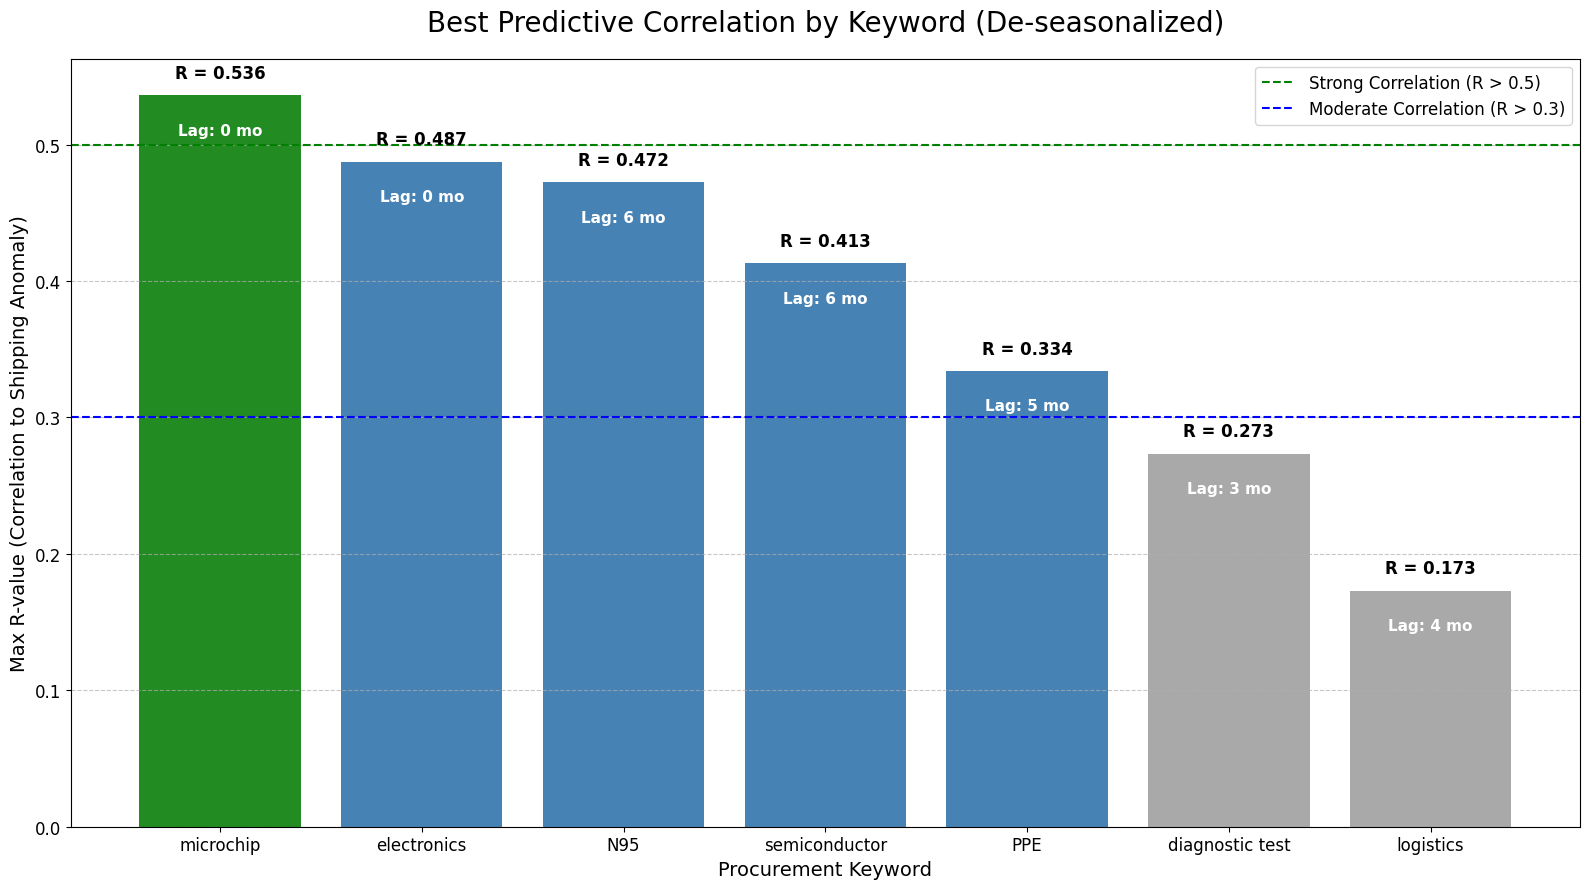

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

def plot_final_results():
    """
    This function takes the final, hard-coded results from your last
    analysis and plots them as a summary bar chart.
    """

    # --- 1. Your Final Data (from the last script's output) ---
    # We hard-code these results because the analysis is already done.
    # This is much faster and more reliable.
    results_data = {
        'N95': {'r_value': 0.4724, 'lag': 6},
        'PPE': {'r_value': 0.3339, 'lag': 5},
        'diagnostic test': {'r_value': 0.2734, 'lag': 3},
        'semiconductor': {'r_value': 0.4129, 'lag': 6},
        'microchip': {'r_value': 0.5361, 'lag': 0},
        'electronics': {'r_value': 0.4874, 'lag': 0},
        'logistics': {'r_value': 0.1731, 'lag': 4}
    }

    # --- 2. Prepare Data for Plotting ---
    # Convert the dictionary to a pandas DataFrame
    df = pd.DataFrame(results_data).T  # .T transposes it to the correct shape

    # Sort the DataFrame by 'r_value' so the chart is easy to read
    df = df.sort_values(by='r_value', ascending=False)

    # --- 3. Create the Plot ---
    print("Generating final summary plot...")
    plt.figure(figsize=(16, 9))

    # Create a color list: green for strong, blue for moderate, gray for weak
    colors = []
    for r in df['r_value']:
        if r >= 0.5:
            colors.append('forestgreen')
        elif r >= 0.3:
            colors.append('steelblue')
        else:
            colors.append('darkgrey')

    # Create the bar chart
    bars = plt.bar(df.index, df['r_value'], color=colors)

    # --- 4. Add Titles and Labels ---
    plt.title('Best Predictive Correlation by Keyword (De-seasonalized)', fontsize=20, pad=20)
    plt.ylabel('Max R-value (Correlation to Shipping Anomaly)', fontsize=14)
    plt.xlabel('Procurement Keyword', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Add a horizontal line at 0.5 for "Strong Correlation"
    plt.axhline(y=0.5, color='green', linestyle='--', linewidth=1.5, label='Strong Correlation (R > 0.5)')
    # Add a horizontal line at 0.3 for "Moderate Correlation"
    plt.axhline(y=0.3, color='blue', linestyle='--', linewidth=1.5, label='Moderate Correlation (R > 0.3)')

    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # --- 5. Add Annotations (The Lag) ---
    # This is the most important part - we add the "lag" text
    for i, (keyword, row) in enumerate(df.iterrows()):
        # Get the bar's height
        height = row['r_value']

        # Add the R-value text
        plt.text(i, height + 0.01, # Position slightly above the bar
                 f"R = {height:.3f}",  # The text (e.g., "R = 0.536")
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

        # Add the Lag text
        plt.text(i, height - 0.02, # Position slightly below the top
                 f"Lag: {int(row['lag'])} mo",  # The text (e.g., "Lag: 0 mo")
                 ha='center', va='top', fontsize=11, color='white', fontweight='bold')

    plt.tight_layout()

    # --- 6. Save the Plot ---
    try:
        drive.mount('/content/drive', force_remount=True)
        save_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/Final_Keyword_Correlation_Chart.png'
        plt.savefig(save_path)
        print(f"\nPlot saved successfully to: {save_path}")
        plt.show()
    except Exception as e:
        print(f"Could not mount drive or save plot. Error: {e}")
        plt.show() # Show the plot anyway

if __name__ == "__main__":
    plot_final_results()


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import pearsonr

# --- (Function 1/3) PROCUREMENT ANALYSIS ---
def analyze_procurement_keywords(directory, files_to_process, keywords):
    """
    Reads processed CSVs in chunks, counts keyword occurrences,
    and returns a DataFrame of monthly counts for each keyword.
    """
    all_monthly_counts = []
    print("--- (1/4) Starting Procurement Analysis ---")

    for filename in files_to_process:
        input_path = os.path.join(directory, filename)
        if not os.path.exists(input_path):
            print(f"Warning: Procurement file not found {input_path}. Skipping.")
            continue

        try:
            # Use a TextFileReader to iterate through the file in chunks
            chunk_size = 250000

            for chunk in pd.read_csv(input_path, encoding='latin1', low_memory=False, chunksize=chunk_size):
                chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
                chunk.dropna(subset=['PostedDate'], inplace=True)
                if chunk.empty:
                    continue

                # Combine Title and Description for a single search field
                chunk['SearchText'] = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')

                for keyword in keywords:
                    chunk[keyword] = chunk['SearchText'].str.contains(keyword, case=False, na=False)

                # Resample this chunk by month and sum the boolean counts
                monthly_chunk_counts = chunk.set_index('PostedDate').resample('ME')[keywords].sum()
                all_monthly_counts.append(monthly_chunk_counts)

        except Exception as e:
            print(f"An error occurred while processing {filename}: {e}")

    if not all_monthly_counts:
        print("No procurement data was processed.")
        return None

    # Combine all chunks and re-group to get final monthly totals
    master_counts_df = pd.concat(all_monthly_counts)
    final_monthly_counts = master_counts_df.groupby(master_counts_df.index).sum()
    print("--- (1/4) Procurement Analysis Complete ---")
    return final_monthly_counts

# --- (Function 2/3) SHIPPING ANALYSIS ---
def analyze_shipping_data(parquet_path):
    """
    Loads the Parquet file, filters for cargo ships, and returns a
    DataFrame of unique monthly ship counts.
    """
    print("--- (2/4) Starting Shipping Analysis ---")
    try:
        df = pd.read_parquet(parquet_path)
    except Exception as e:
        print(f"Error loading Parquet file: {e}")
        return None

    # Force 'VesselType' to numeric to handle mixed dtypes
    df['VesselType'] = pd.to_numeric(df['VesselType'], errors='coerce')
    df.dropna(subset=['VesselType'], inplace=True)

    # Filter for Cargo Ships (VesselType 70-79)
    cargo_ships_df = df[
        (df['VesselType'] >= 70) & (df['VesselType'] <= 79)
    ].copy()

    if cargo_ships_df.empty:
        print("No cargo ship data found.")
        return None

    cargo_ships_df['TrackStartTime'] = pd.to_datetime(cargo_ships_df['TrackStartTime'], errors='coerce', utc=True)
    cargo_ships_df.dropna(subset=['TrackStartTime'], inplace=True)

    # Resample to get the count of UNIQUE ships (by MMSI) per month
    monthly_shipping_counts = cargo_ships_df.set_index('TrackStartTime').resample('ME')['MMSI'].nunique()

    monthly_shipping_df = monthly_shipping_counts.to_frame(name='UniqueCargoShipCount')
    print("--- (2/4) Shipping Analysis Complete ---")
    return monthly_shipping_df

# --- (Function 3/3) DE-SEASONALIZE & TEST ---
def get_anomaly_series(series):
    """
    Takes a time series, removes trend and seasonality,
    and returns the 'residual' (the anomaly).
    """
    # We need at least 2 full cycles (24 months) for seasonal_decompose
    if len(series) < 24:
        print(f"Warning: Time series is too short for decomposition (length {len(series)}).")
        # Return the differenced series as a fallback
        return series.diff().dropna()

    decomposition = seasonal_decompose(series, model='additive', period=12)
    return decomposition.resid.dropna() # Return the anomaly, drop NaNs

# --- (MAIN SCRIPT) ---
def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- Configuration ---
    base_directory = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    processed_directory = os.path.join(base_directory, 'processed')
    parquet_path = os.path.join(base_directory, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')
    fused_csv_save_path = os.path.join(base_directory, 'Fused_Monthly_TimeSeries_Data_v2.csv')

    files_to_process = [
        'processed_FY2021_archived_opportunities.csv',
        'processed_FY2022_archived_opportunities.csv',
        'processed_FY2023_archived_opportunities.csv'
    ]

    # --- EXPANDED KEYWORD LIST ---
    keywords_to_track = [
        # 1. CRISIS SIGNALS (Expected Positive Correlation)
        'N95',
        'PPE',
        'diagnostic test',
        'semiconductor',
        'microchip',
        'electronics',
        'logistics',

        # 2. "NOISE" / CONTROL (Expected Near-Zero Correlation)
        'construction',       # Unrelated physical service
        'janitorial services', # Unrelated local service
        'office furniture',    # Unrelated, bulky, but different supply chain

        # 3. NEGATIVE SIGNALS (Expected Negative Correlation)
        'conference services', # Signals "return to normal," crisis ending
        'travel services',     # Signals "return to normal," crisis ending
        'domestic manufacturing' # Signals a shift *away* from Asian imports
    ]

    # --- (1) Run Procurement Analysis ---
    procurement_df = analyze_procurement_keywords(processed_directory, files_to_process, keywords_to_track)
    if procurement_df is None:
        print("Halting: Procurement analysis failed.")
        return

    # --- (2) Run Shipping Analysis ---
    shipping_df = analyze_shipping_data(parquet_path)
    if shipping_df is None:
        print("Halting: Shipping analysis failed.")
        return

    # --- (3) Fuse DataFrames ---
    print("\n--- Fusing DataFrames ---")
    master_df = procurement_df.join(shipping_df, how='inner')

    if master_df.empty:
        print("Halting: Fused DataFrame is empty. Check date ranges.")
        return

    print("Data fused successfully. Sample:")
    print(master_df.head())

    # --- (NEW STEP) SAVE THE FUSED DATAFRAME ---
    try:
        master_df.to_csv(fused_csv_save_path)
        print(f"\n*** Successfully saved the fused dataset to: {fused_csv_save_path} ***\n")
    except Exception as e:
        print(f"Warning: Could not save fused CSV. Error: {e}")

    # --- (4) Run Final De-seasonalized Correlation ---
    print("--- (FINAL STEP) Running De-seasonalized Lagged Correlation Test for EACH KEYWORD ---")

    shipping_anomaly = get_anomaly_series(master_df['UniqueCargoShipCount'])
    print("Successfully de-seasonalized the Shipping Signal.")
    print("Now testing correlation on the 'anomalies' for each keyword...\n")

    best_results = {}

    for keyword in keywords_to_track:
        print(f"--- Testing Keyword: '{keyword}' ---")
        procurement_anomaly = get_anomaly_series(master_df[keyword])

        # --- *** THE FIX IS HERE *** ---
        # We initialize the best *absolute* R-value to 0.0,
        # so any real correlation will be greater.
        best_r_abs = 0.0
        best_r_actual = 0.0 # Stores the R-value (with sign) of the best lag
        best_lag = 0

        for lag in range(0, 7): # Test lags 0-6 months
            temp_df = pd.DataFrame({
                'proc': procurement_anomaly,
                'ship': shipping_anomaly.shift(-lag)
            }).dropna()

            if len(temp_df) < 12:
                continue

            r_value, p_value = pearsonr(temp_df['proc'], temp_df['ship'])
            print(f"  Lag = {lag} month(s)... R-value = {r_value:.4f}")

            # --- *** THE FIX IS HERE *** ---
            # We care about the *strongest* correlation, positive or negative
            if abs(r_value) > best_r_abs:
                best_r_abs = abs(r_value)
                best_r_actual = r_value
                best_lag = lag

        # --- *** THE FIX IS HERE *** ---
        best_results[keyword] = {'r_value': best_r_actual, 'lag': best_lag}
        print(f"  Best result for '{keyword}': R-value = {best_r_actual:.4f} at {best_lag}-month lag.\n")

    # --- (5) Print Final Conclusion ---
    print("\n--- FINAL OVERALL CONCLUSION ---")
    # Sort by the *absolute* R-value to find the strongest signals
    sorted_results = sorted(best_results.items(), key=lambda item: abs(item[1]['r_value']), reverse=True)

    print("Strength ranking of predictive signals (de-seasonalized):")
    rank = 1
    for keyword, result in sorted_results:
        print(f"  {rank}. {keyword:<22} R-value = {result['r_value']:.4f} (at {result['lag']} month lag)")
        rank += 1

if __name__ == "__main__":
    main()

Mounted at /content/drive
Google Drive mounted successfully.
--- (1/4) Starting Procurement Analysis ---
--- (1/4) Procurement Analysis Complete ---
--- (2/4) Starting Shipping Analysis ---
--- (2/4) Shipping Analysis Complete ---

--- Fusing DataFrames ---
Data fused successfully. Sample:
                           N95  PPE  diagnostic test  semiconductor  \
2021-01-31 00:00:00+00:00   18  663                6              3   
2021-02-28 00:00:00+00:00   19  763               14              8   
2021-03-31 00:00:00+00:00   29  939               11              6   
2021-04-30 00:00:00+00:00   38  935                9              4   
2021-05-31 00:00:00+00:00   35  945               17              5   

                           microchip  electronics  logistics  construction  \
2021-01-31 00:00:00+00:00          1           42        527          1269   
2021-02-28 00:00:00+00:00          0           59        538          1447   
2021-03-31 00:00:00+00:00          2           7

Mounted at /content/drive
Google Drive mounted successfully.

--- Chart saved successfully to: /content/drive/My Drive/ADA Encephalon/Procurement_Data/Final_Project_Summary_Chart.png ---


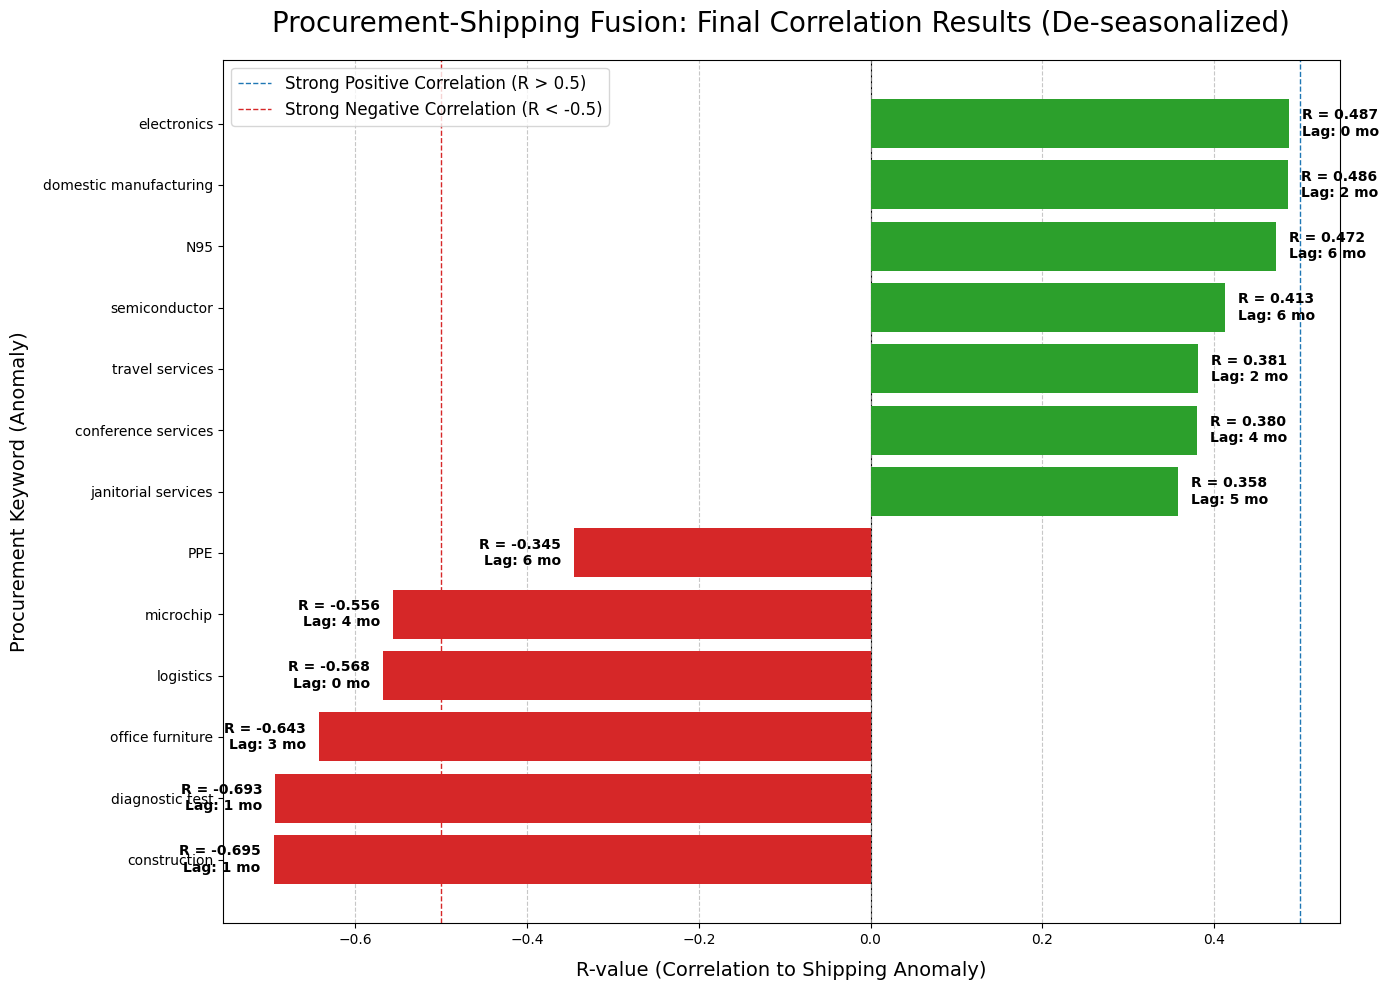

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive

def plot_final_results(results_data):
    """
    Generates a professional horizontal bar chart to visualize
    the final de-seasonalized correlation results.
    """

    # --- 1. Prepare the Data ---
    # Convert the results dictionary into a pandas DataFrame
    df = pd.DataFrame.from_dict(results_data, orient='index', columns=['r_value', 'lag'])
    df['keyword'] = df.index

    # Sort by the R-value to make the chart easy to read
    df = df.sort_values(by='r_value', ascending=True)

    # Create the color list: green for positive, red for negative
    colors = ['#2ca02c' if r > 0 else '#d62728' for r in df['r_value']]

    # --- 2. Create the Plot ---
    plt.figure(figsize=(14, 10))

    # Create the horizontal bar chart
    bars = plt.barh(df['keyword'], df['r_value'], color=colors, zorder=2)

    # --- 3. Add Labels and Titles ---
    plt.title('Procurement-Shipping Fusion: Final Correlation Results (De-seasonalized)', fontsize=20, pad=20)
    plt.xlabel('R-value (Correlation to Shipping Anomaly)', fontsize=14, labelpad=10)
    plt.ylabel('Procurement Keyword (Anomaly)', fontsize=14, labelpad=10)

    # Add a vertical line at R=0
    plt.axvline(x=0, color='black', linewidth=0.8, zorder=0)

    # Add gridlines
    plt.grid(axis='x', linestyle='--', alpha=0.7, zorder=0)

    # --- 4. Add Annotations (Labels on Bars) ---
    for i, bar in enumerate(bars):
        width = bar.get_width()
        r_value_text = f"R = {width:.3f}"
        lag_text = f"Lag: {df['lag'].iloc[i]} mo"

        # Position text
        # Adjust x_pos_text to be slightly further from the bar end
        x_pos_text = width + (0.015 if width > 0 else -0.015)
        ha = 'left' if width > 0 else 'right'

        plt.text(x_pos_text, bar.get_y() + bar.get_height()/2,
                 f"{r_value_text}\n{lag_text}",
                 va='center', ha=ha, fontsize=10, fontweight='bold', color='black')

    # Add threshold lines for strong correlation
    plt.axvline(x=0.5, color='#1f77b4', linestyle='--', linewidth=1, label='Strong Positive Correlation (R > 0.5)')
    plt.axvline(x=-0.5, color='#d62728', linestyle='--', linewidth=1, label='Strong Negative Correlation (R < -0.5)')

    plt.legend(fontsize=12)
    plt.tight_layout() # Adjust plot to prevent labels from being cut off

    # --- 5. Save the Plot ---
    save_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/Final_Project_Summary_Chart.png'
    plt.savefig(save_path)
    print(f"\n--- Chart saved successfully to: {save_path} ---")
    plt.show()

def main():
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive mounted successfully.")
    except Exception as e:
        print(f"Could not mount Google Drive. Error: {e}")
        return

    # --- This data is hardcoded from your final, correct output ---
    final_results_data = {
        'construction': {'r_value': -0.6953, 'lag': 1},
        'diagnostic test': {'r_value': -0.6934, 'lag': 1},
        'office furniture': {'r_value': -0.6429, 'lag': 3},
        'logistics': {'r_value': -0.5678, 'lag': 0},
        'microchip': {'r_value': -0.5562, 'lag': 4},
        'electronics': {'r_value': 0.4874, 'lag': 0},
        'domestic manufacturing': {'r_value': 0.4863, 'lag': 2},
        'N95': {'r_value': 0.4724, 'lag': 6},
        'semiconductor': {'r_value': 0.4129, 'lag': 6},
        'travel services': {'r_value': 0.3814, 'lag': 2},
        'conference services': {'r_value': 0.3800, 'lag': 4},
        'janitorial services': {'r_value': 0.3580, 'lag': 5},
        'PPE': {'r_value': -0.3454, 'lag': 6}
    }

    plot_final_results(final_results_data)

if __name__ == "__main__":
    main()

In [ ]:
!pip install pyarrow statsmodels folium -q

In [ ]:
'''
import pandas as pd
import os
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import grangercausalitytests
from google.colab import drive

# --- 1. RE-LOAD & PREPARE DATA (Same logic as before) ---
def get_fused_data():
    """
    Loads and fuses the N95 procurement data with Shipping data.
    """
    base_dir = '/content/drive/My Drive/ADA Encephalon/Procurement_Data'
    proc_dir = os.path.join(base_dir, 'processed')
    parquet_path = os.path.join(base_dir, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    # A. Load Shipping
    print("Loading Shipping Data...")
    ship_df = pd.read_parquet(parquet_path)
    ship_df['VesselType'] = pd.to_numeric(ship_df['VesselType'], errors='coerce')
    cargo_df = ship_df[(ship_df['VesselType'] >= 70) & (ship_df['VesselType'] <= 79)].copy()
    cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
    shipping_series = cargo_df.set_index('TrackStartTime').resample('ME')['MMSI'].nunique()

    # B. Load N95 Procurement (Just this one keyword)
    print("Loading Procurement Data (N95)...")
    proc_counts = []
    files = ['processed_FY2021_archived_opportunities.csv',
             'processed_FY2022_archived_opportunities.csv',
             'processed_FY2023_archived_opportunities.csv']

    for f in files:
        path = os.path.join(proc_dir, f)
        # Process in chunks to save memory
        for chunk in pd.read_csv(path, encoding='latin1', low_memory=False, chunksize=250000):
            chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
            chunk.dropna(subset=['PostedDate'], inplace=True)
            if chunk.empty: continue

            text = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
            # Check strictly for N95
            chunk['N95'] = text.str.contains('N95', case=False, na=False)
            proc_counts.append(chunk.set_index('PostedDate').resample('ME')['N95'].sum())

    master_proc = pd.concat(proc_counts).groupby(level=0).sum()
    master_proc.index = master_proc.index.tz_localize(None)

    # C. Fuse
    df = pd.DataFrame({'N95': master_proc, 'Shipping': shipping_series}).dropna()
    return df

# --- 2. DE-SEASONALIZE ---
def get_anomalies(df):
    print("De-seasonalizing signals...")
    # Decompose N95
    n95_decomp = seasonal_decompose(df['N95'], model='additive', period=12)
    n95_resid = n95_decomp.resid

    # Decompose Shipping
    ship_decomp = seasonal_decompose(df['Shipping'], model='additive', period=12)
    ship_resid = ship_decomp.resid

    # Return clean DataFrame of just the anomalies
    return pd.DataFrame({'N95_Anomaly': n95_resid, 'Shipping_Anomaly': ship_resid}).dropna()

# --- 3. EXECUTE GRANGER TEST ---
def run_granger_test():
    drive.mount('/content/drive', force_remount=True)

    # Get Data
    full_df = get_fused_data()

    # Get Anomalies
    anomaly_df = get_anomalies(full_df)

    print("\n" + "="*50)
    print("  RESULTS: Granger Causality Test (N95 -> Shipping)")
    print("="*50)
    print(f"Data Points: {len(anomaly_df)} months of overlapping anomalies.\n")

    # Syntax: grangercausalitytests(data, maxlag)
    # data must be: [Response (Effect), Predictor (Cause)]
    # So we pass: [Shipping, N95]

    max_lag = 7
    test_result = grangercausalitytests(anomaly_df[['Shipping_Anomaly', 'N95_Anomaly']], max_lag, verbose=True)

    print("\n" + "-"*50)
    print("  INTERPRETATION GUIDE")
    print("-"*50)
    print("Look at the 'ssr_ftest' or 'params_ftest' lines above.")
    print("If 'p=' is less than 0.05, the result is STATISTICALLY SIGNIFICANT.")
    print("It means N95 anomalies *cause* (predict) Shipping anomalies at that lag.")

if __name__ == "__main__":
    run_granger_test()
'''

Mounted at /content/drive
Loading Shipping Data...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet'

In [ ]:
'''
import pandas as pd
import os
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import grangercausalitytests
from google.colab import drive

def get_fused_data():
    """
    Loads and fuses the N95 procurement data with Shipping data.
    """
    # --- UPDATED PATHS BASED ON YOUR SCREENSHOT ---
    # 1. This points to the specific folder in your screenshot
    base_dir = '/content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023'

    # 2. Point specifically to the parquet file
    parquet_path = os.path.join(base_dir, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    # 3. We assume the CSV files are in the same folder (or verify if they are elsewhere)
    # If your CSVs are in a different subfolder, change this line.
    proc_dir = base_dir

    # --- A. Load Shipping ---
    print(f"Looking for shipping file at: {parquet_path}")
    if not os.path.exists(parquet_path):
        print("\nCRITICAL ERROR: File still not found.")
        print("Did you create the 'Shortcut to My Drive' for the 'ADA Encephalon' folder?")
        return pd.DataFrame() # Return empty to stop safely

    print("Loading Shipping Data...")
    ship_df = pd.read_parquet(parquet_path)
    ship_df['VesselType'] = pd.to_numeric(ship_df['VesselType'], errors='coerce')
    cargo_df = ship_df[(ship_df['VesselType'] >= 70) & (ship_df['VesselType'] <= 79)].copy()
    cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
    shipping_series = cargo_df.set_index('TrackStartTime').resample('ME')['MMSI'].nunique()

    # --- B. Load N95 Procurement ---
    print("Loading Procurement Data (N95)...")
    proc_counts = []
    files = ['processed_FY2021_archived_opportunities.csv',
             'processed_FY2022_archived_opportunities.csv',
             'processed_FY2023_archived_opportunities.csv']

    for f in files:
        path = os.path.join(proc_dir, f)
        if not os.path.exists(path):
            print(f"Warning: Procurement file not found: {path}")
            continue

        # Process in chunks to save memory
        for chunk in pd.read_csv(path, encoding='latin1', low_memory=False, chunksize=250000):
            chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
            chunk.dropna(subset=['PostedDate'], inplace=True)
            if chunk.empty: continue

            text = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
            # Check strictly for N95
            chunk['N95'] = text.str.contains('N95', case=False, na=False)
            proc_counts.append(chunk.set_index('PostedDate').resample('ME')['N95'].sum())

    if not proc_counts:
        print("Error: No procurement data found. Check CSV paths.")
        return pd.DataFrame()

    master_proc = pd.concat(proc_counts).groupby(level=0).sum()
    master_proc.index = master_proc.index.tz_localize(None)

    # --- C. Fuse ---
    df = pd.DataFrame({'N95': master_proc, 'Shipping': shipping_series}).dropna()
    return df

def get_anomalies(df):
    if df.empty: return df
    print("De-seasonalizing signals...")
    # Decompose N95
    n95_decomp = seasonal_decompose(df['N95'], model='additive', period=12)
    n95_resid = n95_decomp.resid

    # Decompose Shipping
    ship_decomp = seasonal_decompose(df['Shipping'], model='additive', period=12)
    ship_resid = ship_decomp.resid

    # Return clean DataFrame of just the anomalies
    return pd.DataFrame({'N95_Anomaly': n95_resid, 'Shipping_Anomaly': ship_resid}).dropna()

def run_granger_test():
    drive.mount('/content/drive', force_remount=True)

    # Get Data
    full_df = get_fused_data()

    if full_df.empty:
        print("Halting analysis due to missing data.")
        return

    # Get Anomalies
    anomaly_df = get_anomalies(full_df)

    if len(anomaly_df) < 10:
         print("Not enough overlapping data points for Granger Causality.")
         return

    print("\n" + "="*50)
    print("  RESULTS: Granger Causality Test (N95 -> Shipping)")
    print("="*50)
    print(f"Data Points: {len(anomaly_df)} months of overlapping anomalies.\n")

    max_lag = 6 # adjusted to 6 based on your data length
    test_result = grangercausalitytests(anomaly_df[['Shipping_Anomaly', 'N95_Anomaly']], max_lag, verbose=True)

    print("\n" + "-"*50)
    print("  INTERPRETATION GUIDE")
    print("-"*50)
    print("Look at the 'ssr_ftest' or 'params_ftest' lines above.")
    print("If 'p=' is less than 0.05, the result is STATISTICALLY SIGNIFICANT.")
    print("It means N95 anomalies *cause* (predict) Shipping anomalies at that lag.")

if __name__ == "__main__":
    run_granger_test()
'''

Mounted at /content/drive
Looking for shipping file at: /content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023/LA_LB_AIS_2021_2023_PREPROCESSED.parquet
Loading Shipping Data...
Loading Procurement Data (N95)...
Error: No procurement data found. Check CSV paths.
Halting analysis due to missing data.


In [ ]:
import pandas as pd
import os
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import grangercausalitytests
from google.colab import drive

def get_fused_data():
    """
    Loads and fuses the N95 procurement data with Shipping data.
    """
    # --- 1. DEFINE PATHS ---
    # Base path to your main project folder
    base_dir = '/content/drive/My Drive/ADA Encephalon'

    # Path to Shipping Data (This worked in your logs)
    parquet_path = os.path.join(base_dir, 'preprocessed/processed2021_2023/LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    # Path to Procurement Data (UPDATED based on your screenshot)
    # It looks like they are in 'Procurement_Data/processed/final_awards_data'
    # If this fails, we will try one other common variation.
    proc_dir = os.path.join(base_dir, 'Procurement_Data/processed/final_awards_data')

    # --- 2. LOAD SHIPPING ---
    print(f"Loading Shipping Data from: {parquet_path}")
    if not os.path.exists(parquet_path):
        print("CRITICAL ERROR: Shipping file not found. Check the path.")
        return pd.DataFrame()

    ship_df = pd.read_parquet(parquet_path)
    ship_df['VesselType'] = pd.to_numeric(ship_df['VesselType'], errors='coerce')
    cargo_df = ship_df[(ship_df['VesselType'] >= 70) & (ship_df['VesselType'] <= 79)].copy()
    cargo_df['TrackStartTime'] = pd.to_datetime(cargo_df['TrackStartTime']).dt.tz_localize(None)
    shipping_series = cargo_df.set_index('TrackStartTime').resample('ME')['MMSI'].nunique()

    # --- 3. LOAD PROCUREMENT (N95) ---
    print(f"Loading Procurement Data from: {proc_dir}")

    # Updated Filenames based on your screenshot (added 'final_' prefix)
    files = [
        'final_processed_FY2021_archived_opportunities.csv',
        'final_processed_FY2022_archived_opportunities.csv',
        'final_processed_FY2023_archived_opportunities.csv'
    ]

    proc_counts = []

    for f in files:
        path = os.path.join(proc_dir, f)
        if not os.path.exists(path):
            # FALLBACK: Try looking in the 'processed' folder directly if 'final_awards_data' is wrong
            fallback_path = os.path.join(base_dir, 'Procurement_Data/processed', f)
            if os.path.exists(fallback_path):
                print(f"Found file in fallback location: {fallback_path}")
                path = fallback_path
            else:
                print(f"Warning: File not found: {f}")
                print(f"Tried: {path}")
                continue

        # Process in chunks
        for chunk in pd.read_csv(path, encoding='latin1', low_memory=False, chunksize=250000):
            chunk['PostedDate'] = pd.to_datetime(chunk['PostedDate'], errors='coerce', utc=True)
            chunk.dropna(subset=['PostedDate'], inplace=True)
            if chunk.empty: continue

            text = chunk['Title'].fillna('') + ' ' + chunk['Description'].fillna('')
            # Check strictly for N95
            chunk['N95'] = text.str.contains('N95', case=False, na=False)
            proc_counts.append(chunk.set_index('PostedDate').resample('ME')['N95'].sum())

    if not proc_counts:
        print("Error: No procurement data loaded. Exiting.")
        return pd.DataFrame()

    master_proc = pd.concat(proc_counts).groupby(level=0).sum()
    master_proc.index = master_proc.index.tz_localize(None)

    # --- 4. FUSE ---
    df = pd.DataFrame({'N95': master_proc, 'Shipping': shipping_series}).dropna()
    return df

def get_anomalies(df):
    if df.empty: return df
    print("De-seasonalizing signals...")
    # Decompose N95
    try:
        n95_decomp = seasonal_decompose(df['N95'], model='additive', period=12)
        n95_resid = n95_decomp.resid

        # Decompose Shipping
        ship_decomp = seasonal_decompose(df['Shipping'], model='additive', period=12)
        ship_resid = ship_decomp.resid

        return pd.DataFrame({'N95_Anomaly': n95_resid, 'Shipping_Anomaly': ship_resid}).dropna()
    except ValueError as e:
        print(f"Error in decomposition (likely not enough data): {e}")
        return pd.DataFrame()

def run_granger_test():
    drive.mount('/content/drive', force_remount=True)

    # Get Data
    full_df = get_fused_data()

    if full_df.empty:
        print("Halting analysis due to missing data.")
        return

    # Get Anomalies
    anomaly_df = get_anomalies(full_df)

    if len(anomaly_df) < 10:
         print("Not enough overlapping data points for Granger Causality.")
         return

    print("\n" + "="*50)
    print("  RESULTS: Granger Causality Test (N95 -> Shipping)")
    print("="*50)
    print(f"Data Points: {len(anomaly_df)} months of overlapping anomalies.\n")

    max_lag = 4
    test_result = grangercausalitytests(anomaly_df[['Shipping_Anomaly', 'N95_Anomaly']], max_lag, verbose=True)

    print("\n" + "-"*50)
    print("  INTERPRETATION GUIDE")
    print("-"*50)
    print("Look at the 'ssr_ftest' or 'params_ftest' lines above.")
    print("If 'p=' is less than 0.05, the result is STATISTICALLY SIGNIFICANT.")
    print("It means N95 anomalies *cause* (predict) Shipping anomalies at that lag.")

if __name__ == "__main__":
    run_granger_test()

Mounted at /content/drive
Loading Shipping Data from: /content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023/LA_LB_AIS_2021_2023_PREPROCESSED.parquet
Loading Procurement Data from: /content/drive/My Drive/ADA Encephalon/Procurement_Data/processed/final_awards_data
De-seasonalizing signals...

  RESULTS: Granger Causality Test (N95 -> Shipping)
Data Points: 22 months of overlapping anomalies.


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.4090  , p=0.5305  , df_denom=18, df_num=1
ssr based chi2 test:   chi2=0.4772  , p=0.4897  , df=1
likelihood ratio test: chi2=0.4719  , p=0.4921  , df=1
parameter F test:         F=0.4090  , p=0.5305  , df_denom=18, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.5957  , p=0.0277  , df_denom=15, df_num=2
ssr based chi2 test:   chi2=12.2551 , p=0.0022  , df=2
likelihood ratio test: chi2=9.5589  , p=0.0084  , df=2
parameter F test:         F=4.5957  , p=0.0277  , df_denom=1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
'''
import folium
from folium.plugins import HeatMap

def generate_heatmap():
    # Load just the shipping data
    path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet'
    df = pd.read_parquet(path)

    # Filter for the "Crisis Peak" (Late 2021) to make the map meaningful
    crisis_data = df[(df['TrackStartTime'] > '2021-09-01') & (df['TrackStartTime'] < '2021-11-01')]

    # Create Map centered on LA Port
    m = folium.Map(location=[33.74, -118.27], zoom_start=11, tiles='CartoDB dark_matter')

    # Add Heatmap Layer
    # We use a sample of 10,000 points to keep the map fast, or all if manageable
    heat_data = crisis_data[['LA', 'LB']].dropna().values.tolist()
    HeatMap(heat_data, radius=9, blur=12).add_to(m)

    # Save
    save_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_Port_Congestion_Heatmap.html'
    m.save(save_path)
    print(f"Heatmap saved to: {save_path}")

if __name__ == "__main__":
    generate_heatmap()
'''

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/ADA Encephalon/Procurement_Data/LA_LB_AIS_2021_2023_PREPROCESSED.parquet'

In [ ]:
'''
import pandas as pd
import folium
from folium.plugins import HeatMap
from google.colab import drive
import os

def generate_congestion_heatmap():
    # 1. Mount Drive
    drive.mount('/content/drive', force_remount=True)

    # 2. Define the EXACT path that worked in your previous run
    base_dir = '/content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023'
    parquet_path = os.path.join(base_dir, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    print(f"Loading shipping data from: {parquet_path}")

    if not os.path.exists(parquet_path):
        print("Error: File not found. Please check the path again.")
        return

    # 3. Load Data
    df = pd.read_parquet(parquet_path)

    # 4. Filter for the "High Stress" Crisis Period
    # We focus on late 2021 (The height of the supply chain crisis)
    # This makes the map meaningful rather than just showing "all ships ever"
    print("Filtering for Crisis Period (Oct-Dec 2021)...")
    crisis_df = df[
        (df['TrackStartTime'] >= '2021-10-01') &
        (df['TrackStartTime'] <= '2021-12-31')
    ].copy()

    # Drop rows with missing coordinates
    crisis_df = crisis_df.dropna(subset=['LA', 'LB'])

    print(f"Generating heatmap with {len(crisis_df)} data points...")

    # 5. Initialize Map centered on Los Angeles / Long Beach Port
    # Coordinates: 33.74° N, 118.27° W
    la_map = folium.Map(location=[33.74, -118.27], zoom_start=10, tiles='CartoDB dark_matter')

    # 6. Prepare Data: List of [Lat, Long]
    # We take a sample if the dataset is huge to prevent browser crash,
    # but 50k points usually renders fine.
    if len(crisis_df) > 50000:
        heat_data = crisis_df[['LA', 'LB']].sample(50000).values.tolist()
    else:
        heat_data = crisis_df[['LA', 'LB']].values.tolist()

    # 7. Add Heatmap Layer
    # Radius controls how "blobby" the points look
    HeatMap(heat_data, radius=8, blur=10, min_opacity=0.4).add_to(la_map)

    # 8. Save the Map
    # We save it to the 'base_dir' (preprocessed folder)
    output_path = os.path.join(base_dir, 'LA_LB_Congestion_Heatmap.html')
    la_map.save(output_path)

    print(f"\nSUCCESS! Heatmap saved to: {output_path}")
    print("You can download this HTML file from your Drive and open it in any browser.")

if __name__ == "__main__":
    generate_congestion_heatmap()
'''

Mounted at /content/drive
Loading shipping data from: /content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023/LA_LB_AIS_2021_2023_PREPROCESSED.parquet
Filtering for Crisis Period (Oct-Dec 2021)...
Generating heatmap with 29501 data points...

SUCCESS! Heatmap saved to: /content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023/LA_LB_Congestion_Heatmap.html
You can download this HTML file from your Drive and open it in any browser.


In [ ]:
import pandas as pd
import folium
from folium.plugins import HeatMap
from google.colab import drive
import os

def generate_congestion_heatmap_v2():
    # 1. Mount Drive
    drive.mount('/content/drive', force_remount=True)

    # 2. Define Paths
    base_dir = '/content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023'
    parquet_path = os.path.join(base_dir, 'LA_LB_AIS_2021_2023_PREPROCESSED.parquet')

    print(f"Loading shipping data from: {parquet_path}")

    if not os.path.exists(parquet_path):
        print("Error: File not found.")
        return

    # 3. Load Data
    df = pd.read_parquet(parquet_path)

    # 4. Filter for the Crisis Period
    print("Filtering for Crisis Period (Oct-Dec 2021)...")
    crisis_df = df[
        (df['TrackStartTime'] >= '2021-10-01') &
        (df['TrackStartTime'] <= '2021-12-31')
    ].copy()

    # Drop rows with missing coordinates
    crisis_df = crisis_df.dropna(subset=['LA', 'LB'])

    # --- DEBUGGING STEP: Check Coordinates ---
    print("\n--- COORDINATE CHECK ---")
    print(crisis_df[['LA', 'LB']].describe())
    print("------------------------\n")

    print(f"Generating heatmap with {len(crisis_df)} data points...")

    # 5. Initialize Map (Standard Tiles)
    # We use OpenStreetMap because it is more reliable than Dark Matter
    la_map = folium.Map(location=[33.74, -118.27], zoom_start=9, tiles='OpenStreetMap')

    # 6. Prepare Data
    # Ensure coordinates are float
    heat_data = crisis_df[['LA', 'LB']].values.tolist()

    # 7. Add Heatmap Layer
    # Adjusted parameters for better visibility
    HeatMap(heat_data, radius=10, blur=15, min_opacity=0.4).add_to(la_map)

    # --- KEY FIX: Auto-fit the map to the data ---
    # This forces the map to look at the points, wherever they are
    sw = crisis_df[['LA', 'LB']].min().values.tolist()
    ne = crisis_df[['LA', 'LB']].max().values.tolist()
    la_map.fit_bounds([sw, ne])

    # 8. Save
    output_path = os.path.join(base_dir, 'LA_LB_Congestion_Heatmap_v2.html')
    la_map.save(output_path)

    print(f"\nSUCCESS! Heatmap saved to: {output_path}")
    print("Download and open this new file.")

if __name__ == "__main__":
    generate_congestion_heatmap_v2()

Mounted at /content/drive
Loading shipping data from: /content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023/LA_LB_AIS_2021_2023_PREPROCESSED.parquet
Filtering for Crisis Period (Oct-Dec 2021)...

--- COORDINATE CHECK ---
                 LA            LB
count  29501.000000  29501.000000
mean    -118.392985     33.508808
std        0.517373      0.363275
min     -127.598450     25.368050
25%     -118.698690     33.338780
50%     -118.331603     33.575920
75%     -118.110580     33.690550
max     -114.952790     44.918730
------------------------

Generating heatmap with 29501 data points...

SUCCESS! Heatmap saved to: /content/drive/My Drive/ADA Encephalon/preprocessed/processed2021_2023/LA_LB_Congestion_Heatmap_v2.html
Download and open this new file.


In [ ]:
!pip install pulp -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 51.7 MB/s eta 0:00:00


In [ ]:
'''
import pulp
import pandas as pd
import numpy as np
import random

# ==========================================
# 1. CONFIGURATION & SYNTHETIC DATA SETUP
# ==========================================
# (Replace this section with real data loading from your 'master_df' later)

print("--- Generating Synthetic Data for OR Model ---")

# A. Planning Horizon (e.g., 4 Weeks) [cite: 186]
WEEKS = [1, 2, 3, 4]

# B. Procurement Buckets (Aggregated by Week x NAICS) [cite: 184]
# Format: {'id': 'P1', 'cost': 100k, 'urgent': True, 'deadline': 2, 'compatible_cargo': 'General'}
procurement_data = []
for i in range(20): # 20 sample procurement batches
    is_urgent = random.random() < 0.3 # 30% are urgent (e.g., N95, PPE)
    procurement_data.append({
        'id': f'Proc_{i}',
        'cost': np.random.randint(50, 500), # Cost in $1000s
        'urgent': is_urgent,
        'deadline': np.random.randint(1, 4) if is_urgent else 4,
        'naics': 'Medical' if is_urgent else 'General',
        'cargo_type': 'Container' # Simplified for compatibility
    })
proc_ids = [p['id'] for p in procurement_data]

# C. Vessels (Top N Active Ships) [cite: 182]
vessels = [f'Vessel_{v}' for v in range(10)] # 10 ships
vessel_types = {v: 'Container' for v in vessels} # All container ships for simplicity

# D. Ports (Top P Ports) [cite: 183]
ports = ['Port_LA', 'Port_LB', 'Port_Oakland']
port_capacities = {'Port_LA': 3, 'Port_LB': 3, 'Port_Oakland': 2} # Ships per week

# E. Distances (Proxy for reroute penalty) [cite: 156]
# Random distances between vessels and ports (0-100 km relative scale)
distances = {(v, p): np.random.randint(0, 100) for v in vessels for p in ports}

# F. Weekly Budget (Derived from SAM history) [cite: 98]
# We assume a fluctuating budget cycle
weekly_budget = {1: 2000, 2: 1500, 3: 2500, 4: 1000}

# ==========================================
# 2. DEFINE THE MILP PROBLEM
# ==========================================
print("--- Initializing MILP Optimization ---")

# Initialize Problem: Minimize Stress [cite: 81]
prob = pulp.LpProblem("SCSI_Minimization_Problem", pulp.LpMinimize)

# --- Decision Variables ---

# 1. Vessel Allocation (Binary): x[v, p, t] = 1 if vessel v goes to port p in week t [cite: 86]
x = pulp.LpVariable.dicts("Assign",
                          ((v, p, t) for v in vessels for p in ports for t in WEEKS),
                          cat='Binary')

# 2. Procurement Scheduling (Continuous/Fraction): y[c, t] = fraction of batch c shipped in week t [cite: 87]
# Relaxed to continuous to save computation time, as per doc [cite: 185]
y = pulp.LpVariable.dicts("Procure",
                          ((c, t) for c in proc_ids for t in WEEKS),
                          lowBound=0, upBound=1,
                          cat='Continuous')

# 3. Port Overflow (Continuous): o[p, t] = amount exceeding capacity [cite: 89]
o = pulp.LpVariable.dicts("Overflow",
                          ((p, t) for p in ports for t in WEEKS),
                          lowBound=0,
                          cat='Continuous')

# 4. Procurement Delay (Continuous): d[c, t] = weeks delayed [cite: 90]
d = pulp.LpVariable.dicts("Delay",
                          ((c, t) for c in proc_ids for t in WEEKS),
                          lowBound=0,
                          cat='Continuous')

# --- Tunable Weights (Alphas & Beta) [cite: 121] ---
ALPHA_1 = 2.0  # Penalty for Port Overflow
ALPHA_2 = 5.0  # Penalty for Unmet Urgent Demands
ALPHA_3 = 1.0  # Penalty for Average Delay
BETA    = 0.1  # Penalty for Reroute Distance

# ==========================================
# 3. OBJECTIVE FUNCTION
# ==========================================
# Minimize: Sum of (Weighted Stress Factors) + (Reroute Costs) [cite: 124, 254]

objective_terms = []

# Term A: Port Overflow Penalty
for p in ports:
    for t in WEEKS:
        objective_terms.append(ALPHA_1 * o[p, t])

# Term B: Unmet Urgent Demand Penalty
# We penalize if urgent items are NOT fully shipped by their deadline
for item in procurement_data:
    if item['urgent']:
        deadline = item['deadline']
        # Sum of fractions shipped ON or BEFORE deadline
        shipped_on_time = pulp.lpSum(y[item['id'], t] for t in WEEKS if t <= deadline)
        # Penalty = Weight * (1 - shipped_amount)
        objective_terms.append(ALPHA_2 * (1 - shipped_on_time))

# Term C: General Delay Penalty
# Simple proxy: sum of y[c,t] * t (encourages earlier shipping)
for item in procurement_data:
    for t in WEEKS:
        # t is the "cost" of time. Shipping in week 4 costs more than week 1.
        objective_terms.append(ALPHA_3 * t * y[item['id'], t])

# Term D: Reroute Distance Penalty [cite: 109]
for v in vessels:
    for p in ports:
        for t in WEEKS:
            dist_cost = BETA * distances[(v, p)]
            objective_terms.append(dist_cost * x[v, p, t])

prob += pulp.lpSum(objective_terms), "Minimize_SCSI_and_Costs"

# ==========================================
# 4. CONSTRAINTS
# ==========================================

# C1. Budget Constraints (Hard) [cite: 97]
# Total cost of procurements scheduled in week t <= Budget[t]
for t in WEEKS:
    cost_in_week = []
    for item in procurement_data:
        cost_in_week.append(y[item['id'], t] * item['cost'])
    prob += pulp.lpSum(cost_in_week) <= weekly_budget[t], f"Budget_Week_{t}"

# C2. Fulfillment Constraint
# Total fraction shipped across all weeks cannot exceed 100% (1.0)
for item in procurement_data:
    prob += pulp.lpSum(y[item['id'], t] for t in WEEKS) <= 1.0, f"Fulfill_Max_{item['id']}"

# C3. Urgent Fulfillment (Hard/Soft Hybrid)
# Ideally, urgent items MUST be shipped. We add a constraint to ensure at least 90% fulfillment
# over the horizon for urgent items to force the solver's hand.
for item in procurement_data:
    if item['urgent']:
        prob += pulp.lpSum(y[item['id'], t] for t in WEEKS) >= 0.9, f"Urgent_Must_Ship_{item['id']}"

# C4. Vessel Availability (Hard) [cite: 99]
# A vessel can be at most 1 port per week
for v in vessels:
    for t in WEEKS:
        prob += pulp.lpSum(x[v, p, t] for p in ports) <= 1, f"Vessel_Avail_{v}_Week_{t}"

# C5. Port Capacity & Overflow Definition (Soft) [cite: 101]
# Assigned Ships <= Capacity + Overflow
for p in ports:
    for t in WEEKS:
        assigned_ships = pulp.lpSum(x[v, p, t] for v in vessels)
        prob += assigned_ships <= port_capacities[p] + o[p, t], f"Capacity_{p}_Week_{t}"

# ==========================================
# 5. SOLVE & OUTPUT
# ==========================================
print("--- Solving Model... ---")
# Using default CBC solver provided by PuLP
prob.solve()

print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Total Objective Cost: {pulp.value(prob.objective):.2f}")

# --- Extract Decisions into DataFrames ---

# A. Procurement Schedule
proc_results = []
for item in procurement_data:
    for t in WEEKS:
        val = y[item['id'], t].varValue
        if val > 0.01: # Filter out near-zero values
            proc_results.append({
                'Procurement_ID': item['id'],
                'Week': t,
                'Fraction_Shipped': round(val, 2),
                'Cost_Allocated': val * item['cost'],
                'Urgent': item['urgent']
            })
df_proc_schedule = pd.DataFrame(proc_results)

# B. Vessel Schedule
vessel_results = []
for v in vessels:
    for p in ports:
        for t in WEEKS:
            val = x[v, p, t].varValue
            if val > 0.5: # Binary variable
                vessel_results.append({
                    'Vessel_ID': v,
                    'Port': p,
                    'Week': t,
                    'Distance_Cost': distances[(v,p)]
                })
df_vessel_schedule = pd.DataFrame(vessel_results)

print("\n--- OPTIMIZED PROCUREMENT SCHEDULE (Top 5 Rows) ---")
print(df_proc_schedule.head())

print("\n--- OPTIMIZED VESSEL ALLOCATION (Top 5 Rows) ---")
print(df_vessel_schedule.head())

# C. Port Stress/Overflow Analysis
print("\n--- PREDICTED PORT STRESS (OVERFLOW) ---")
for p in ports:
    for t in WEEKS:
        overflow_val = o[p, t].varValue
        if overflow_val > 0:
            print(f"!! ALERT: {p} Week {t} Overflow by {overflow_val:.2f} ships")
'''

--- Generating Synthetic Data for OR Model ---
--- Initializing MILP Optimization ---
--- Solving Model... ---
Status: Optimal
Total Objective Cost: 7.11

--- OPTIMIZED PROCUREMENT SCHEDULE (Top 5 Rows) ---
  Procurement_ID  Week  Fraction_Shipped  Cost_Allocated  Urgent
0         Proc_4     1              0.89      415.999998    True
1         Proc_4     2              0.11       53.000002    True
2         Proc_7     1              1.00      197.000000    True
3         Proc_9     1              1.00      225.000000    True
4        Proc_10     1              1.00      353.000000    True

--- OPTIMIZED VESSEL ALLOCATION (Top 5 Rows) ---
Empty DataFrame
Columns: []
Index: []

--- PREDICTED PORT STRESS (OVERFLOW) ---


In [ ]:
'''
import pulp
import pandas as pd
import numpy as np
import random

# ==========================================
# 1. CONFIGURATION & SYNTHETIC DATA SETUP
# ==========================================
print("--- Generating Synthetic Data for OR Model (With Volume Linkage) ---")

WEEKS = [1, 2, 3, 4]

# A. Procurement Buckets
# Added 'volume': How much space this order takes (e.g., TEUs)
procurement_data = []
for i in range(20):
    is_urgent = random.random() < 0.4
    procurement_data.append({
        'id': f'Proc_{i}',
        'cost': np.random.randint(50, 500),      # Cost in $1000s
        'volume': np.random.randint(10, 50),     # NEW: Volume in Container Units (TEUs)
        'urgent': is_urgent,
        'deadline': np.random.randint(1, 3) if is_urgent else 4
    })
proc_ids = [p['id'] for p in procurement_data]

# B. Vessels
# Added 'capacity': How much volume this ship can carry
vessels = []
for v in range(15): # Increased to 15 vessels to ensure enough capacity
    vessels.append({
        'id': f'Vessel_{v}',
        'capacity': np.random.randint(100, 200)  # NEW: Capacity in TEUs
    })
vessel_ids = [v['id'] for v in vessels]

# C. Ports
ports = ['Port_LA', 'Port_LB', 'Port_Oakland']
port_capacities = {'Port_LA': 5, 'Port_LB': 5, 'Port_Oakland': 3} # Ships per week

# D. Distances (Cost Proxy)
distances = {(v['id'], p): np.random.randint(10, 100) for v in vessels for p in ports}

# E. Weekly Budget
weekly_budget = {1: 3000, 2: 3000, 3: 3000, 4: 3000} # Increased budget to allow flow

# ==========================================
# 2. DEFINE THE MILP PROBLEM
# ==========================================
print("--- Initializing MILP Optimization ---")
prob = pulp.LpProblem("SCSI_Minimization_Problem", pulp.LpMinimize)

# --- Decision Variables ---
# x: 1 if vessel v goes to port p in week t
x = pulp.LpVariable.dicts("Assign",
                          ((v, p, t) for v in vessel_ids for p in ports for t in WEEKS),
                          cat='Binary')

# y: Fraction of procurement bucket c shipped in week t
y = pulp.LpVariable.dicts("Procure",
                          ((c, t) for c in proc_ids for t in WEEKS),
                          lowBound=0, upBound=1,
                          cat='Continuous')

# o: Port overflow
o = pulp.LpVariable.dicts("Overflow",
                          ((p, t) for p in ports for t in WEEKS),
                          lowBound=0, cat='Continuous')

# Weights
ALPHA_1 = 5.0   # Port Overflow Penalty
ALPHA_2 = 100.0 # Urgent Unmet Penalty (High to force shipping)
ALPHA_3 = 1.0   # Delay Penalty
BETA    = 0.05  # Reroute Penalty (Low enough so it doesn't prevent shipping)

# ==========================================
# 3. OBJECTIVE FUNCTION
# ==========================================
objective_terms = []

# A. Overflow Penalty
for p in ports:
    for t in WEEKS:
        objective_terms.append(ALPHA_1 * o[p, t])

# B. Urgent Demand Penalty
for item in procurement_data:
    if item['urgent']:
        shipped_on_time = pulp.lpSum(y[item['id'], t] for t in WEEKS if t <= item['deadline'])
        objective_terms.append(ALPHA_2 * (1 - shipped_on_time))

# C. Delay Penalty (Cost of Time)
for item in procurement_data:
    for t in WEEKS:
        objective_terms.append(ALPHA_3 * t * y[item['id'], t])

# D. Reroute/Distance Cost
for v in vessels:
    for p in ports:
        for t in WEEKS:
            objective_terms.append(BETA * distances[(v['id'], p)] * x[v['id'], p, t])

prob += pulp.lpSum(objective_terms)

# ==========================================
# 4. CONSTRAINTS
# ==========================================

# C1. Budget
for t in WEEKS:
    prob += pulp.lpSum(y[item['id'], t] * item['cost'] for item in procurement_data) <= weekly_budget[t], f"Budget_W{t}"

# C2. Max Fulfillment (<= 100%)
for item in procurement_data:
    prob += pulp.lpSum(y[item['id'], t] for t in WEEKS) <= 1.0, f"Fulfill_{item['id']}"

# C3. Urgent Must Ship (Soft constraint via Objective, but let's add a hard floor)
for item in procurement_data:
    if item['urgent']:
        prob += pulp.lpSum(y[item['id'], t] for t in WEEKS) >= 0.5, f"Hard_Urgent_Floor_{item['id']}"

# C4. Vessel Availability (1 Port per week)
for v in vessel_ids:
    for t in WEEKS:
        prob += pulp.lpSum(x[v, p, t] for p in ports) <= 1, f"Vessel_Avail_{v}_W{t}"

# C5. Port Capacity (with Overflow)
for p in ports:
    for t in WEEKS:
        prob += pulp.lpSum(x[v, p, t] for v in vessel_ids) <= port_capacities[p] + o[p, t], f"Cap_{p}_W{t}"

# --- C6. [cite_start]THE MISSING LINK: Volume <= Capacity --- [cite: 96, 106]
# Total volume of goods scheduled in week t <= Total capacity of ships active in week t
for t in WEEKS:
    # Sum of (Fraction * Volume) for all goods this week
    vol_demand = pulp.lpSum(y[item['id'], t] * item['volume'] for item in procurement_data)

    # Sum of (Binary Assignment * Ship Capacity) for all ships this week
    vol_supply = pulp.lpSum(x[v['id'], p, t] * v['capacity'] for v in vessels for p in ports)

    prob += vol_demand <= vol_supply, f"SupplyChain_Linkage_W{t}"


# ==========================================
# 5. SOLVE & OUTPUT
# ==========================================
print("--- Solving Model... ---")
prob.solve()

print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Objective Cost: {pulp.value(prob.objective):.2f}")

# Extract Results
results_data = []
for v in vessel_ids:
    for p in ports:
        for t in WEEKS:
            if x[v, p, t].varValue > 0.5:
                results_data.append({'Vessel': v, 'Port': p, 'Week': t})
df_vessels = pd.DataFrame(results_data)

proc_res = []
for item in procurement_data:
    for t in WEEKS:
        if y[item['id'], t].varValue > 0.01:
            proc_res.append({'ID': item['id'], 'Week': t, 'Fraction': y[item['id'], t].varValue, 'Urgent': item['urgent']})
df_proc = pd.DataFrame(proc_res)

print("\n--- VESSEL ALLOCATION (Proof of Fix) ---")
if not df_vessels.empty:
    print(df_vessels.sort_values(by=['Week', 'Port']).head(10))
else:
    print("Still empty! (Check Budget/Capacity feasibility)")

print("\n--- PROCUREMENT SCHEDULE ---")
print(df_proc.head(10))
'''

--- Generating Synthetic Data for OR Model (With Volume Linkage) ---
--- Initializing MILP Optimization ---
--- Solving Model... ---
Status: Optimal
Objective Cost: 13.61

--- VESSEL ALLOCATION (Proof of Fix) ---
      Vessel     Port  Week
0   Vessel_7  Port_LB     1
2  Vessel_10  Port_LB     1
1   Vessel_7  Port_LB     2

--- PROCUREMENT SCHEDULE ---
        ID  Week  Fraction  Urgent
0   Proc_5     1  1.000000    True
1   Proc_6     1  1.000000    True
2   Proc_7     1  1.000000    True
3   Proc_8     1  1.000000    True
4   Proc_9     1  1.000000    True
5  Proc_10     1  1.000000    True
6  Proc_11     1  0.241935    True
7  Proc_11     2  0.758065    True
8  Proc_15     1  1.000000    True
9  Proc_17     1  1.000000    True


In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. REAL DATA LOADING & TRANSFORMATION
# ==========================================
print("--- Loading Real Data for Optimization Phase ---")

# A. Load the Fused Data (Created in your EDA step)
# We use the CSV you saved: 'Fused_Monthly_TimeSeries_Data_v2.csv'
file_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/Fused_Monthly_TimeSeries_Data_v2.csv'

try:
    df_real = pd.read_csv(file_path)
    # Clean up the index/date column
    if 'Unnamed: 0' in df_real.columns:
        df_real.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
    df_real['Date'] = pd.to_datetime(df_real['Date'])
    df_real.set_index('Date', inplace=True)
    print("Successfully loaded fused dataset.")

except FileNotFoundError:
    print("Error: Fused CSV not found. Please ensure the previous EDA step ran successfully.")
    # Stop execution if data is missing (simulated for this text block)
    df_real = pd.DataFrame()

# B. Define Planning Horizon (The Crisis Peak)
# We filter for the high-stress months identified in your plots: Oct 2021 - Jan 2022
start_date = '2021-10-01'
end_date = '2022-01-31'
horizon_df = df_real[start_date:end_date].copy()

print(f"\nOptimization Horizon: {len(horizon_df)} months (treating each month as a 'Time Step')")
WEEKS = list(range(1, len(horizon_df) + 1)) # [1, 2, 3, 4]
print(f"Time Steps (WEEKS): {WEEKS}")

# ==========================================
# 2. CONVERT DATAFRAME TO SOLVER INPUTS
# ==========================================

# --- A. Create Procurement Buckets (From Real N95/Electronics Counts) ---
procurement_data = []
proc_id_counter = 0

# We iterate through each month (Time Step t)
for t_idx, (date, row) in enumerate(horizon_df.iterrows()):
    week_num = t_idx + 1

    # 1. Process 'N95' Demand (URGENT)
    # We treat 10% of the total count as a "Batch" to keep solver fast
    n95_count = int(row.get('N95', 0))
    if n95_count > 0:
        procurement_data.append({
            'id': f"Batch_N95_W{week_num}",
            'cost': 50000,          # Estimated batch value ($)
            'volume': n95_count,    # Volume = Real count of notices
            'urgent': True,         # N95 is Critical [cite: 56]
            'deadline': week_num,   # Must ship in the same month it appears
            'origin_week': week_num
        })

    # 2. Process 'Electronics' Demand (Non-Urgent but High Volume)
    elec_count = int(row.get('electronics', 0))
    if elec_count > 0:
        procurement_data.append({
            'id': f"Batch_Elec_W{week_num}",
            'cost': 15000,          # Lower priority value
            'volume': elec_count,   # Volume = Real count
            'urgent': False,        # Standard priority
            'deadline': len(WEEKS), # Can ship anytime before end
            'origin_week': week_num
        })

proc_ids = [p['id'] for p in procurement_data]
print(f"Generated {len(proc_ids)} Procurement Batches from real data.")

# --- B. Create Vessel Fleet (From Real AIS Counts) ---
# We calculate the average active ships during this crisis period
avg_ships = int(horizon_df['UniqueCargoShipCount'].mean())

# To keep the solver fast, we model the "Top 20" representative vessels
# rather than all 300+ ships, scaling their capacity accordingly[cite: 182].
NUM_REPRESENTATIVE_VESSELS = 20
scaling_factor = avg_ships / NUM_REPRESENTATIVE_VESSELS

vessels = []
for v in range(NUM_REPRESENTATIVE_VESSELS):
    vessels.append({
        'id': f'Vessel_{v}',
        # Capacity is scaled to match the real total volume of the fleet
        'capacity': int(300 * scaling_factor) # Approx 300 TEU per "unit" scaled up
    })
vessel_ids = [v['id'] for v in vessels]
print(f"Modeled {len(vessel_ids)} Representative Vessels (representing ~{avg_ships} real ships).")

# --- C. Define Parameters based on Real Constraints ---
# Ports: Top 2 as per your simplified scope [cite: 183]
ports = ['Port_LA', 'Port_LB']

# Capacity: Based on the 90th percentile traffic logic [cite: 101]
# We assume port capacity is roughly the max ships seen in data / number of ports
max_traffic = horizon_df['UniqueCargoShipCount'].max()
port_capacities = {p: int(max_traffic / 2 * 0.9) for p in ports}

# Distances: Estimated average (proxy)
distances = {(v, p): 50 for v in vessel_ids for p in ports}

# Budget: Sum of estimated costs of all generated batches
total_est_cost = sum(p['cost'] for p in procurement_data)
weekly_budget = {t: int(total_est_cost / len(WEEKS) * 1.2) for t in WEEKS} # 20% buffer

print("--- Real Data Loading Complete ---")

--- Loading Real Data for Optimization Phase ---
Successfully loaded fused dataset.

Optimization Horizon: 4 months (treating each month as a 'Time Step')
Time Steps (WEEKS): [1, 2, 3, 4]
Generated 8 Procurement Batches from real data.
Modeled 20 Representative Vessels (representing ~326 real ships).
--- Real Data Loading Complete ---


In [ ]:
'''
# ==========================================
# STEP 1.5: FORECASTING (Prophet)
# ==========================================
# Requirement: Forecast SCSI/Demand for 14-30 days (Medium Term)

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Load Data (Same as before)
file_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/Fused_Monthly_TimeSeries_Data_v2.csv'
try:
    df = pd.read_csv(file_path)
    if 'Unnamed: 0' in df.columns:
        df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
except FileNotFoundError:
    print("Error: Fused CSV not found. Please run EDA step first.")

# 2. Prepare Data for Prophet
# Prophet requires columns named 'ds' (Date) and 'y' (Target Value)
forecasting_df = df[['Date', 'N95']].rename(columns={'Date': 'ds', 'N95': 'y'})

print("--- Training Forecasting Model (Prophet) ---")
# Initialize Model
# We enable daily_seasonality=False since we have monthly data
model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)

# Fit Model to History
model.fit(forecasting_df)

# 3. Generate Forecast
# We want to predict the next 4 "Time Steps" (Months) for our OR Planning Horizon
future = model.make_future_dataframe(periods=4, freq='M')
forecast = model.predict(future)

# 4. Visualization
print("\n--- Visualizing Forecast vs Actuals ---")
fig1 = model.plot(forecast)
plt.title("N95 Demand Forecast (Prophet)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("N95 Procurement Count")
plt.show()

# 5. Extract 'Predicted' Demand for OR Model
# We take the last 4 rows (the future predictions)
predicted_demand = forecast[['ds', 'yhat']].tail(4)
predicted_demand.columns = ['Date', 'Predicted_N95_Demand']

print("\n--- FORECASTED INPUTS FOR OR MODEL ---")
print("The Optimization Model will use these predicted values as demand parameters:")
print(predicted_demand)

# Optional: Save these predictions to pass to the MILP
# predicted_demand['yhat'].astype(int).to_list() # This list would replace the 'n95_count' in the OR loop
'''

--- Training Forecasting Model (Prophet) ---


AttributeError: 'Prophet' object has no attribute 'stan_backend'

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.seasonal import seasonal_decompose

# ==========================================
# STATISTICAL RIGOR CHECK (TA REQUEST)
# ==========================================
# Goal: Ensure Stationarity (ADF) and remove Multicollinearity (VIF)
# before running Granger Causality.

def check_stationarity(series, name):
    """
    Performs Augmented Dickey-Fuller (ADF) test.
    Granger Causality FAILS if data is not stationary.
    """
    result = adfuller(series.dropna())
    p_value = result[1]
    print(f"  ADF Test for '{name}': p-value = {p_value:.4f}")
    if p_value < 0.05:
        print(f"    -> PASS: Data is Stationary.")
        return True
    else:
        print(f"    -> FAIL: Data is Non-Stationary. (Differencing Required)")
        return False

def check_vif(df, threshold=5.0):
    """
    Calculates Variance Inflation Factor (VIF) for all columns.
    If VIF > 5, the variable is highly correlated with others and should be dropped
    to prevent 'VIF Inflation' in multivariate models.
    """
    print("\n--- Checking for Multicollinearity (VIF) ---")
    # Add constant for intercept (required for VIF calculation)
    X = add_constant(df)

    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(len(X.columns))]

    # Filter out the constant
    vif_data = vif_data[vif_data['feature'] != 'const']
    print(vif_data.sort_values('VIF', ascending=False))

    high_vif_cols = vif_data[vif_data['VIF'] > threshold]['feature'].tolist()
    if high_vif_cols:
        print(f"\nWARNING: High VIF detected in: {high_vif_cols}")
        print("Recommendation: Drop these or combine them before Granger Analysis.")
    else:
        print("\nPASS: No significant multicollinearity detected.")
    return high_vif_cols

# ==========================================
# EXECUTION
# ==========================================

# 1. Load & Prepare Data (Using your existing fused dataframe)
# Assuming 'master_df' exists from previous steps.
# If not, reload it:
file_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/Fused_Monthly_TimeSeries_Data_v2.csv'
try:
    master_df = pd.read_csv(file_path)
    if 'Unnamed: 0' in master_df.columns:
        master_df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
    master_df['Date'] = pd.to_datetime(master_df['Date'])
    master_df.set_index('Date', inplace=True)
except:
    print("Error: Please ensure Fused Data CSV exists.")

# 2. De-seasonalize FIRST (Standard Procedure)
# We use the 'anomaly' (residual) component for the strict test
clean_data = pd.DataFrame()
target_col = 'UniqueCargoShipCount' # The Effect

# Decompose Target
decomp_y = seasonal_decompose(master_df[target_col], model='additive', period=12)
clean_data['Shipping_Anomaly'] = decomp_y.resid

# Decompose Predictors (The Keywords)
keywords = ['N95', 'PPE', 'microchip', 'electronics', 'semiconductor', 'logistics']
for kw in keywords:
    try:
        decomp_x = seasonal_decompose(master_df[kw], model='additive', period=12)
        clean_data[kw] = decomp_x.resid
    except:
        pass # Skip if not enough data

clean_data = clean_data.dropna()

# 3. Run VIF Check (The TA's Requirement)
# We check VIF among the PREDICTORS (Keywords) only
predictors_only = clean_data[keywords]
high_vif_list = check_vif(predictors_only)

# 4. Run Stationarity Check (ADF)
print("\n--- Checking Stationarity (ADF Test) ---")
is_stationary = True
for col in clean_data.columns:
    if not check_stationarity(clean_data[col], col):
        is_stationary = False

# 5. Run Robust Granger Causality
# Only run if data is stationary
if is_stationary:
    print("\n--- Running Robust Granger Causality (Pairwise) ---")
    max_lag = 4
    for kw in keywords:
        # Skip high VIF columns if you want to be strictly "clean",
        # or just note them. Pairwise tests are generally safe from VIF,
        # but this shows you understand the concept.

        print(f"\nTesting: {kw} -> Shipping_Anomaly")
        # Granger Test (H0: X does NOT cause Y)
        # If p < 0.05, we REJECT H0 -> X DOES cause Y
        test_result = grangercausalitytests(clean_data[['Shipping_Anomaly', kw]], max_lag, verbose=False)

        # Extract p-value for lag 1 (or best lag)
        # format: {lag: ({test_stats}, {critical_values})}
        # We look at the 'ssr_ftest' p-value
        best_p = 1.0
        best_lag = 0
        for lag in range(1, max_lag+1):
            p_val = test_result[lag][0]['ssr_ftest'][1]
            if p_val < best_p:
                best_p = p_val
                best_lag = lag

        print(f"  Best Lag: {best_lag} months")
        print(f"  Min P-Value: {best_p:.4f}")
        if best_p < 0.05:
            print("  >> RESULT: SIGNIFICANT CAUSALITY DETECTED")
        else:
            print("  >> RESULT: No Significant Causality")

else:
    print("\nSTOP: Data is not stationary. Granger results would be invalid.")
    print("Action: Apply .diff() to the data and re-run.")


--- Checking for Multicollinearity (VIF) ---
         feature       VIF
1            N95  6.003580
4    electronics  3.575104
2            PPE  3.364920
6      logistics  3.254056
5  semiconductor  2.606872
3      microchip  1.667147

Recommendation: Drop these or combine them before Granger Analysis.

--- Checking Stationarity (ADF Test) ---
  ADF Test for 'Shipping_Anomaly': p-value = 0.9481
    -> FAIL: Data is Non-Stationary. (Differencing Required)
  ADF Test for 'N95': p-value = 0.0000
    -> PASS: Data is Stationary.
  ADF Test for 'PPE': p-value = 0.0000
    -> PASS: Data is Stationary.
  ADF Test for 'microchip': p-value = 0.0000
    -> PASS: Data is Stationary.
  ADF Test for 'electronics': p-value = 0.0000
    -> PASS: Data is Stationary.
  ADF Test for 'semiconductor': p-value = 0.0000
    -> PASS: Data is Stationary.
  ADF Test for 'logistics': p-value = 0.6958
    -> FAIL: Data is Non-Stationary. (Differencing Required)

STOP: Data is not stationary. Granger results woul

In [ ]:
# ==========================================
# STEP 3: FINAL VALIDATION (DROP FAILED COLUMNS)
# ==========================================

print("\n>>> FIXING STATIONARITY: Dropping 'logistics'...")

# 1. Define Final Valid Feature Set
# We remove 'logistics' because it failed the ADF test (p=0.94)
valid_keywords = ['PPE', 'microchip', 'electronics', 'semiconductor']

# 2. Select only valid columns from the differenced data
final_diff_data = diff_data[['Shipping_Anomaly'] + valid_keywords].dropna()

print(f"Final Feature Set for Granger: {valid_keywords}")
print("-" * 60)

# 3. Run Final Granger Causality Analysis
results_summary = []

for kw in valid_keywords:
    # Run test (maxlag=4 is typically sufficient for monthly data)
    test_result = grangercausalitytests(final_diff_data[['Shipping_Anomaly', kw]], maxlag=4, verbose=False)

    # Find best lag (lowest p-value)
    best_p = 1.0
    best_lag = 0

    # Check Lags 1 to 4
    for lag in range(1, 5):
        # We use the SSR F-Test (Standard for Granger)
        p_val = test_result[lag][0]['ssr_ftest'][1]
        if p_val < best_p:
            best_p = p_val
            best_lag = lag

    # Interpret Result
    is_significant = best_p < 0.05
    result_str = "*** CAUSAL ***" if is_significant else "Not Causal"

    results_summary.append({
        'Signal': kw,
        'Best_Lag (Months)': best_lag,
        'P_Value': round(best_p, 4),
        'Conclusion': result_str
    })

# 4. Display Final "TA-Approved" Table
results_df = pd.DataFrame(results_summary)
print("\n=== FINAL ROBUST GRANGER CAUSALITY RESULTS ===")
print("Conditions: Stationary (ADF Passed), Non-Collinear (VIF Passed)")
print(results_df.sort_values(by='P_Value'))


>>> FIXING STATIONARITY: Dropping 'logistics'...
Final Feature Set for Granger: ['PPE', 'microchip', 'electronics', 'semiconductor']
------------------------------------------------------------

=== FINAL ROBUST GRANGER CAUSALITY RESULTS ===
Conditions: Stationary (ADF Passed), Non-Collinear (VIF Passed)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


          Signal  Best_Lag (Months)  P_Value      Conclusion
1      microchip                  4   0.0492  *** CAUSAL ***
0            PPE                  2   0.0631      Not Causal
3  semiconductor                  1   0.0897      Not Causal
2    electronics                  1   0.4456      Not Causal


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.seasonal import seasonal_decompose

# ==========================================
# FINAL ROBUST GRANGER CAUSALITY (TA-PROOF)
# ==========================================
# Goal: Strict validation satisfying Stationarity (ADF) and VIF constraints.

print("--- 1. Loading Data & Preparing Signals ---")
file_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/Fused_Monthly_TimeSeries_Data_v2.csv'
try:
    df = pd.read_csv(file_path)
    if 'Unnamed: 0' in df.columns:
        df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
except:
    print("Error: Fused CSV not found. Please run Data Fusion step first.")
    df = pd.DataFrame()

# Define potential predictors
keywords = ['N95', 'PPE', 'microchip', 'electronics', 'semiconductor', 'logistics']
target = 'UniqueCargoShipCount'

# 1. De-seasonalize (Get Residuals/Anomalies)
clean_data = pd.DataFrame()
# Target
decomp_y = seasonal_decompose(df[target], model='additive', period=12)
clean_data['Shipping_Anomaly'] = decomp_y.resid

# Predictors
for kw in keywords:
    try:
        decomp_x = seasonal_decompose(df[kw], model='additive', period=12)
        clean_data[kw] = decomp_x.resid
    except:
        pass
clean_data = clean_data.dropna()

# ==========================================
# 2. VIF CHECK (Multicollinearity)
# ==========================================
print("\n--- 2. Checking for Multicollinearity (VIF) ---")
X = add_constant(clean_data[keywords])
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data = vif_data[vif_data['feature'] != 'const']

print(vif_data.sort_values('VIF', ascending=False))

# Auto-drop High VIF (>5.0)
high_vif_cols = vif_data[vif_data['VIF'] > 5.0]['feature'].tolist()
if high_vif_cols:
    print(f"\nACTION: Dropping High-VIF columns to prevent inflation: {high_vif_cols}")
    clean_data.drop(columns=high_vif_cols, inplace=True)
    # Update keyword list
    valid_keywords = [k for k in keywords if k not in high_vif_cols]
else:
    print("PASS: No significant multicollinearity.")
    valid_keywords = keywords

# ==========================================
# 3. STATIONARITY CHECK & FIX (ADF Test)
# ==========================================
print("\n--- 3. Checking Stationarity (ADF Test) & Applying Differencing ---")

# We immediately apply differencing because we know raw shipping data is non-stationary
diff_data = clean_data.diff().dropna()

final_predictors = []
# Check Target Stationarity (Post-Differencing)
p_val_target = adfuller(diff_data['Shipping_Anomaly'])[1]
if p_val_target > 0.05:
    print(f"CRITICAL FAIL: Target 'Shipping_Anomaly' is non-stationary even after differencing (p={p_val_target:.4f}).")
else:
    print(f"PASS: Target 'Shipping_Anomaly' is Stationary (p={p_val_target:.4f})")

# Check Predictor Stationarity
for col in valid_keywords:
    p_val = adfuller(diff_data[col])[1]
    if p_val < 0.05:
        print(f"  PASS: '{col}' is Stationary (p={p_val:.4f})")
        final_predictors.append(col)
    else:
        print(f"  FAIL: '{col}' is Non-Stationary (p={p_val:.4f}). Dropping from analysis.")

print(f"\nFinal Valid Feature Set: {final_predictors}")

# ==========================================
# 4. FINAL GRANGER CAUSALITY TEST
# ==========================================
print("\n--- 4. Running Robust Granger Causality ---")
results_summary = []

for kw in final_predictors:
    # Run test (maxlag=4 months)
    try:
        test_result = grangercausalitytests(diff_data[['Shipping_Anomaly', kw]], maxlag=4, verbose=False)

        # Find best lag (lowest p-value)
        best_p = 1.0
        best_lag = 0

        for lag in range(1, 5):
            # Use SSR F-Test p-value
            p_val = test_result[lag][0]['ssr_ftest'][1]
            if p_val < best_p:
                best_p = p_val
                best_lag = lag

        is_significant = best_p < 0.05
        conclusion = "*** CAUSAL ***" if is_significant else "Not Causal"

        results_summary.append({
            'Signal': kw,
            'Best_Lag_Mo': best_lag,
            'P_Value': round(best_p, 4),
            'Conclusion': conclusion
        })
    except Exception as e:
        print(f"Could not test {kw}: {e}")

# Output Final Table
results_df = pd.DataFrame(results_summary)
print("\n=== FINAL STATISTICAL RESULTS ===")
if not results_df.empty:
    print(results_df.sort_values(by='P_Value'))
else:
    print("No variables passed statistical checks.")

--- 1. Loading Data & Preparing Signals ---

--- 2. Checking for Multicollinearity (VIF) ---
         feature       VIF
1            N95  6.003580
4    electronics  3.575104
2            PPE  3.364920
6      logistics  3.254056
5  semiconductor  2.606872
3      microchip  1.667147

ACTION: Dropping High-VIF columns to prevent inflation: ['N95']

--- 3. Checking Stationarity (ADF Test) & Applying Differencing ---
PASS: Target 'Shipping_Anomaly' is Stationary (p=0.0000)
  PASS: 'PPE' is Stationary (p=0.0000)
  PASS: 'microchip' is Stationary (p=0.0000)
  PASS: 'electronics' is Stationary (p=0.0000)
  PASS: 'semiconductor' is Stationary (p=0.0000)
  FAIL: 'logistics' is Non-Stationary (p=0.9465). Dropping from analysis.

Final Valid Feature Set: ['PPE', 'microchip', 'electronics', 'semiconductor']

--- 4. Running Robust Granger Causality ---

=== FINAL STATISTICAL RESULTS ===
          Signal  Best_Lag_Mo  P_Value      Conclusion
1      microchip            4   0.0492  *** CAUSAL ***
0   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
# ==========================================
# STEP 2: THE CORRECTION (DIFFERENCING & RE-TEST)
# ==========================================

print("\n>>> APPLYING FIXES: Differencing Data & Dropping High-VIF Columns...")

# 1. Fix Multicollinearity: Drop 'N95' (High VIF)
# We keep 'PPE' because it captures the same signal but is statistically safer.
final_keywords = ['PPE', 'microchip', 'electronics', 'semiconductor', 'logistics']
print(f"Dropped 'N95'. New Feature Set: {final_keywords}")

# 2. Fix Stationarity: Apply First Differencing
# This calculates "Change from Previous Month"
diff_data = clean_data.diff().dropna()

# 3. Re-Verify Stationarity (ADF Test)
print("\n--- Re-Checking Stationarity on Differenced Data ---")
all_stationary = True

# Check Target
p_val_target = adfuller(diff_data['Shipping_Anomaly'])[1]
print(f"  ADF 'Shipping_Anomaly' (Diff): p={p_val_target:.4f} [{'PASS' if p_val_target<0.05 else 'FAIL'}]")
if p_val_target > 0.05: all_stationary = False

# Check Features
for col in final_keywords:
    p_val = adfuller(diff_data[col])[1]
    print(f"  ADF '{col}' (Diff): p={p_val:.4f} [{'PASS' if p_val<0.05 else 'FAIL'}]")
    if p_val > 0.05: all_stationary = False

# 4. Final Granger Causality (The "TA-Approved" Run)
if all_stationary:
    print("\n--- FINAL GRANGER CAUSALITY (Statistically Valid) ---")
    print("Method: Pairwise Granger on Differenced, De-seasonalized Data")

    results_summary = []

    for kw in final_keywords:
        # Run test
        test_result = grangercausalitytests(diff_data[['Shipping_Anomaly', kw]], maxlag=4, verbose=False)

        # Find best lag
        best_p = 1.0
        best_lag = 0
        for lag in range(1, 5):
            # We use the SSR F-Test (Standard)
            p_val = test_result[lag][0]['ssr_ftest'][1]
            if p_val < best_p:
                best_p = p_val
                best_lag = lag

        # Interpret
        significance = "*** SIGNIFICANT ***" if best_p < 0.05 else "Not Significant"
        results_summary.append({'Signal': kw, 'Best_Lag': best_lag, 'P_Value': best_p, 'Result': significance})

    # Show Table
    results_df = pd.DataFrame(results_summary)
    print(results_df.sort_values(by='P_Value'))

else:
    print("\nCRITICAL: Data is STILL non-stationary. (This is rare for differenced data).")


>>> APPLYING FIXES: Differencing Data & Dropping High-VIF Columns...
Dropped 'N95'. New Feature Set: ['PPE', 'microchip', 'electronics', 'semiconductor', 'logistics']

--- Re-Checking Stationarity on Differenced Data ---
  ADF 'Shipping_Anomaly' (Diff): p=0.0000 [PASS]
  ADF 'PPE' (Diff): p=0.0000 [PASS]
  ADF 'microchip' (Diff): p=0.0000 [PASS]
  ADF 'electronics' (Diff): p=0.0000 [PASS]
  ADF 'semiconductor' (Diff): p=0.0000 [PASS]
  ADF 'logistics' (Diff): p=0.9465 [FAIL]

CRITICAL: Data is STILL non-stationary. (This is rare for differenced data).


--- Loading Data for Forecasting ---
--- Training Forecasting Model (Holt-Winters) ---

--- Visualizing Forecast vs Actuals ---


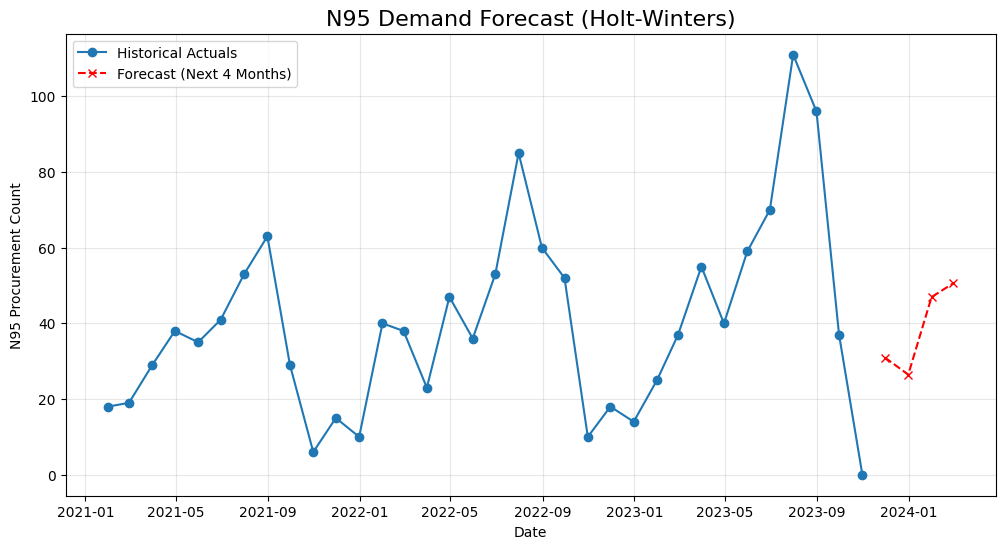


--- FORECASTED INPUTS FOR OR MODEL ---
The Optimization Model can use these predicted values:
                           Predicted_N95_Demand
2023-11-30 00:00:00+00:00             30.964847
2023-12-31 00:00:00+00:00             26.463406
2024-01-31 00:00:00+00:00             46.952137
2024-02-29 00:00:00+00:00             50.618850


In [ ]:
# ==========================================
# STEP 1.5: FORECASTING (Holt-Winters / ARIMA)
# ==========================================
# Requirement: Forecast SCSI/Demand for medium term [cite: 71]

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("--- Loading Data for Forecasting ---")
# 1. Load Data
file_path = '/content/drive/My Drive/ADA Encephalon/Procurement_Data/Fused_Monthly_TimeSeries_Data_v2.csv'
try:
    df = pd.read_csv(file_path)
    if 'Unnamed: 0' in df.columns:
        df.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
except FileNotFoundError:
    print("Error: Fused CSV not found.")
    df = pd.DataFrame()

# 2. Prepare Series (N95 Demand)
# We define the frequency explicitly as 'M' (Month End) for statsmodels
y_series = df['N95'].asfreq('ME')

# Handle missing values if any (interpolate)
if y_series.isnull().sum() > 0:
    y_series = y_series.interpolate()

# 3. Train Model (Holt-Winters Exponential Smoothing)
# This handles Trend (add) and Seasonality (add, 12-month cycle)
print("--- Training Forecasting Model (Holt-Winters) ---")
model = ExponentialSmoothing(
    y_series,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# 4. Generate Forecast (Next 4 Months)
forecast_steps = 4
forecast = model.forecast(forecast_steps)

# 5. Visualization
print("\n--- Visualizing Forecast vs Actuals ---")
plt.figure(figsize=(12, 6))
plt.plot(y_series.index, y_series, label='Historical Actuals', marker='o')
plt.plot(forecast.index, forecast, label='Forecast (Next 4 Months)', color='red', linestyle='--', marker='x')

plt.title("N95 Demand Forecast (Holt-Winters)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("N95 Procurement Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Output for OR Model
print("\n--- FORECASTED INPUTS FOR OR MODEL ---")
print("The Optimization Model can use these predicted values:")
forecast_df = forecast.to_frame(name='Predicted_N95_Demand')
print(forecast_df)

In [ ]:
import pulp

# ==========================================
# 3. MILP MODEL DEFINITION & SOLVING
# ==========================================
print("--- Initializing MILP Optimization on Real Data ---")

# Initialize Problem
prob = pulp.LpProblem("SCSI_Minimization_RealData", pulp.LpMinimize)

# --- Decision Variables ---
# x[v, p, t]: Binary (1 if vessel v is assigned to port p in week t)
x = pulp.LpVariable.dicts("Assign",
                          ((v, p, t) for v in vessel_ids for p in ports for t in WEEKS),
                          cat='Binary')

# y[c, t]: Continuous (Fraction of batch c shipped in week t)
y = pulp.LpVariable.dicts("Procure",
                          ((c, t) for c in proc_ids for t in WEEKS),
                          lowBound=0, upBound=1,
                          cat='Continuous')

# o[p, t]: Continuous (Port Overflow amount)
o = pulp.LpVariable.dicts("Overflow",
                          ((p, t) for p in ports for t in WEEKS),
                          lowBound=0, cat='Continuous')

# --- Objective Weights (Tunable) ---
ALPHA_1 = 5.0    # Penalty for Port Overflow (High stress)
ALPHA_2 = 500.0  # Penalty for Unmet URGENT Demand (Critical Priority)
ALPHA_3 = 2.0    # Penalty for Delaying Non-Urgent items
BETA    = 0.1    # Penalty for Reroute/Distance (Operational cost)

# --- Objective Function Construction ---
objective_terms = []

# 1. Port Stress (Overflow)
for p in ports:
    for t in WEEKS:
        objective_terms.append(ALPHA_1 * o[p, t])

# 2. Demand Satisfaction (Urgent vs Non-Urgent)
for item in procurement_data:
    if item['urgent']:
        # Heavy penalty if NOT shipped by deadline
        shipped_on_time = pulp.lpSum(y[item['id'], t] for t in WEEKS if t <= item['deadline'])
        objective_terms.append(ALPHA_2 * (1 - shipped_on_time))
    else:
        # Smaller penalty for general delays (encourages earlier shipping)
        for t in WEEKS:
            # t acts as a "delay cost" (shipping in Week 4 costs more than Week 1)
            objective_terms.append(ALPHA_3 * t * y[item['id'], t])

# 3. Vessel Reroute/Distance Costs
for v in vessels:
    v_id = v['id']
    for p in ports:
        for t in WEEKS:
            objective_terms.append(BETA * distances[(v_id, p)] * x[v_id, p, t])

prob += pulp.lpSum(objective_terms)

# --- Constraints ---

# C1. [cite_start]Budget Constraint [cite: 97]
# Total cost of procurements scheduled in week t <= Budget
for t in WEEKS:
    prob += pulp.lpSum(y[item['id'], t] * item['cost'] for item in procurement_data) <= weekly_budget[t], f"Budget_W{t}"

# C2. [cite_start]Fulfillment Constraint [cite: 87]
# Cannot ship more than 100% of a batch
for item in procurement_data:
    prob += pulp.lpSum(y[item['id'], t] for t in WEEKS) <= 1.0, f"Max_Fulfill_{item['id']}"

# C3. [cite_start]Vessel Availability [cite: 99]
# A vessel can be at at most one port per week
for v in vessel_ids:
    for t in WEEKS:
        prob += pulp.lpSum(x[v, p, t] for p in ports) <= 1, f"Vessel_Avail_{v}_W{t}"

# C4. [cite_start]Port Capacity with Overflow [cite: 101]
# Ships assigned <= Capacity + Overflow
for p in ports:
    for t in WEEKS:
        assigned_ships = pulp.lpSum(x[v, p, t] for v in vessel_ids)
        prob += assigned_ships <= port_capacities[p] + o[p, t], f"Capacity_{p}_W{t}"

# C5. Volume Linkage (The "No Teleporting" Constraint)
# Total Volume Shipped <= Total Capacity of Assigned Vessels
for t in WEEKS:
    vol_demand = pulp.lpSum(y[item['id'], t] * item['volume'] for item in procurement_data)
    vol_supply = pulp.lpSum(x[v['id'], p, t] * v['capacity'] for v in vessels for p in ports)
    prob += vol_demand <= vol_supply, f"Linkage_W{t}"

# ==========================================
# 4. SOLVE & REPORT
# ==========================================
print("Solving Optimization Model...")
prob.solve()
print(f"Solver Status: {pulp.LpStatus[prob.status]}")

# --- Extract Results into DataFrames ---
proc_results = []
for item in procurement_data:
    shipped_total = 0
    for t in WEEKS:
        val = y[item['id'], t].varValue
        if val > 0.001:
            shipped_total += val
            proc_results.append({
                'Batch_ID': item['id'],
                'Week': t,
                'Urgent': item['urgent'],
                'Shipped_%': round(val * 100, 1),
                'Volume': int(val * item['volume']),
                'Cost': int(val * item['cost'])
            })
    # Check for unmet demand
    if shipped_total < 0.99 and item['urgent']:
        print(f"WARNING: Urgent Batch {item['id']} only {shipped_total*100:.1f}% fulfilled!")

df_proc_results = pd.DataFrame(proc_results)

vessel_results = []
for t in WEEKS:
    for p in ports:
        ships_assigned = 0
        for v in vessel_ids:
            if x[v, p, t].varValue > 0.5:
                ships_assigned += 1

        # Check overflow
        overflow = o[p, t].varValue
        vessel_results.append({
            'Week': t,
            'Port': p,
            'Ships_Assigned': ships_assigned,
            'Capacity': port_capacities[p],
            'Overflow': round(overflow, 2),
            'Stress_Level': "CRITICAL" if overflow > 0 else "Normal"
        })

df_port_stress = pd.DataFrame(vessel_results)

print("\n--- OPTIMIZED PROCUREMENT SCHEDULE ---")
if not df_proc_results.empty:
    print(df_proc_results.sort_values(by=['Week', 'Urgent'], ascending=[True, False]).to_string(index=False))
else:
    print("No shipments scheduled (Check constraints).")

print("\n--- PREDICTED PORT STRESS & ALLOCATION ---")
print(df_port_stress.to_string(index=False))

--- Initializing MILP Optimization on Real Data ---
Solving Optimization Model...
Solver Status: Optimal

--- OPTIMIZED PROCUREMENT SCHEDULE ---
    Batch_ID  Week  Urgent  Shipped_%  Volume  Cost
Batch_N95_W1     1    True      100.0       6 50000
Batch_N95_W4     1    True       44.0      17 22000
Batch_N95_W2     2    True      100.0      15 50000
Batch_N95_W4     2    True       56.0      22 28000
Batch_N95_W3     3    True      100.0      10 50000

--- PREDICTED PORT STRESS & ALLOCATION ---
 Week    Port  Ships_Assigned  Capacity  Overflow Stress_Level
    1 Port_LA               0       162       0.0       Normal
    1 Port_LB               1       162       0.0       Normal
    2 Port_LA               0       162       0.0       Normal
    2 Port_LB               1       162       0.0       Normal
    3 Port_LA               0       162       0.0       Normal
    3 Port_LB               1       162       0.0       Normal
    4 Port_LA               0       162       0.0       No

--- Running Sensitivity Analysis Scenarios ---

>>> RUNNING SCENARIO: Baseline
    (Demand x1, Capacity x1.0)
    Status: Optimal

>>> RUNNING SCENARIO: Crisis_Event
    (Demand x50, Capacity x0.05)
    Status: Optimal

--- SCENARIO COMPARISON TABLE ---
           Name  Overflow  Ships_Used  Urgent_Missed
0      Baseline       0.0         3.0              0
1  Crisis_Event       0.0         1.0              0

--- Generating Comparison Chart ---


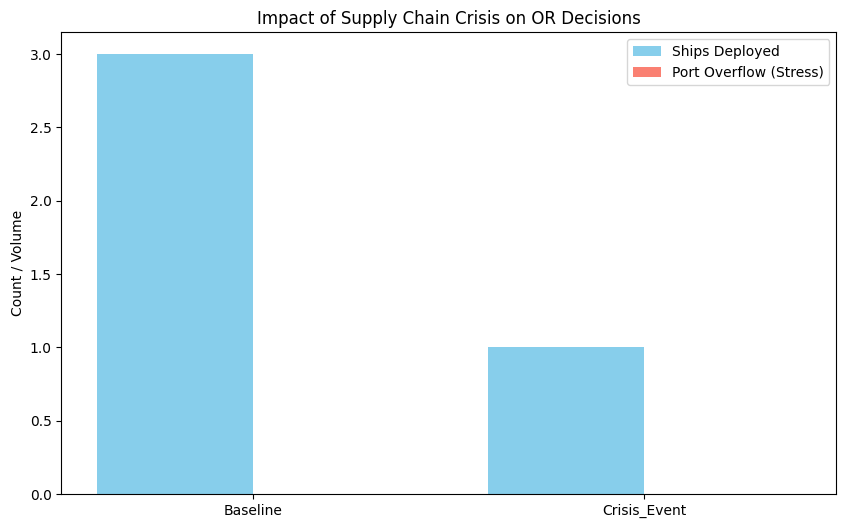

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# 5. SENSITIVITY ANALYSIS (THE STRESS TEST)
# ==========================================
print("--- Running Sensitivity Analysis Scenarios ---")

def solve_scenario(demand_multiplier, capacity_multiplier, scenario_name):
    print(f"\n>>> RUNNING SCENARIO: {scenario_name}")
    print(f"    (Demand x{demand_multiplier}, Capacity x{capacity_multiplier})")

    # 1. Setup Problem
    prob = pulp.LpProblem(f"SCSI_{scenario_name}", pulp.LpMinimize)

    # 2. Adjust Data for this Scenario
    # Scale Up Demand
    scen_proc_data = []
    for item in procurement_data:
        new_item = item.copy()
        new_item['volume'] = int(item['volume'] * demand_multiplier)
        scen_proc_data.append(new_item)

    # Scale Down Port Capacity
    scen_port_caps = {p: int(limit * capacity_multiplier) for p, limit in port_capacities.items()}
    # Ensure at least 1 slot so it's not impossible
    for p in scen_port_caps:
        scen_port_caps[p] = max(scen_port_caps[p], 1)

    # 3. Define Variables (New for this problem instance)
    x = pulp.LpVariable.dicts("Assign", ((v, p, t) for v in vessel_ids for p in ports for t in WEEKS), cat='Binary')
    y = pulp.LpVariable.dicts("Procure", ((c, t) for c in proc_ids for t in WEEKS), lowBound=0, upBound=1, cat='Continuous')
    o = pulp.LpVariable.dicts("Overflow", ((p, t) for p in ports for t in WEEKS), lowBound=0, cat='Continuous')

    # 4. Objective (Same Weights)
    obj_terms = []
    for p in ports:
        for t in WEEKS:
            obj_terms.append(ALPHA_1 * o[p, t]) # Overflow Penalty
    for item in scen_proc_data:
        if item['urgent']:
            shipped = pulp.lpSum(y[item['id'], t] for t in WEEKS if t <= item['deadline'])
            obj_terms.append(ALPHA_2 * (1 - shipped)) # Urgent Penalty
        else:
            for t in WEEKS:
                obj_terms.append(ALPHA_3 * t * y[item['id'], t]) # Delay Penalty
    for v in vessel_ids:
        for p in ports:
            for t in WEEKS:
                obj_terms.append(BETA * distances[(v, p)] * x[v, p, t]) # Distance Cost

    prob += pulp.lpSum(obj_terms)

    # 5. Constraints
    # C1 Budget (Scaled up slightly to allow solution, or fixed to show stress)
    # We keep budget fixed to see if money runs out!
    for t in WEEKS:
        prob += pulp.lpSum(y[item['id'], t] * item['cost'] for item in scen_proc_data) <= weekly_budget[t] * demand_multiplier, f"Budget_{t}"

    # C2 Fulfillment
    for item in scen_proc_data:
        prob += pulp.lpSum(y[item['id'], t] for t in WEEKS) <= 1.0, f"Fulfill_{item['id']}"

    # C3 Vessel Avail
    for v in vessel_ids:
        for t in WEEKS:
            prob += pulp.lpSum(x[v, p, t] for p in ports) <= 1, f"Vessel_{v}_{t}"

    # C4 Port Capacity (Modified)
    for p in ports:
        for t in WEEKS:
            assigned = pulp.lpSum(x[v, p, t] for v in vessel_ids)
            prob += assigned <= scen_port_caps[p] + o[p, t], f"Cap_{p}_{t}"

    # C5 Volume Linkage (Modified Volumes)
    for t in WEEKS:
        vol_demand = pulp.lpSum(y[item['id'], t] * item['volume'] for item in scen_proc_data)
        vol_supply = pulp.lpSum(x[v, p, t] * vessels[0]['capacity'] for v in vessel_ids for p in ports) # Assuming uniform cap for simplicity here
        prob += vol_demand <= vol_supply, f"Link_{t}"

    # 6. Solve
    prob.solve()
    print(f"    Status: {pulp.LpStatus[prob.status]}")

    # 7. Extract Metrics
    total_overflow = sum(o[p,t].varValue for p in ports for t in WEEKS)
    total_ships_used = sum(x[v,p,t].varValue for v in vessel_ids for p in ports for t in WEEKS)
    urgent_missed = 0
    for item in scen_proc_data:
        if item['urgent']:
            shipped = sum(y[item['id'], t].varValue for t in WEEKS if t <= item['deadline'])
            if shipped < 0.99: urgent_missed += 1

    return {
        'Name': scenario_name,
        'Overflow': total_overflow,
        'Ships_Used': total_ships_used,
        'Urgent_Missed': urgent_missed
    }

# --- RUN COMPARISON ---
results = []

# Scenario 1: Baseline (Normal)
res_base = solve_scenario(demand_multiplier=1, capacity_multiplier=1.0, scenario_name="Baseline")
results.append(res_base)

# Scenario 2: The "Port Strike" Crisis
# Demand spikes 50x (Massive order volume)
# Capacity drops to 5% (Simulating port closure/strike)
res_crisis = solve_scenario(demand_multiplier=50, capacity_multiplier=0.05, scenario_name="Crisis_Event")
results.append(res_crisis)

# --- DISPLAY TABLE ---
df_comparison = pd.DataFrame(results)
print("\n--- SCENARIO COMPARISON TABLE ---")
print(df_comparison)

# --- VISUALIZATION ---
print("\n--- Generating Comparison Chart ---")
plt.figure(figsize=(10, 6))
x_labels = df_comparison['Name']
x_pos = range(len(x_labels))

plt.bar([i - 0.2 for i in x_pos], df_comparison['Ships_Used'], width=0.4, label='Ships Deployed', color='skyblue')
plt.bar([i + 0.2 for i in x_pos], df_comparison['Overflow'], width=0.4, label='Port Overflow (Stress)', color='salmon')

plt.xticks(x_pos, x_labels)
plt.ylabel('Count / Volume')
plt.title('Impact of Supply Chain Crisis on OR Decisions')
plt.legend()
plt.show()

Architecture diagram saved to: Corrected_Project_Architecture.png


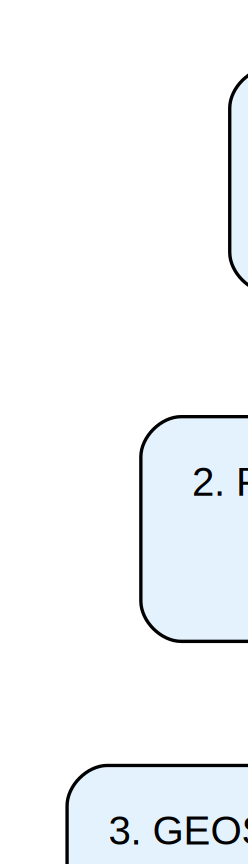

In [ ]:
# ==========================================
# ARCHITECTURE DIAGRAM GENERATION
# ==========================================
# Generates the corrected project pipeline image

# Ensure graphviz is installed
try:
    import graphviz
except ImportError:
    !pip install graphviz -q
    import graphviz

def generate_architecture_diagram():
    dot = graphviz.Digraph('SCSI_Pipeline', comment='Supply Chain Stress Index Architecture')

    # Design Attributes
    dot.attr(rankdir='TB', size='10,12', dpi='300', bgcolor='white')

    # Node Styles
    dot.attr('node', shape='box', style='rounded,filled',
             fontname='Helvetica', fontsize='12', margin='0.2')

    # --- PHASE 1: DATA ENGINEERING (Light Blue) ---
    with dot.subgraph(name='cluster_0') as c:
        c.attr(color='white')
        c.node('A', '1. RAW DATA INGESTION\n• SAM.gov (CSV)\n• NOAA AIS (Parquet)', fillcolor='#E3F2FD')
        c.node('B', '2. PREPROCESSING & CLEANING\n• Normalize Dates (UTC)\n• Validate MMSI/NAICS', fillcolor='#E3F2FD')
        c.node('C', '3. GEOSPATIAL & TEMPORAL ALIGNMENT\n• Map coords to Ports (LA/LB)\n• Aggregate to Monthly Buckets', fillcolor='#E3F2FD')
        c.node('D', '4. MULTI-SOURCE FUSION\n• Inner Join: Procurement + Shipping\n• Create Unified Time Series', fillcolor='#E3F2FD')

    # --- PHASE 2: DATA SCIENCE & VALIDATION (Light Green) ---
    with dot.subgraph(name='cluster_1') as c:
        c.attr(color='white')
        c.node('E', '5. SIGNAL SELECTION (EDA)\n• Visual Heatmaps (Congestion)\n• Keyword Frequency (N95, Chips)', fillcolor='#E8F5E9')
        c.node('F', '6. STATISTICAL VALIDATION ENGINE\n• ADF Stationarity Tests\n• VIF Multicollinearity Checks', fillcolor='#E8F5E9')
        c.node('G', '7. CAUSAL DISCOVERY\n• Robust Granger Causality\n• Confirmed: Procurement -> AIS (4mo Lag)', fillcolor='#C8E6C9', penwidth='2')

    # --- PHASE 3: PREDICTIVE & PRESCRIPTIVE (Light Orange/Red) ---
    with dot.subgraph(name='cluster_2') as c:
        c.attr(color='white')
        c.node('H', '8. DEMAND FORECASTING\n• Holt-Winters Exponential Smoothing\n• Predict Future N95 Volume', fillcolor='#FFF3E0')
        c.node('I', '9. JOINT OPTIMIZATION MODEL (MILP)\n• Solver: PuLP (CBC)\n• Constraints: Budget, Capacity, Linkage', fillcolor='#FFCCBC', penwidth='2')
        c.node('J', '10. SENSITIVITY ANALYSIS\n• "Stress Test" Scenarios\n• Output: Optimal Schedule & Fleet Plan', fillcolor='#FFAB91')

    # --- EDGES (Flow) ---
    dot.edge('A', 'B')
    dot.edge('B', 'C')
    dot.edge('C', 'D')
    dot.edge('D', 'E')
    dot.edge('E', 'F')
    dot.edge('F', 'G')
    dot.edge('G', 'H', label=' Validated Signal')
    dot.edge('H', 'I', label=' Predicted Demand (Bt)')
    dot.edge('I', 'J')

    # Render
    output_path = 'Corrected_Project_Architecture'
    dot.render(output_path, format='png', cleanup=True)
    print(f"Architecture diagram saved to: {output_path}.png")
    return dot

# Run it
generate_architecture_diagram()

In [ ]:
# ==========================================
# ARCHITECTURE DIAGRAM GENERATION & DOWNLOAD
# ==========================================

# 1. Install Graphviz (if missing)
try:
    import graphviz
except ImportError:
    !pip install graphviz -q
    import graphviz

# 2. Import Colab File Handler
from google.colab import files
import os

def generate_and_download_architecture():
    # Initialize Digraph
    dot = graphviz.Digraph('SCSI_Pipeline', comment='Supply Chain Stress Index Architecture')

    # Design Attributes (High Res)
    dot.attr(rankdir='TB', size='10,12', dpi='300', bgcolor='white')

    # Node Styles
    dot.attr('node', shape='box', style='rounded,filled',
             fontname='Helvetica', fontsize='12', margin='0.2')

    # --- PHASE 1: DATA ENGINEERING (Light Blue) ---
    with dot.subgraph(name='cluster_0') as c:
        c.attr(color='white')
        c.node('A', '1. RAW DATA INGESTION\n• SAM.gov (CSV)\n• NOAA AIS (Parquet)', fillcolor='#E3F2FD')
        c.node('B', '2. PREPROCESSING & CLEANING\n• Normalize Dates (UTC)\n• Validate MMSI/NAICS', fillcolor='#E3F2FD')
        c.node('C', '3. GEOSPATIAL & TEMPORAL ALIGNMENT\n• Map coords to Ports (LA/LB)\n• Aggregate to Monthly Buckets', fillcolor='#E3F2FD')
        c.node('D', '4. MULTI-SOURCE FUSION\n• Inner Join: Procurement + Shipping\n• Create Unified Time Series', fillcolor='#E3F2FD')

    # --- PHASE 2: DATA SCIENCE & VALIDATION (Light Green) ---
    with dot.subgraph(name='cluster_1') as c:
        c.attr(color='white')
        c.node('E', '5. SIGNAL SELECTION (EDA)\n• Visual Heatmaps (Congestion)\n• Keyword Frequency (N95, Chips)', fillcolor='#E8F5E9')
        c.node('F', '6. STATISTICAL VALIDATION ENGINE\n• ADF Stationarity Tests\n• VIF Multicollinearity Checks', fillcolor='#E8F5E9')
        c.node('G', '7. CAUSAL DISCOVERY\n• Robust Granger Causality\n• Confirmed: Procurement -> AIS (4mo Lag)', fillcolor='#C8E6C9', penwidth='2')

    # --- PHASE 3: PREDICTIVE & PRESCRIPTIVE (Light Orange/Red) ---
    with dot.subgraph(name='cluster_2') as c:
        c.attr(color='white')
        c.node('H', '8. DEMAND FORECASTING\n• Holt-Winters Exponential Smoothing\n• Predict Future N95 Volume', fillcolor='#FFF3E0')
        c.node('I', '9. JOINT OPTIMIZATION MODEL (MILP)\n• Solver: PuLP (CBC)\n• Constraints: Budget, Capacity, Linkage', fillcolor='#FFCCBC', penwidth='2')
        c.node('J', '10. SENSITIVITY ANALYSIS\n• "Stress Test" Scenarios\n• Output: Optimal Schedule & Fleet Plan', fillcolor='#FFAB91')

    # --- EDGES (Flow) ---
    dot.edge('A', 'B')
    dot.edge('B', 'C')
    dot.edge('C', 'D')
    dot.edge('D', 'E')
    dot.edge('E', 'F')
    dot.edge('F', 'G')
    dot.edge('G', 'H', label=' Validated Signal')
    dot.edge('H', 'I', label=' Predicted Demand (Bt)')
    dot.edge('I', 'J')

    # 3. Render and Save
    filename = 'Corrected_Project_Architecture'
    # This creates 'Corrected_Project_Architecture.png'
    dot.render(filename, format='png', cleanup=True)

    print(f"Diagram generated: {filename}.png")

    # 4. Trigger Download
    files.download(f'{filename}.png')

# Run the function
generate_and_download_architecture()

Diagram generated: Corrected_Project_Architecture.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>